# Tufa Labs ARC3 submission

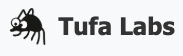

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# patch-closure: install the ARC runtime from the bundled competition wheels.
# The competition data mounts at EITHER /kaggle/input/competitions/<slug> OR
# /kaggle/input/<slug> depending on the machine (proven from pip's stderr on
# the 2026-08-08 candidate ERRORs). Probe both; fail loudly naming both.
_pc_wheel_dirs = [
    "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
    "/kaggle/input/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
]
_pc_wheels = next((p for p in _pc_wheel_dirs if Path(p).is_dir()), None)
if _pc_wheels is None:
    raise RuntimeError(
        f"arc_agi_3_wheels directory not found at either mount form: {_pc_wheel_dirs}")
print(f"[pc] installing arc-agi from {_pc_wheels}", flush=True)
_pc_pip = subprocess.run(
    [
        sys.executable, "-m", "pip", "install",
        "--quiet", "--no-index", "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links", _pc_wheels,
        "arc-agi",
    ],
    capture_output=True, text=True,
)
if _pc_pip.stdout.strip():
    print(_pc_pip.stdout, flush=True)
if _pc_pip.stderr.strip():
    print(f"[pc] pip stderr:\n{_pc_pip.stderr}", flush=True)
if _pc_pip.returncode != 0:
    raise RuntimeError(f"[pc] pip install of arc-agi FAILED (rc={_pc_pip.returncode})")
print(f"[pc] arc-agi installed from {_pc_wheels}", flush=True)


## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
if True:  # patch-closure: force the serve — a commit run must serve Qwen
    for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# ============================================================================
# Patch-closure machinery, arm: PACKAGE. Inlined from
# submission/_duck_patched/duck_patches.py and submission/_rig/behav_probe.py
# by build_patch_closure.py — edit those and rebuild.
# ============================================================================
"""In-memory patches applied to the read-only TAAF duck bundle before `bm.run()`.

The Kaggle dataset that carries the duck harness is read-only, so every fix here is a
monkey-patch installed at import time in the notebook. Each patch is independently
guarded: if the upstream shape it expects is missing, that patch reports FAIL and the
others still apply. Nothing here changes the model, sampling, concurrency or budgets.

PATCH 1 — ACTION7 round trip (BUG FIX).
    `inference.agent.action_names.ENGINE_TO_MODEL_ACTION` maps ACTION1..6 + RESET only.
    `to_model_action("ACTION7")` passes the name through to the model, but
    `to_engine_action("ACTION7")` returns None, so solver.py's action parser rejects it
    with "Unknown action at index N". The model is offered a legal action it can never
    execute. 6 of the 25 public games use ACTION7 (ar25, bp35, lf52, sb26, sk48, su15).

PATCH 2 — animation metadata.
    `taaf.game.GameState.animation_frames` already exposes the intermediate frames of a
    multi-frame action, but only the final frame ever reaches the model. This adds a few
    scalar fields per action describing what moved during the animation. No images, no
    raw frames — roughly 20-40 tokens per action of causal signal.

NOT PATCHED — RESET restriction.
    The public fork this work draws on restricts RESET to GAME_OVER. Our bundle already
    does the equivalent, more thoroughly: `solver._engine_action_names` strips RESET from
    the model's choices unconditionally (solver.py:116-117) and `_execute_auto_reset()`
    fires on GAME_OVER (solver.py:278-282). No change needed; verified by
    `verify_reset_already_handled()` below.
"""
from __future__ import annotations

from typing import Any

# Engine action ids that count as real actions (RESET is id 0 and is scored differently).
_ACTION7 = "ACTION7"


def _forward_patch_markers(wrapper: Any, original: Any) -> None:
    """Copy every ``*_patched`` marker from a wrapped callable onto its wrapper.

    The patches stack (7 -> 8 -> 10 -> 11 all wrap the same methods); each one's
    idempotency check and the A/B kernel's patch proof read the markers off the
    OUTERMOST callable, so a wrapper that hides its predecessors' markers makes
    a second ``apply_all()`` re-wrap them (double bookkeeping).
    """
    for attr, value in vars(original).items():
        if attr.endswith("_patched") and value:
            setattr(wrapper, attr, value)


def patch_action7() -> str:
    """Make ACTION7 survive the model<->engine name round trip. Returns a status line."""
    from inference.agent import action_names as an

    if _ACTION7 in an.ENGINE_TO_MODEL_ACTION:
        return "patch1 action7: SKIP (already mapped)"

    # ACTION7's meaning is not fixed across games, so it has no friendly label like
    # UP/DOWN/MOUSE. Map it to itself: the model sees "ACTION7" and the engine gets
    # "ACTION7" back.
    an.ENGINE_TO_MODEL_ACTION[_ACTION7] = _ACTION7
    an.MODEL_TO_ENGINE_ACTION.clear()
    an.MODEL_TO_ENGINE_ACTION.update(
        {value: key for key, value in an.ENGINE_TO_MODEL_ACTION.items()}
    )

    if an.to_engine_action(an.to_model_action(_ACTION7)) != _ACTION7:
        raise RuntimeError("patch1 action7: round trip still broken after patch")
    return "patch1 action7: OK"


def patch_animation_producer() -> str:
    """Attach the animation summary to the payload `_execute_action` returns.

    `_compact_action_result` (patch 2b) only forwards these keys; this is what creates
    them. Wrapping the method rather than reimplementing it keeps us insulated from
    upstream changes to the payload's other fields.
    """
    from inference.framework import solver

    session = getattr(solver, "_HarnessGameSession", None)
    if session is None or not hasattr(session, "_execute_action"):
        return "patch2a animation-producer: FAIL (_HarnessGameSession._execute_action not found)"
    if getattr(session._execute_action, "_animation_patched", False):
        return "patch2a animation-producer: SKIP (already applied)"

    original = session._execute_action

    def _execute_action(self: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        payload = original(self, *args, **kwargs)
        if isinstance(payload, dict):
            try:
                payload.update(summarize_animation(self.game.current_state))
            except Exception:
                pass  # never let telemetry break an action
        return payload

    _execute_action._animation_patched = True  # type: ignore[attr-defined]
    session._execute_action = _execute_action
    return "patch2a animation-producer: OK"


def patch_animation_metadata() -> str:
    """Forward the animation summary through the compaction the model actually sees."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_compact_action_result"):
        return "patch2b animation-forward: FAIL (ToolAgent._compact_action_result not found)"
    if getattr(agent_cls._compact_action_result, "_animation_patched", False):
        return "patch2b animation-forward: SKIP (already applied)"

    original = agent_cls._compact_action_result

    def _compact_action_result(self: Any, payload: dict[str, Any]) -> dict[str, Any]:
        compact = original(self, payload)
        for key in _ANIMATION_KEYS:
            if key in payload:
                compact[key] = payload[key]
        return compact

    _compact_action_result._animation_patched = True  # type: ignore[attr-defined]
    agent_cls._compact_action_result = _compact_action_result
    return "patch2b animation-forward: OK"


_ANIMATION_KEYS = (
    "animation_frame_count",
    "animation_changed",
    "animation_only_changed",
    "animation_changed_cell_count",
    "animation_changed_bbox",
)


def summarize_animation(state: Any) -> dict[str, Any]:
    """Describe the animation of a just-executed action as a handful of scalars.

    `state` is a taaf GameState. Returns {} when the action produced no animation, so
    single-frame actions cost zero extra tokens.
    """
    try:
        animation = list(state.animation_frames)
    except Exception:
        return {}
    if not animation:
        return {}

    final = _frame_rows(state.frame)
    changed_cells: list[tuple[int, int]] = []
    only_in_animation = False
    # HUD cells (patch 8) tick during animations too; they are not motion signal.
    hud_cells = {(int(y), int(x)) for y, x in _hud_current_mask_cells()}

    for frame in animation:
        rows = _frame_rows(frame)
        for y, (arow, frow) in enumerate(zip(rows, final)):
            for x, (avalue, fvalue) in enumerate(zip(arow, frow)):
                if avalue != fvalue and (y, x) not in hud_cells:
                    changed_cells.append((x, y))
                    only_in_animation = True

    out: dict[str, Any] = {
        "animation_frame_count": len(animation),
        "animation_changed": bool(changed_cells),
        # True when the animation showed motion that is NOT visible in the final frame —
        # i.e. something moved and returned, or moved through. This is the signal the
        # model cannot otherwise recover.
        "animation_only_changed": only_in_animation,
        "animation_changed_cell_count": len(set(changed_cells)),
    }
    if changed_cells:
        xs = [x for x, _ in changed_cells]
        ys = [y for _, y in changed_cells]
        out["animation_changed_bbox"] = [min(xs), min(ys), max(xs), max(ys)]
    return out


def _frame_rows(frame: Any) -> list[list[int]]:
    data = getattr(frame, "data", frame)
    return [list(row) for row in data]


def verify_reset_already_handled() -> str:
    """Confirm our bundle already restricts RESET, so patch 3 is genuinely unnecessary."""
    import inspect

    from inference.framework import solver

    src = inspect.getsource(solver._engine_action_names)
    strips_reset = 'if name == "RESET"' in src and "continue" in src
    auto_resets = hasattr(solver._HarnessGameSession, "_execute_auto_reset")
    if strips_reset and auto_resets:
        return "patch3 reset: NOT NEEDED (RESET stripped from choices + auto-reset on GAME_OVER)"
    return (
        f"patch3 reset: REVIEW (strips_reset={strips_reset}, auto_resets={auto_resets}) "
        "— upstream changed, re-check whether RESET must be restricted"
    )


def _grid_burner_enabled() -> bool:
    """Opt-in only (TAAF_GRID_BURNER=1). Default OFF.

    The 2026-08-03 zero-submission diagnosis found the burner draws ~11px default-font
    labels and per-cell grid lines onto the images at the SCORED config's
    MULTIMODAL_UPSCALE=4 (4px cells) — substantial frame defacement. It was only ever
    validated at dev upscale 16 and has never been part of a scored config, so it must
    be explicitly opted into, never on by default.
    """
    import os

    return os.environ.get("TAAF_GRID_BURNER", "0").strip() in {"1", "true", "True"}


def patch_dynamic_grid_burner() -> str:
    """Burn coordinate grids into the images sent to the VLM (Spatial Overlay).

    Call-time gated on TAAF_GRID_BURNER (default OFF): the wrapper is always
    installed but delegates to the stock renderer unless explicitly enabled,
    matching the other patches' env-switch style.
    """
    from inference.agent import vision_context

    if getattr(vision_context.frame_to_png_data_url, "_grid_burner_patched", False):
        return "patch4 grid-burner: SKIP (already applied)"

    original_func = vision_context.frame_to_png_data_url

    def frame_to_png_data_url_patched(frame: Any, *, upscale: int | None = None) -> str:
        if not _grid_burner_enabled():
            return original_func(frame, upscale=upscale)
        import io, base64
        from PIL import Image, ImageDraw

        rows = len(frame.grid)
        cols = max((len(row) for row in frame.grid), default=0)
        if rows <= 0 or cols <= 0:
            raise ValueError("Cannot render an empty grid as an image.")

        scale = vision_context.current_grid_image_upscale() if upscale is None else max(1, int(upscale))
        image = Image.new("RGB", (cols, rows), vision_context.ARC_COLOR_MAP[0])
        pixels = image.load()
        for row_idx, row in enumerate(frame.grid):
            for col_idx in range(cols):
                value = row[col_idx] if col_idx < len(row) else 0
                pixels[col_idx, row_idx] = vision_context.ARC_COLOR_MAP.get(int(value), vision_context.ARC_COLOR_MAP[0])
        
        if scale > 1:
            image = image.resize((cols * scale, rows * scale), Image.Resampling.NEAREST)
            draw = ImageDraw.Draw(image)
            
            # Draw subtle grid lines
            grid_color = (128, 128, 128)
            for r in range(rows + 1):
                y = r * scale
                width = 2 if r % 5 == 0 else 1
                draw.line([(0, y), (cols * scale, y)], fill=grid_color, width=width)
            for c in range(cols + 1):
                x = c * scale
                width = 2 if c % 5 == 0 else 1
                draw.line([(x, 0), (x, rows * scale)], fill=grid_color, width=width)

            # Draw coordinate labels
            try:
                from PIL import ImageFont
                font = ImageFont.load_default()
                text_color = (200, 200, 200)
                # row labels (left edge)
                for r in range(rows):
                    if r % 5 == 0:
                        draw.text((2, r * scale + 2), str(r), fill=text_color, font=font)
                # col labels (top edge)
                for c in range(cols):
                    if c % 5 == 0 and c > 0:
                        draw.text((c * scale + 2, 2), str(c), fill=text_color, font=font)
            except Exception:
                pass

        buffer = io.BytesIO()
        image.save(buffer, format="PNG")
        encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
        return f"data:image/png;base64,{encoded}"

    _forward_patch_markers(frame_to_png_data_url_patched, original_func)
    frame_to_png_data_url_patched._grid_burner_patched = True  # type: ignore[attr-defined]
    vision_context.frame_to_png_data_url = frame_to_png_data_url_patched
    if _grid_burner_enabled():
        return "patch4 grid-burner: OK (TAAF_GRID_BURNER=1)"
    return "patch4 grid-burner: OK (dormant — opt in with TAAF_GRID_BURNER=1)"


def patch_prompts() -> str:
    """Update system prompt to instruct the model to use the grid coordinates."""
    from inference.agent import prompts
    if "numeric coordinate labels" in prompts.MULTIMODAL_CONTEXT_ADDENDUM:
        return "patch5 prompts: SKIP (already applied)"
    prompts.MULTIMODAL_CONTEXT_ADDENDUM += "- The image contains numeric coordinate labels (0, 5, 10...) along the top and left edges. Use these to precisely identify row and column indices for spatial reasoning and action targeting.\n"
    return "patch5 prompts: OK"


def patch_tool_agent_analyze() -> str:
    """Intercept the Qwen-27B action generation pipeline to inject TransferExplorer and Retrospective summaries."""
    import importlib.util
    import sys
    from pathlib import Path

    # Ensure arcagi3 is in sys.path. NO bare __file__ here: this module is exec'd
    # straight into a notebook cell on Kaggle, where __file__ is undefined — the old
    # `Path(__file__)` fallback raised NameError while building the path list and
    # aborted the whole patch as FAIL before it had mutated anything.
    possible_paths = [
        Path("/kaggle/input/arcagi3-agent/lib"),
        Path("/kaggle/input/datasets/ahmedmobasher86/arcagi3-agent/lib"),
    ]
    module_file = globals().get("__file__")
    if module_file:  # imported as a real file (tests / dev): repo-root src fallback
        possible_paths.append(Path(module_file).resolve().parents[2] / "src")
    for p in possible_paths:
        if p.exists() and str(p) not in sys.path:
            sys.path.insert(0, str(p))

    # Presence-gate the resource instead of failing later per call: without the
    # arcagi3 package the TransferExplorer probe can never fire, so decline cleanly.
    try:
        arcagi3_present = importlib.util.find_spec("arcagi3.transfer_explorer") is not None
    except (ImportError, ModuleNotFoundError, ValueError):
        arcagi3_present = False
    if not arcagi3_present:
        return (
            "patch6 tool_agent_analyze: SKIP (arcagi3.transfer_explorer not importable — "
            f"searched {[str(p) for p in possible_paths]})"
        )

    from inference.agent import tool_agent
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "analyze"):
        return "patch6 tool_agent_analyze: FAIL (ToolAgent.analyze not found)"
    if getattr(agent_cls.analyze, "_tool_agent_patched", False):
        return "patch6 tool_agent_analyze: SKIP (already applied)"

    original_analyze = agent_cls.analyze

    def analyze_patched(
        self,
        state_path: Path,
        action_num: int,
        valid_actions: list[str] | None = None,
        step_env = None,
        *args,
        **kwargs
    ):
        from inference.agent.runtime_state import load_runtime_state
        from inference.agent.tool_agent import AnalyzerTurnResult
        import arcengine
        
        # Phase 3: Inject Retrospective Summaries into system prompt
        original_system_prompt = getattr(self, "_original_system_prompt", None)
        if original_system_prompt is None:
            self._original_system_prompt = self._system_prompt
            original_system_prompt = self._system_prompt
            
        retrospectives = getattr(self, "_retrospective_summaries", [])
        if retrospectives:
            retro_text = "\n\nRetrospective Summaries from previous levels of this game:\n" + "\n".join(f"- {r}" for r in retrospectives)
            self._system_prompt = original_system_prompt + retro_text
        else:
            self._system_prompt = original_system_prompt

        # Phase 2: Heuristic Prober (TransferExplorer)
        if action_num < 200 and step_env is not None:
            try:
                from arcagi3.transfer_explorer import TransferExplorer
                if not hasattr(self, "_transfer_explorer_instance"):
                    self._transfer_explorer_instance = TransferExplorer()
                
                current_frame, _ = load_runtime_state(state_path)
                grid = current_frame.grid
                
                gstate_terminal = False
                gstate_notplayed = (action_num == 0)
                levels = current_frame.level
                
                # Format available actions as integers for TransferExplorer
                available_ids = []
                for name in (valid_actions or []):
                    try:
                        available_ids.append(arcengine.GameAction.from_name(name).value)
                    except Exception:
                        pass
                
                # numpy is required by arcagi3
                import numpy as np
                grid_np = np.array(grid, dtype=np.int32)
                
                action = self._transfer_explorer_instance.decide(
                    grid_np, gstate_terminal, gstate_notplayed, levels, available_ids
                )
                
                step_args = None
                if action and action[0] == "S":
                    action_name = arcengine.GameAction.from_id(action[1]).name
                    step_args = {"action": action_name}
                elif action and action[0] == "C":
                    step_args = {"action": "ACTION6", "col": action[1], "row": action[2]}
                elif action and action[0] == "reset":
                    step_args = {"action": "RESET"}
                    
                if step_args is not None:
                    # execute the symbolic transition
                    result = step_env(step_args)
                    # Note: we should still check if this action completed the level!
                    if self._last_action_result and self._last_action_result.get("level_completed"):
                        # Mark that we should do retrospective, but wait, the prober doesn't use the LLM, 
                        # so there are no LLM history messages for this level! We can just skip retro for heuristic clears.
                        pass
                    return AnalyzerTurnResult(
                        step_executed=True,
                        reasoning=f"TransferExplorer heuristic probe executed: {step_args}",
                        yielded_control=False,
                    )
            except Exception as exc:
                import logging
                logging.getLogger(__name__).warning("TransferExplorer failed, falling back to LLM: %s", exc)
                pass
                
        # Fallback to normal Qwen LLM analysis
        result = original_analyze(self, state_path, action_num, valid_actions, step_env, *args, **kwargs)
        
        # Phase 3: Retrospective generation on level complete
        if hasattr(self, "_last_action_result") and self._last_action_result and self._last_action_result.get("level_completed"):
            try:
                retro_messages = list(self._history_messages)
                retro_messages.append({
                    "role": "user", 
                    "content": "The level was just solved! Briefly summarize the core mechanic of this level and the strategy used to solve it. This summary will be provided to you in future levels of this game, so focus on transferable rules (e.g. 'green objects always move right until they hit a wall'). Keep it under 4 sentences."
                })
                # Call chat completion
                retro_result = self._chat_completion(retro_messages, tools=None)
                retro_content = retro_result.message.get("content", "")
                if retro_content:
                    if not hasattr(self, "_retrospective_summaries"):
                        self._retrospective_summaries = []
                    self._retrospective_summaries.append(retro_content)
            except Exception as exc:
                import logging
                logging.getLogger(__name__).warning("Retrospective generation failed: %s", exc)
                pass
                
        return result

    analyze_patched._tool_agent_patched = True  # type: ignore[attr-defined]
    agent_cls.analyze = analyze_patched
    return "patch6 tool_agent_analyze: OK"


# --- PATCH 8: HUD wavefront mask -------------------------------------------------
#
# 18-24 of the 25 public games paint a step-budget bar into the frame and tick it
# on (nearly) every action, so raw full-frame equality — which is exactly what the
# harness uses for `board_changed` (solver.py:703) and what the model's sandbox
# helpers `state_hash` / `diff_frames` hash — reports a board change for provable
# no-ops. Measured corpus no-op rate: 0.208 raw vs 0.455 masked; `board_changed`
# is wrong on 13/25 games (100% wrong on 6).
#
# The detector is the validated wavefront statistic (docs/test-artifacts-2026-08-02/
# RESULTS-determinism-hudmask.md, 24/25 games, 0 false-mask cells): a HUD bar is a
# collinear run of >=4 cells that each change EXACTLY ONCE, in monotone spatial
# order of change time (>=3 distinct times), all with the same color transition.
# The statistic only holds within RESET-free stretches (a RESET refills the bar),
# so the tracker accumulates per-segment change statistics and breaks the segment
# on RESET, on level transitions, and on GAME_OVER/WIN screens (all of which
# repaint or refill). Strips found in any segment are unioned into the game mask.
#
# VIRTUAL SEGMENT ROTATION (m0r0 lesson, 2026-08-03): cross-segment confirmation
# used to accrue segments ONLY at those natural boundaries, so a long boundary-free
# run could never reach MIN_SEGMENTS — m0r0's rows 0+63 budget bars (ticking every
# ~2-3 actions) were sighted but never confirmed across a 240-event episode with a
# single death. The tracker now also rotates to a fresh virtual segment after
# SEGMENT_ROTATE_STEPS accumulated steps (default 24, TAAF_HUD_ROTATE overrides,
# 0 disables), long enough that a slow-tick bar still yields >= MIN_LEN once-changed
# cells per window, so reset-free runs confirm within ~3 windows.
#
# UNMASK GUARD (protects the full-edge-strip games sp80/vc33/r11l/s5i5/tu93): if
# any masked cell changes twice within one segment, real content has entered the
# strip — the whole region is dropped from the mask permanently for that game.
#
# Consumers patched:
#   - `board_changed` in `_HarnessGameSession._execute_action` (and thereby every
#     downstream copy: step_env batch aggregation, `_compact_action_result`,
#     outcome summaries, viewer events);
#   - `summarize_animation` (patch 2) ignores masked cells;
#   - the python-tool sandbox's `state_hash` and `diff_frames` (patch 9), which
#     receive the live mask through the runtime-state payload.
#
# TAAF_HUD_MASK=0 disables masking at call time (the tracker still observes).


class HudMaskTracker:
    """Incremental wavefront/HUD-strip detector over reset-free segments.

    Per-segment statistics (change count, first-change time, first transition)
    are updated per frame in O(cells); strips are re-detected from the statistics
    (never from stored frames), so memory stays O(1) in episode length.

    Two precision rules beyond the validated wavefront statistic — needed because
    real play traces (unlike the scripted no-op probes) contain monotone content
    fills that satisfy the statistic per-line (measured on stored vc33 episodes:
    a painted block reads as a stack of parallel "strips"):

      * CROSS-SEGMENT CONFIRMATION — a line is masked only after it produced a
        wavefront strip (same orientation, line and color transition, overlapping
        span) in >= MIN_SEGMENTS distinct reset-free segments. A budget bar ticks
        in every segment; a content fill rarely repeats on the same line with the
        same transition. MIN_SEGMENTS=3 measured 0 masked cells outside the
        validated HUD regions across all 43 stored episodes (vs 77 at 2), while
        keeping 119 HUD-only no-op detections.
      * STACK RULE — >= MAX_STACK adjacent parallel confirmed lines with
        overlapping spans are a 2D block, not a bar, and are all rejected
        (2 adjacent lines stay allowed: the ls20 bar is two rows tall).

    Segment supply (the m0r0 lesson): natural boundaries (RESET / level change /
    GAME_OVER / WIN) are too rare in some real runs to ever reach MIN_SEGMENTS —
    a slow-tick bar in a boundary-free run was sighted forever but never
    confirmed. SEGMENT_ROTATE_STEPS therefore banks the live window and starts a
    fresh virtual segment every N accumulated steps; a budget bar re-satisfies
    the wavefront statistic in every window, while one-shot content fills do not.
    24 steps holds >= MIN_LEN once-changed cells for bars ticking as slowly as
    every ~5-6 actions (a 64-cell bar over a <= ~380-action budget).
    """

    MIN_LEN = 4
    MIN_DISTINCT_TIMES = 3
    MIN_SEGMENT_STEPS = 10
    MIN_SEGMENTS = 3
    MAX_STACK = 2
    SEGMENT_ROTATE_STEPS = 24  # 0 disables virtual rotation (pre-fix behavior)
    # A confirmed bar can REFILL mid-level with no reset/level/state boundary
    # (ls20: rows 61-62 repaint cols 13-54 in one frame at ~step 86). The repaint
    # makes many already-ticked cells hit nchg>=2 at once, which used to trip the
    # unmask guard and kill the line permanently. A refill's signature is exactly
    # that simultaneity: >= REFILL_MIN_CELLS of one confirmed line changing in a
    # SINGLE frame, while genuine bar ticks touch 1-2 cells and content entering
    # a strip changes sparsely across frames. Such a frame is treated as a
    # per-line segment restart (stats cleared, confirmations kept, mask kept).
    REFILL_MIN_CELLS = 4

    def __init__(self, min_segments: int | None = None) -> None:
        import numpy as np
        import os

        self._np = np
        self._prev = None
        self._levels: int | None = None
        self._steps = 0
        self._segment_id = 0
        # (orient, line, from_color, to_color) -> {segment_id: (span_start, span_end)}
        self._sightings: dict[tuple, dict[int, tuple[int, int]]] = {}
        self._dead_lines: set[tuple] = set()  # unmask-guard casualties, permanent
        self._tainted_lines: set[tuple] = set()  # (orient, line) seen in a 2D stack
        self._mask = None  # bool array, True = HUD cell
        self._dropped = None  # bool array, True = never mask again (guard fired)
        self._nchg = None
        self._tchg = None
        self._tfrom = None
        self._tto = None
        if min_segments is not None:
            self.MIN_SEGMENTS = int(min_segments)
        try:
            rotate = int(os.environ.get("TAAF_HUD_ROTATE", "").strip() or self.SEGMENT_ROTATE_STEPS)
        except ValueError:
            rotate = self.SEGMENT_ROTATE_STEPS
        # A rotation window shorter than the detection minimum could never bank
        # a strip; clamp instead of silently detecting nothing.
        self.SEGMENT_ROTATE_STEPS = 0 if rotate <= 0 else max(rotate, self.MIN_SEGMENT_STEPS)

    # -- lifecycle -----------------------------------------------------------

    def seed(self, grid: Any) -> None:
        """Record the pre-action board so the first transition is counted."""
        if self._prev is None:
            g = self._np.asarray(grid, dtype=self._np.int16)
            self._init_arrays(g.shape)
            self._prev = g

    def _init_arrays(self, shape: tuple[int, int]) -> None:
        np = self._np
        self._mask = np.zeros(shape, dtype=bool)
        self._dropped = np.zeros(shape, dtype=bool)
        self._reset_segment_stats(shape)

    def _reset_segment_stats(self, shape: tuple[int, int] | None = None) -> None:
        np = self._np
        if shape is None:
            shape = self._nchg.shape
        self._nchg = np.zeros(shape, dtype=np.int32)
        self._tchg = np.full(shape, -1, dtype=np.int32)
        self._tfrom = np.full(shape, -1, dtype=np.int16)
        self._tto = np.full(shape, -1, dtype=np.int16)
        self._steps = 0

    # -- main entry ----------------------------------------------------------

    def observe(
        self,
        grid: Any,
        *,
        is_reset: bool = False,
        levels_completed: int | None = None,
        state_name: str | None = None,
    ) -> dict[str, bool]:
        """Feed the post-action board; returns raw/masked change verdicts."""
        np = self._np
        g = np.asarray(grid, dtype=np.int16)
        if self._prev is None or g.shape != self._prev.shape:
            self._init_arrays(g.shape)
            self._prev = g
            if levels_completed is not None:
                self._levels = int(levels_completed)
            return {"raw_changed": False, "masked_changed": False}

        diff = self._prev != g
        raw_changed = bool(diff.any())
        masked_changed = bool((diff & ~self._mask).any())

        boundary = bool(is_reset)
        if levels_completed is not None:
            if self._levels is not None and int(levels_completed) != self._levels:
                boundary = True
            self._levels = int(levels_completed)
        if state_name in ("GAME_OVER", "WIN"):
            boundary = True

        if boundary:
            # The bar refills / the scene repaints: this transition must not
            # enter the statistic. Bank what the closing segment proved first.
            self._record_sightings()
            self._segment_id += 1
            self._reset_segment_stats()
            self._refresh_mask()
        else:
            if raw_changed:
                newly = diff & (self._nchg == 0)
                self._tchg[newly] = self._steps
                self._tfrom[newly] = self._prev[newly]
                self._tto[newly] = g[newly]
                self._nchg[diff] += 1
                self._clear_refilled_lines(diff, g)
                repeat = (self._nchg >= 2) & self._mask
                if repeat.any():
                    self._drop_regions(repeat)
            self._steps += 1
            if self._steps >= self.MIN_SEGMENT_STEPS:
                self._record_sightings()
                self._refresh_mask()
            if self.SEGMENT_ROTATE_STEPS and self._steps >= self.SEGMENT_ROTATE_STEPS:
                # Virtual segment boundary: the window above was just banked into
                # `_sightings` under the current id; open a fresh window so long
                # boundary-free runs still accrue MIN_SEGMENTS independent
                # confirmations (m0r0-class slow-tick bars).
                self._segment_id += 1
                self._reset_segment_stats()

        self._prev = g
        return {"raw_changed": raw_changed, "masked_changed": masked_changed}

    # -- detection -----------------------------------------------------------

    def _detect_segment_strips(self) -> dict[tuple, tuple]:
        if self._steps < self.MIN_SEGMENT_STEPS:
            return {}
        np = self._np
        once = self._nchg == 1
        height, width = once.shape
        strips: dict[tuple, tuple] = {}

        def consider(run: list[tuple[int, int]], orient: str) -> None:
            if len(run) < self.MIN_LEN:
                return
            times = [int(self._tchg[y, x]) for y, x in run]
            deltas = np.diff(times)
            if not (bool((deltas >= 0).all()) or bool((deltas <= 0).all())):
                return
            if len(set(times)) < self.MIN_DISTINCT_TIMES:
                return
            transitions = {(int(self._tfrom[y, x]), int(self._tto[y, x])) for y, x in run}
            if len(transitions) != 1:
                return
            (from_color, to_color) = next(iter(transitions))
            if orient == "H":
                key = ("H", run[0][0], from_color, to_color, run[0][1], run[-1][1])
            else:
                key = ("V", run[0][1], from_color, to_color, run[0][0], run[-1][0])
            strips[key] = tuple(run)

        for y in range(height):
            run: list[tuple[int, int]] = []
            for x in range(width + 1):
                if x < width and once[y, x]:
                    run.append((y, x))
                else:
                    consider(run, "H")
                    run = []
        for x in range(width):
            run = []
            for y in range(height + 1):
                if y < height and once[y, x]:
                    run.append((y, x))
                else:
                    consider(run, "V")
                    run = []
        return strips

    def _record_sightings(self) -> None:
        """Fold the live segment's strips into the cross-segment evidence.

        Lines that show up as part of a stack of > MAX_STACK adjacent parallel
        strips within a SINGLE segment are tainted permanently: that shape is a
        2D content fill (e.g. vc33's paint blocks read as 8+ parallel "strips"),
        and per-line cross-segment confirmation cannot be trusted for it.
        """
        strips = self._detect_segment_strips()
        for orient in ("H", "V"):
            lines: dict[int, list[tuple[int, int]]] = {}
            for key in strips:
                if key[0] == orient:
                    lines.setdefault(key[1], []).append((key[4], key[5]))
            indices = sorted(lines)
            stack: list[int] = []

            def taint(stack_lines: list[int], orient: str = orient) -> None:
                if len(stack_lines) > self.MAX_STACK:
                    for member in stack_lines:
                        self._tainted_lines.add((orient, member))

            for line in indices:
                touches = bool(stack) and line == stack[-1] + 1 and any(
                    prev_span[0] <= cur_span[1] and cur_span[0] <= prev_span[1]
                    for prev_span in lines[stack[-1]]
                    for cur_span in lines[line]
                )
                if touches:
                    stack.append(line)
                else:
                    taint(stack)
                    stack = [line]
            taint(stack)

        for key in strips:
            orient, line, from_color, to_color, start, end = key
            if (orient, line) in self._tainted_lines:
                continue
            line_key = (orient, line, from_color, to_color)
            per_segment = self._sightings.setdefault(line_key, {})
            old = per_segment.get(self._segment_id)
            if old is None:
                per_segment[self._segment_id] = (start, end)
            else:
                per_segment[self._segment_id] = (min(old[0], start), max(old[1], end))

    def _confirmed_lines(self) -> dict[tuple, tuple[int, int]]:
        """Line keys sighted in >= MIN_SEGMENTS distinct segments, with the
        union span, provided spans from different segments overlap OR touch.

        Overlap covers natural segments (a boundary refills the bar, so each
        segment re-drains the same span). Touching (gap <= 1) covers virtual
        rotation windows, which tile a still-draining bar into adjacent disjoint
        spans — the wavefront continuing across windows IS the bar signature.
        Spans on the same line in unrelated places stay unconfirmed."""
        confirmed: dict[tuple, tuple[int, int]] = {}
        for line_key, per_segment in self._sightings.items():
            if line_key in self._dead_lines or len(per_segment) < self.MIN_SEGMENTS:
                continue
            if (line_key[0], line_key[1]) in self._tainted_lines:
                continue
            spans = sorted(per_segment.values())
            overlapping = any(
                a_start <= b_end + 1 and b_start <= a_end + 1
                for (a_start, a_end), (b_start, b_end) in zip(spans, spans[1:])
            ) or len(spans) == 1
            if not overlapping:
                continue
            confirmed[line_key] = (
                min(s for s, _ in spans),
                max(e for _, e in spans),
            )
        return confirmed

    def _apply_stack_rule(
        self, confirmed: dict[tuple, tuple[int, int]]
    ) -> dict[tuple, tuple[int, int]]:
        """Reject stacks of > MAX_STACK adjacent parallel lines (2D blocks)."""
        by_orient: dict[str, dict[int, list[tuple]]] = {"H": {}, "V": {}}
        for line_key, span in confirmed.items():
            by_orient[line_key[0]].setdefault(line_key[1], []).append((line_key, span))
        rejected: set[tuple] = set()
        for lines in by_orient.values():
            indices = sorted(lines)
            stack: list[int] = []

            def flush(stack_lines: list[int], lines: dict = lines) -> None:
                if len(stack_lines) > self.MAX_STACK:
                    for member in stack_lines:
                        for line_key, _ in lines[member]:
                            rejected.add(line_key)

            for line in indices:
                touches = bool(stack) and line == stack[-1] + 1 and any(
                    prev_span[0] <= cur_span[1] and cur_span[0] <= prev_span[1]
                    for _, prev_span in lines[stack[-1]]
                    for _, cur_span in lines[line]
                )
                if touches:
                    stack.append(line)
                else:
                    flush(stack)
                    stack = [line]
            flush(stack)
        return {k: v for k, v in confirmed.items() if k not in rejected}

    def _refresh_mask(self) -> None:
        """Rasterize confirmed lines, extended to the FULL line.

        A draining bar's newest tick always lands just beyond the last banked
        span (measured on m0r0: the frontier stays one rotation window ahead of
        a span-only mask for the entire first drain, so `board_changed` kept
        flipping every ~2-3 actions). Every validated HUD region is a full row
        or column, and the unmask guard drops the whole line the moment real
        content changes twice on it, so full-line masking is the accurate shape.
        """
        mask = self._np.zeros(self._mask.shape, dtype=bool)
        for line_key in self._apply_stack_rule(self._confirmed_lines()):
            orient, line = line_key[0], line_key[1]
            if orient == "H":
                mask[line, :] = True
            else:
                mask[:, line] = True
        mask &= ~self._dropped
        self._mask = mask

    def _clear_refilled_lines(self, diff: Any, grid: Any) -> None:
        """Refill-aware guard shield. A bar refill has TWO simultaneous
        signatures on a confirmed line: >= REFILL_MIN_CELLS of the line change
        in THIS single frame, AND >= 90% of those cells are restored to the
        bar's own pre-tick color (a `from_color` of the line's confirmed
        sightings). Content repaints hit the first signature routinely but not
        the second (measured: bp35 content rows repaint to content colors).
        On a refill, the line's per-cell segment stats are cleared so the
        repaint never reaches the repeat/unmask guard; confirmation history and
        the mask are untouched. Anything failing the color test falls through
        to the guard exactly as before."""
        np = self._np
        lines: dict[tuple[str, int], dict] = {}
        for line_key, span in self._confirmed_lines().items():
            if line_key in self._dead_lines:
                continue
            entry = lines.setdefault(
                (line_key[0], line_key[1]), {"colors": set(), "lo": span[0], "hi": span[1]}
            )
            entry["colors"].add(int(line_key[2]))
            entry["lo"] = min(entry["lo"], span[0])
            entry["hi"] = max(entry["hi"], span[1])
        for (orient, line), entry in lines.items():
            if orient == "H":
                line_diff = diff[line, :]
                line_vals = grid[line, :]
            else:
                line_diff = diff[:, line]
                line_vals = grid[:, line]
            n_changed = int(line_diff.sum())
            if n_changed < self.REFILL_MIN_CELLS:
                continue
            changed_vals = line_vals[line_diff]
            restored = int(np.isin(changed_vals, sorted(entry["colors"])).sum())
            if restored < 0.9 * n_changed:
                continue
            # A refill repaints the drained SPAN, not a fragment of it: require
            # the restoring frame to cover most of the confirmed span. Content
            # vacating a strip restores only object-sized patches (bp35 row 36,
            # measured) and falls through to the guard.
            span_len = entry["hi"] - entry["lo"] + 1
            changed_idx = np.flatnonzero(line_diff)
            in_span = int(((changed_idx >= entry["lo"]) & (changed_idx <= entry["hi"])).sum())
            if span_len < self.REFILL_MIN_CELLS or in_span < 0.6 * span_len:
                continue
            if orient == "H":
                self._nchg[line, :] = 0
                self._tchg[line, :] = -1
                self._tfrom[line, :] = -1
                self._tto[line, :] = -1
            else:
                self._nchg[:, line] = 0
                self._tchg[:, line] = -1
                self._tfrom[:, line] = -1
                self._tto[:, line] = -1

    def _drop_regions(self, repeat_mask: Any) -> None:
        """Unmask guard: a masked cell changed twice inside one segment — real
        content entered the strip. Drop the whole (full) line, permanently:
        the mask is rasterized full-line, so the guard must cover the same area."""
        dropped_any = False
        for line_key in list(self._confirmed_lines()):
            orient, line = line_key[0], line_key[1]
            if orient == "H":
                hit = bool(repeat_mask[line, :].any())
            else:
                hit = bool(repeat_mask[:, line].any())
            if hit:
                self._dead_lines.add(line_key)
                if orient == "H":
                    self._dropped[line, :] = True
                else:
                    self._dropped[:, line] = True
                dropped_any = True
        # Any repeat cell inside the mask is unmaskable from now on, even if no
        # confirmed line claimed it (belt and suspenders).
        self._dropped |= repeat_mask
        if dropped_any or bool(repeat_mask.any()):
            self._refresh_mask()

    # -- accessors -----------------------------------------------------------

    def mask_cells(self) -> list[list[int]]:
        """JSON-able [row, col] list of currently masked cells."""
        if self._mask is None:
            return []
        return [[int(y), int(x)] for y, x in self._np.argwhere(self._mask)]

    def mask_array(self) -> Any:
        return None if self._mask is None else self._mask.copy()

    def masked_equal(self, grid_a: Any, grid_b: Any) -> bool:
        np = self._np
        a = np.asarray(grid_a, dtype=np.int16)
        b = np.asarray(grid_b, dtype=np.int16)
        if a.shape != b.shape:
            return False
        diff = a != b
        if self._mask is not None and self._mask.shape == diff.shape:
            diff = diff & ~self._mask
        return not bool(diff.any())


import threading as _threading  # noqa: E402 - module-level TLS for the mask channel

_HUD_TLS = _threading.local()


def _hud_mask_enabled() -> bool:
    import os

    return os.environ.get("TAAF_HUD_MASK", "1").strip() not in {"0", "false", "False"}


def _hud_current_mask_cells() -> list[list[int]]:
    if not _hud_mask_enabled():
        return []
    cells = getattr(_HUD_TLS, "mask_cells", None)
    return list(cells) if cells else []


def patch_hud_board_identity() -> str:
    """Mask HUD strips out of `board_changed` and track the per-game mask."""
    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "_execute_action"):
        return "patch8 hud-mask: FAIL (_HarnessGameSession._execute_action not found)"
    if getattr(session_cls._execute_action, "_hud_patched", False):
        return "patch8 hud-mask: SKIP (already applied)"

    original = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        tracker = getattr(self, "_hud_tracker", None)
        try:
            if tracker is None:
                tracker = HudMaskTracker()
                self._hud_tracker = tracker
                tracker.seed(solver._grid_from_state(self.game.current_state))
            # Publish before the action so nested consumers (animation summary,
            # sandbox calls) see this game's mask, not a stale thread value.
            _HUD_TLS.mask_cells = tracker.mask_cells()
        except Exception:
            tracker = None

        payload = original(self, action, *args, **kwargs)

        if tracker is not None:
            try:
                state = self.game.current_state
                is_reset = getattr(getattr(action, "id", None), "name", "") == "RESET"
                info = tracker.observe(
                    solver._grid_from_state(state),
                    is_reset=is_reset,
                    levels_completed=int(state.levels_completed),
                    state_name=getattr(state.raw.state, "name", None),
                )
                if (
                    isinstance(payload, dict)
                    and payload.get("executed")
                    and not is_reset
                    and _hud_mask_enabled()
                    and payload.get("board_changed")
                    and not info["masked_changed"]
                ):
                    payload["board_changed"] = False
                    payload["board_changed_hud_only"] = True
                _HUD_TLS.mask_cells = tracker.mask_cells()
            except Exception:
                pass  # masking must never break an action
        return payload

    _forward_patch_markers(_execute_action, original)
    _execute_action._hud_patched = True  # type: ignore[attr-defined]
    session_cls._execute_action = _execute_action
    return "patch8 hud-mask: OK"


_HUD_SANDBOX_HELPERS = '''

HUD_MASK_CELLS = []


def _hud_apply_mask(grid):
    if not HUD_MASK_CELLS:
        return grid
    try:
        rows = [list(row) for row in grid]
        for cell in HUD_MASK_CELLS:
            y = int(cell[0])
            x = int(cell[1])
            if 0 <= y < len(rows) and 0 <= x < len(rows[y]):
                rows[y][x] = 0
        return rows
    except Exception:
        return grid


def _hud_frame_grid(frame):
    for attr in ("_grid", "grid"):
        grid = getattr(frame, attr, None)
        if grid:
            return grid
    if isinstance(frame, (list, tuple)):
        return frame
    return None


_hud_raw_state_hash = state_hash


def state_hash(frame):
    if HUD_MASK_CELLS:
        try:
            grid = _hud_frame_grid(frame)
            if grid is not None:
                return _hud_raw_state_hash(_hud_apply_mask(grid))
        except Exception:
            pass
    return _hud_raw_state_hash(frame)


state_hash.__doc__ = _hud_raw_state_hash.__doc__

_hud_raw_diff_frames = diff_frames


def diff_frames(a, b):
    if HUD_MASK_CELLS:
        try:
            grid_a = _hud_frame_grid(a)
            grid_b = _hud_frame_grid(b)
            if grid_a is not None and grid_b is not None:
                return _hud_raw_diff_frames(
                    _hud_apply_mask(grid_a), _hud_apply_mask(grid_b)
                )
        except Exception:
            pass
    return _hud_raw_diff_frames(a, b)


diff_frames.__doc__ = _hud_raw_diff_frames.__doc__

'''

_HUD_REFRESH_ANCHOR = '        runtime_globals["last_action_result"] = action_result\n'
_HUD_MAIN_ANCHOR = "\ndef main():\n"


def patch_hud_sandbox() -> str:
    """Make the python-tool sandbox's state_hash / diff_frames HUD-aware."""
    from inference.agent import python_tool_sandbox as sandbox_mod
    from inference.agent import tool_agent

    bootstrap = getattr(sandbox_mod, "_SANDBOX_BOOTSTRAP", None)
    if not isinstance(bootstrap, str):
        return "patch9 hud-sandbox: FAIL (_SANDBOX_BOOTSTRAP not found)"
    if "def state_hash" not in bootstrap or "def diff_frames" not in bootstrap:
        # The scored bundle's bootstrap ships neither helper (only the drifted
        # _adopt tree has them); injecting the aliases there raises NameError in
        # every sandbox process and the duck executes zero actions.
        return "patch9 hud-sandbox: SKIP (bundle sandbox lacks state_hash/diff_frames)"
    if "HUD_MASK_CELLS" not in bootstrap:
        if _HUD_REFRESH_ANCHOR not in bootstrap or _HUD_MAIN_ANCHOR not in bootstrap:
            return "patch9 hud-sandbox: FAIL (bootstrap anchors moved upstream)"
        bootstrap = bootstrap.replace(
            _HUD_REFRESH_ANCHOR,
            _HUD_REFRESH_ANCHOR
            + '        HUD_MASK_CELLS[:] = list(state_payload.get("hud_mask") or [])\n',
        )
        bootstrap = bootstrap.replace(
            _HUD_MAIN_ANCHOR, _HUD_SANDBOX_HELPERS + _HUD_MAIN_ANCHOR
        )
        sandbox_mod._SANDBOX_BOOTSTRAP = bootstrap

    if getattr(sandbox_mod.run_sandboxed_python, "_hud_patched", False):
        return "patch9 hud-sandbox: SKIP (already applied)"

    original_run = sandbox_mod.run_sandboxed_python

    def run_sandboxed_python(
        *,
        code: str,
        timeout_seconds: int,
        initial_state: dict[str, Any],
        action_handler: Any,
    ) -> dict[str, Any]:
        state = dict(initial_state or {})
        if "hud_mask" not in state:
            state["hud_mask"] = _hud_current_mask_cells()

        def handler(actions: Any) -> dict[str, Any]:
            out = action_handler(actions)
            try:
                refreshed = out.get("state") if isinstance(out, dict) else None
                if isinstance(refreshed, dict) and "hud_mask" not in refreshed:
                    refreshed["hud_mask"] = _hud_current_mask_cells()
            except Exception:
                pass
            return out

        return original_run(
            code=code,
            timeout_seconds=timeout_seconds,
            initial_state=state,
            action_handler=handler,
        )

    # Forward predecessors' markers (patch-7 law): without this, a patch 18
    # applied BEFORE patch 9 loses its `_run_probe_patched` marker under this
    # wrap, and a later apply_all re-wraps it — the double probe handler then
    # routes probe steps into patch 21's plan channel (found 2026-08-09).
    _forward_patch_markers(run_sandboxed_python, original_run)
    run_sandboxed_python._hud_patched = True  # type: ignore[attr-defined]
    sandbox_mod.run_sandboxed_python = run_sandboxed_python
    # tool_agent imported the function by name; rebind its reference too.
    if getattr(tool_agent, "run_sandboxed_python", None) is not None:
        tool_agent.run_sandboxed_python = run_sandboxed_python
    return "patch9 hud-sandbox: OK"


# --- PATCH 7: run watchdog -------------------------------------------------------
#
# Detects stalled games in the harness loop and stops them so one wedged game
# cannot silently eat the submission's wall-clock budget (the host reported ~1/3
# of failed submissions "stuck silently"). Three mechanisms, all cooperative:
#
#   1. STALL DETECTION — progress is (scored action count, levels completed). If
#      neither moves for TAAF_WATCHDOG_STALL_S seconds (default 600) the game is
#      stalled: the analyzer is wedged in a retry/parse loop, the endpoint died,
#      or the model deliberates forever without acting.
#      WHY 600 (2026-08-04): the competition gateway auto-closes a scorecard
#      after DEFAULT_STALE_MINUTES=15 idle (arc_agi/scorecard.py:24; cleanup
#      thread polls every 60s, api.py scorecard_cleanup_loop) and ANY engine
#      action — including the recovery RESET, which hits the game server even
#      during a vLLM wedge — bumps the card's last_update
#      (scorecard.py Scorecard.update_scorecard). The old 900s default EQUALS
#      the 15-min threshold, so a wedge raced the server close with zero
#      margin; 600s makes the watchdog a heartbeat with a 300s margin (>> the
#      60s close granularity + any should_stop polling delay). The LIVE
#      gateway's actual threshold is UNVERIFIED (the scorecard_timeout param
#      path is unclamped) — 600s protects against the documented default.
#   2. RESET-AND-CONTINUE — the first TAAF_WATCHDOG_MAX_RESETS stalls (default 1)
#      are answered with one engine RESET (level reset under ONLY_RESET_LEVELS;
#      costs 1 scored action) and a fresh timer, which un-wedges games stuck in a
#      degenerate board state. The RESET is only issued from the session's own
#      worker thread — `should_stop` is also polled by analyzer-side threads, and
#      those must never touch the engine.
#   3. KILL + WALL CAP — further stalls stop the game cleanly (`should_stop`
#      returns True, the play loop exits, `finish_game` banks whatever levels are
#      already completed — nothing earned is lost). Independently, a per-game
#      wall-clock cap (TAAF_WATCHDOG_WALL_CAP_S, default 7200; 0 disables) stops
#      any game the solver did not already bound via `max_runtime_s_per_game`.
#
# TAAF_WATCHDOG=0 disables the whole patch at call time.


def _watchdog_env_float(name: str, default: float) -> float:
    import os

    try:
        return float(os.environ.get(name, "") or default)
    except (TypeError, ValueError):
        return default


def _watchdog_enabled() -> bool:
    import os

    return os.environ.get("TAAF_WATCHDOG", "1").strip() not in {"0", "false", "False"}


def _watchdog_state(session: Any) -> dict[str, Any]:
    import time

    wd = getattr(session, "_watchdog_state", None)
    if wd is None:
        wd = {
            "stall_s": max(1.0, _watchdog_env_float("TAAF_WATCHDOG_STALL_S", 600.0)),
            "wall_cap_s": _watchdog_env_float("TAAF_WATCHDOG_WALL_CAP_S", 7200.0),
            "max_resets": int(_watchdog_env_float("TAAF_WATCHDOG_MAX_RESETS", 1.0)),
            "progress": None,
            "t_progress": time.monotonic(),
            "resets_done": 0,
            "in_reset": False,
            "killed": None,  # None | "stall" | "wall_cap"
            "thread_id": None,
        }
        session._watchdog_state = wd
    return wd


def patch_watchdog() -> str:
    """Install the stall watchdog on the harness game session."""
    import threading
    import time

    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "should_stop"):
        return "patch7 watchdog: FAIL (_HarnessGameSession.should_stop not found)"
    if getattr(session_cls.should_stop, "_watchdog_patched", False):
        return "patch7 watchdog: SKIP (already applied)"

    original_should_stop = session_cls.should_stop
    original_play = session_cls.play

    def _log(session: Any, message: str) -> None:
        run = getattr(session.game, "game_run", None)
        game_id = getattr(run, "game_id", "?") if run is not None else "?"
        print(f"[watchdog] {game_id}: {message}", flush=True)

    def play(self: Any) -> None:
        wd = _watchdog_state(self)
        wd["thread_id"] = threading.get_ident()
        wd["t_progress"] = time.monotonic()
        return original_play(self)

    def should_stop(self: Any) -> bool:
        if original_should_stop(self):
            return True
        if not _watchdog_enabled():
            return False
        try:
            wd = _watchdog_state(self)
            now = time.monotonic()

            run = self.game.game_run
            levels = int(run.levels_completed) if run is not None else 0
            progress = (self.action_count, levels)
            if progress != wd["progress"]:
                wd["progress"] = progress
                wd["t_progress"] = now

            # Per-game wall cap, only where the solver has no cap of its own
            # (`runtime_limit_reached` already fires inside original_should_stop
            # when max_runtime_s_per_game is set).
            if (
                self.solver.max_runtime_s_per_game is None
                and wd["wall_cap_s"] > 0
                and (now - self.started_at) >= wd["wall_cap_s"]
            ):
                if wd["killed"] is None:
                    wd["killed"] = "wall_cap"
                    _log(
                        self,
                        f"wall cap {wd['wall_cap_s']:.0f}s reached at "
                        f"{self.action_count} actions, {levels} levels — stopping game",
                    )
                return True

            stalled_for = now - wd["t_progress"]
            if stalled_for < wd["stall_s"]:
                return False

            if wd["resets_done"] < wd["max_resets"]:
                # Recovery: one RESET, only ever from the session's own thread.
                if threading.get_ident() == wd["thread_id"] and not wd["in_reset"]:
                    wd["in_reset"] = True
                    try:
                        _log(
                            self,
                            f"no progress for {stalled_for:.0f}s — issuing recovery RESET "
                            f"({wd['resets_done'] + 1}/{wd['max_resets']})",
                        )
                        self._execute_auto_reset()
                        wd["resets_done"] += 1
                        wd["t_progress"] = time.monotonic()
                        wd["progress"] = None
                    except Exception as exc:  # noqa: BLE001 - failed recovery -> kill path
                        _log(self, f"recovery RESET failed ({exc!r}) — will stop instead")
                        wd["resets_done"] = wd["max_resets"]
                    finally:
                        wd["in_reset"] = False
                    return original_should_stop(self)
                # Wrong thread: wait for the session thread, but never forever.
                if stalled_for >= 2 * wd["stall_s"]:
                    if wd["killed"] is None:
                        wd["killed"] = "stall"
                        _log(self, f"stalled {stalled_for:.0f}s (recovery unavailable) — stopping game")
                    return True
                return False

            if wd["killed"] is None:
                wd["killed"] = "stall"
                _log(
                    self,
                    f"stalled {stalled_for:.0f}s after {wd['resets_done']} recovery reset(s) "
                    f"— stopping game at {self.action_count} actions, {levels} levels",
                )
            return True
        except Exception:  # noqa: BLE001 - the watchdog must never wedge the loop itself
            return False

    _forward_patch_markers(should_stop, original_should_stop)
    _forward_patch_markers(play, original_play)
    should_stop._watchdog_patched = True  # type: ignore[attr-defined]
    play._watchdog_play_patched = True  # type: ignore[attr-defined]
    session_cls.should_stop = should_stop
    session_cls.play = play
    return "patch7 watchdog: OK"


# --- PATCH 10: replay-at-WIN harvest ---------------------------------------------
#
# Per-game score is the MAX over plays, and a RESET sent while state==WIN is
# code-exempted from ONLY_RESET_LEVELS and triggers a full reset that opens a
# fresh play at actions=0 (verified end-to-end against both the local
# competition-mode REST server and the hosted production API —
# docs/test-artifacts-2026-08-02/RESULTS.md, 14/14 + 15/15 assertions).
#
# So: when a game is fully WON, do not stop. Record the full action trace during
# play (with per-level boundaries), then send ONE RESET and mechanically replay a
# compressed clean trace with ZERO LLM calls. The clean play can only raise the
# game's score (max-over-plays); the score is capped at 100/game, so this pays
# exactly on games won at worse-than-cap efficiency and is harmless otherwise.
#
# Compression (mechanically safe):
#   * segment-drop — under ONLY_RESET_LEVELS a RESET restarts the current level,
#     so every buffered action of the current level before a RESET (deaths,
#     abandoned attempts) provably contributed nothing: dropped;
#   * no-op-drop — executed actions with no (HUD-masked) board change, no level
#     change and no state change are dropped. Hidden-state risk is covered by
#     the runtime guards below.
#
# Guards (all verified necessary):
#   * replay only if the game is fully WON (levels_completed == level_count);
#   * never more than once per game (flag set before the RESET is sent);
#   * abort if levels_completed regresses vs the recorded boundary expectations
#     or if the replay would exceed the original trace length — an aborted
#     replay simply scores lower and is dropped by max-over-plays;
#   * skip when the run is being cancelled or soft wall-clock is nearly gone.
#
# Transport: the replay reuses `game.env` — arc_agi's wrapper holds a
# `requests.Session` with a shared cookie jar, which the hosted deployment's
# sticky-session ALB requires (verified: without cookie replay the hosted API
# loses the scorecard). Locally the cookies are harmless.
#
# TAAF_WIN_REPLAY=0 disables at call time.


def build_win_replay_plan(
    trace: list[dict[str, Any]], drop_noops: bool = True
) -> tuple[list[dict[str, Any]], list[tuple[int, int]]]:
    """Compress a recorded trace into a clean replay plan.

    Returns ``(clean_actions, boundaries)`` where ``boundaries`` is a list of
    ``(actions_executed_so_far, expected_levels_completed)`` checkpoints.
    """
    clean: list[dict[str, Any]] = []
    boundaries: list[tuple[int, int]] = []
    buffered: list[dict[str, Any]] = []
    level = 0
    for record in trace:
        if not record.get("executed", True):
            continue
        if record.get("name") == "RESET":
            # ONLY_RESET_LEVELS: the current level restarted; everything
            # buffered for it was provably undone.
            buffered = []
            continue
        levels_after = int(record.get("levels_after", level))
        if (
            drop_noops
            and not record.get("changed", True)
            and levels_after == int(record.get("levels_before", level))
            and record.get("state") == "NOT_FINISHED"
        ):
            continue
        buffered.append(record)
        if levels_after > level:
            clean.extend(buffered)
            buffered = []
            level = levels_after
            boundaries.append((len(clean), level))
    return clean, boundaries


def _win_replay_enabled() -> bool:
    import os

    return os.environ.get("TAAF_WIN_REPLAY", "1").strip() not in {"0", "false", "False"}


def _maybe_replay_at_win(session: Any) -> dict[str, Any]:
    """Post-WIN clean replay. Returns a status dict; never raises upstream."""
    import arcengine

    from inference.framework import solver

    result: dict[str, Any] = {"status": "skipped", "reason": "unknown"}
    if not _win_replay_enabled():
        return {"status": "disabled"}
    game = session.game
    env = getattr(game, "env", None)
    run = getattr(game, "game_run", None)
    if env is None or run is None:
        return {"status": "skipped", "reason": "no env/run"}
    if getattr(game, "_win_replay_done", False):
        return {"status": "skipped", "reason": "already replayed"}
    if not solver._is_run_complete(game):
        return {"status": "skipped", "reason": "not WON"}
    total_levels = int(game.number_of_levels or 0)
    if total_levels <= 0 or int(run.levels_completed) < total_levels:
        return {"status": "skipped", "reason": "not fully won"}
    if session.stop_event.is_set():
        return {"status": "skipped", "reason": "cancelling"}
    soft_remaining = session.solver.soft_time_remaining_seconds()
    if soft_remaining is not None and soft_remaining < 60.0:
        return {"status": "skipped", "reason": "soft time exhausted"}
    trace = list(getattr(session, "_replay_trace", None) or [])
    if not trace:
        return {"status": "skipped", "reason": "no recorded trace"}

    clean, boundaries = build_win_replay_plan(trace)
    if not clean or not boundaries or boundaries[-1][1] != total_levels:
        return {"status": "skipped", "reason": "trace does not cover the win"}
    original_len = sum(
        1 for r in trace if r.get("executed", True) and r.get("name") != "RESET"
    )
    if len(clean) > original_len:
        return {"status": "skipped", "reason": "plan longer than original"}

    # Point of no return: whatever happens next, never replay this game again.
    game._win_replay_done = True
    game_id = getattr(run, "game_id", "?")
    print(
        f"[win-replay] {game_id}: WON at {original_len} actions; replaying "
        f"{len(clean)} clean actions on a fresh play (RESET at WIN)",
        flush=True,
    )

    obs = env.reset()  # RESET while state==WIN -> full reset, play 2 at actions=0
    if obs is None or int(getattr(obs, "levels_completed", -1) or 0) != 0:
        result = {"status": "aborted", "reason": "reset did not open a fresh play"}
        print(f"[win-replay] {game_id}: {result['reason']}", flush=True)
        return result

    steps = 0
    max_levels = 0
    boundary_index = 0
    abort_reason = None
    for index, record in enumerate(clean):
        if steps >= original_len:
            abort_reason = "replay exceeded original trace length"
            break
        try:
            if record["name"] == "ACTION6":
                data = record.get("data") or {}
                obs = env.step(
                    arcengine.GameAction.ACTION6,
                    data={"x": int(data.get("x", 0)), "y": int(data.get("y", 0))},
                )
            else:
                obs = env.step(arcengine.GameAction.from_name(record["name"]))
        except Exception as exc:  # noqa: BLE001
            abort_reason = f"step raised {type(exc).__name__}"
            break
        if obs is None:
            abort_reason = "step returned None"
            break
        steps += 1
        live_levels = int(getattr(obs, "levels_completed", 0) or 0)
        if live_levels < max_levels:
            abort_reason = "levels_completed regressed"
            break
        max_levels = max(max_levels, live_levels)
        while boundary_index < len(boundaries) and boundaries[boundary_index][0] == index + 1:
            if live_levels < boundaries[boundary_index][1]:
                abort_reason = (
                    f"desync: expected level {boundaries[boundary_index][1]} "
                    f"after {index + 1} actions, engine reports {live_levels}"
                )
                break
            boundary_index += 1
        if abort_reason:
            break
        if getattr(obs, "state", None) == arcengine.GameState.WIN:
            break

    won = getattr(obs, "state", None) == arcengine.GameState.WIN if obs is not None else False
    result = {
        "status": "aborted" if abort_reason else "replayed",
        "reason": abort_reason,
        "game_id": game_id,
        "original_actions": original_len,
        "replay_actions": steps,
        "replay_levels": max_levels,
        "replay_won": bool(won),
        "desynced": bool(abort_reason) or not won,
    }
    print(
        f"[win-replay] {game_id}: {result['status']} — {steps} actions, "
        f"{max_levels}/{total_levels} levels, won={won}"
        + (f" ({abort_reason})" if abort_reason else ""),
        flush=True,
    )
    return result


def patch_win_replay() -> str:
    """Record per-game action traces and harvest a clean replay after a WIN."""
    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "play"):
        return "patch10 win-replay: FAIL (_HarnessGameSession.play not found)"
    if getattr(session_cls.play, "_win_replay_patched", False):
        return "patch10 win-replay: SKIP (already applied)"

    original_play = session_cls.play
    original_execute = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        try:
            levels_before = int(self.game.current_state.levels_completed)
        except Exception:  # noqa: BLE001
            levels_before = 0
        payload = original_execute(self, action, *args, **kwargs)
        try:
            trace = getattr(self, "_replay_trace", None)
            if trace is None:
                trace = self._replay_trace = []
            state = self.game.current_state
            is_payload = isinstance(payload, dict)
            trace.append(
                {
                    "name": getattr(getattr(action, "id", None), "name", ""),
                    "data": dict(getattr(action, "data", None) or {}),
                    "levels_before": levels_before,
                    "levels_after": int(state.levels_completed),
                    "state": getattr(state.raw.state, "name", None),
                    # After patch 8 this is the HUD-masked verdict; without it,
                    # the raw one. Either way False == provably nothing visible
                    # happened, which is what no-op-drop needs.
                    "changed": bool(payload.get("board_changed")) if is_payload else True,
                    "executed": bool(payload.get("executed", True)) if is_payload else True,
                }
            )
        except Exception:  # noqa: BLE001 - recording must never break an action
            pass
        return payload

    def play(self: Any) -> None:
        # Hold the shared competition scorecard open across the replay: the
        # duck's own finish_game() may otherwise close it when this is the last
        # active game (mirrors the geodesic postpass bookkeeping).
        comp = getattr(self.game, "_competition_scorecard", None)
        opened = False
        if comp is not None:
            try:
                comp.open_run()
                opened = True
            except Exception:  # noqa: BLE001
                opened = False
        try:
            original_play(self)
            try:
                self._win_replay_result = _maybe_replay_at_win(self)
            except Exception as exc:  # noqa: BLE001 - never disturb the banked run
                self._win_replay_result = {"status": "error", "error": repr(exc)}
                print(f"[win-replay] error ignored: {exc!r}", flush=True)
        finally:
            if opened:
                try:
                    comp.finish_run()
                except Exception:  # noqa: BLE001
                    pass

    _forward_patch_markers(_execute_action, original_execute)
    _forward_patch_markers(play, original_play)
    _execute_action._win_replay_patched = True  # type: ignore[attr-defined]
    play._win_replay_patched = True  # type: ignore[attr-defined]
    session_cls._execute_action = _execute_action
    session_cls.play = play
    return "patch10 win-replay: OK"


# --- PATCH 11: frontier-graph substrate + no-op edge veto + stall grinder ---------
#
# Persistent per-game transition graph over HUD-masked frame hashes (research idea 2
# part 2, plan item B6). Three cooperating mechanisms, all strictly bounded:
#
#   1. GRAPH SUBSTRATE — every executed engine action records an edge
#      (node, action) -> node' where a node is (level, crc32 of the HUD-masked
#      grid). Node identity reuses patch 8's HudMaskTracker mask, so ticking
#      budget bars do not explode the state space (the poby/explore2 kernels
#      showed a raw-hash graph degenerates exactly this way). Click plans per
#      node are connected-component centroids ordered by "button-likeness"
#      (compact + small first — poby's benchmarked FLAT ordering; its hard
#      salience *tiers* regressed tn36 112->30 states and are deliberately not
#      ported), then a coarse grid sweep for coverage.
#
#   2. NO-OP EDGE VETO — when the model proposes a single action that is a KNOWN
#      no-op edge from the current node (>= NOOP_MIN_OBS observations, every one
#      a self-loop with no masked board change), return the cached outcome as a
#      zero-cost synthetic tool result instead of spending a scored action.
#      Guards (the trace audit measured 18% false-block for signature-level
#      blocking; edge-level blocking at the exact masked state is much safer but
#      still guarded): never veto RESET, never veto batches, never veto in the
#      first TAAF_GRAPH_VETO_MIN_LEVEL_ACTIONS actions of a level (state-gated
#      buttons), and at most TAAF_GRAPH_VETO_CAP vetoes per level.
#
#   3. GRINDER (grind-to-UNLOCK only) — two triggers, one machine:
#      (a) STALL (original): patch 7's watchdog machinery shows a stall (no
#      progress for stall_s, read from the SAME _watchdog_state the recovery
#      RESET uses — no second stall detector). Verified dormant in every A/B:
#      an always-emitting LLM never trips the timer (grinder_engagements=0).
#      (b) LEVEL-AGE (2026-08-04 amendment): the current level has accumulated
#      >= TAAF_GRAPH_GRIND_AGE_ACTIONS scored actions (default 120) OR
#      >= TAAF_GRAPH_GRIND_AGE_TURNS LLM turns (default 10) with 0 completions
#      this run — progress-free churn the stall timer is blind to.
#      Either trigger hands control to a scripted frontier walk at engine
#      speed: execute untested plans at the current node, else BFS through known
#      edges to the nearest node with untested plans. Stops immediately on level
#      transition (unlock achieved), GAME_OVER (existing recovery handles it), or
#      TAAF_GRAPH_GRIND_BUDGET actions. Verified economics: burned actions on a
#      never-completed level cost exactly 0 score (RESET does not clear per-level
#      counters, so grinding a level that later completes would destroy its score
#      -> the grinder PERMANENTLY disengages for any level completed this run,
#      and engages at most TAAF_GRAPH_GRIND_MAX_PER_LEVEL times per level so the
#      watchdog's RESET/kill path stays reachable behind it).
#
#   4. WIN-PATH NARRATION (2026-08-04 amendment) — after a grinder UNLOCK, the
#      next user prompt carries the last TAAF_GRAPH_NARRATE_K (default 12)
#      actions that led across the level boundary. This is the lever's actual
#      value: grind-won levels themselves score ~0 under squared efficiency —
#      the mechanic knowledge the model can extract from the win path is what
#      transfers to the following levels.
#
# Diagnostics: session._graph_state["diag"] + graph_diagnostics(session) expose
# {nodes, edges, vetoes_issued, vetoes_capped, grinder_engagements,
#  grinder_age_triggers, grinder_actions, levels_unlocked_by_grinder,
#  narrations_injected} the way patches 7/8/10 expose theirs (read by the A/B
# kernel's per-session collector).
#
# TAAF_GRAPH=0 disables everything at call time (recording included).


def _graph_enabled() -> bool:
    import os

    return os.environ.get("TAAF_GRAPH", "1").strip() not in {"0", "false", "False"}


def _graph_env_int(name: str, default: int) -> int:
    import os

    try:
        return int(float(os.environ.get(name, "") or default))
    except (TypeError, ValueError):
        return default


def _graph_background_color(rows: list) -> int:
    counts: dict[int, int] = {}
    for row in rows:
        for value in row:
            counts[value] = counts.get(value, 0) + 1
    return max(counts, key=counts.get) if counts else 0


def _graph_components(rows: list) -> list[dict[str, Any]]:
    """4-connectivity same-color components (poby port): color/size/bbox/centroid."""
    from collections import deque

    h = len(rows)
    w = len(rows[0]) if h else 0
    seen = [[False] * w for _ in range(h)]
    comps: list[dict[str, Any]] = []
    for sr in range(h):
        for sc in range(w):
            if seen[sr][sc]:
                continue
            color = rows[sr][sc]
            queue = deque([(sr, sc)])
            seen[sr][sc] = True
            cells = []
            while queue:
                r, c = queue.popleft()
                cells.append((r, c))
                for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < h and 0 <= nc < w and not seen[nr][nc] and rows[nr][nc] == color:
                        seen[nr][nc] = True
                        queue.append((nr, nc))
            rs = [cell[0] for cell in cells]
            cs = [cell[1] for cell in cells]
            comps.append(
                {
                    "color": color,
                    "size": len(cells),
                    "bbox": (min(rs), min(cs), max(rs), max(cs)),
                    "centroid": (sum(cs) // len(cells), sum(rs) // len(cells)),
                }
            )
    return comps


def graph_click_candidates(rows: list, limit: int = 64, step: int = 8) -> list[tuple[int, int]]:
    """(x, y) click points for ACTION6, salience-ordered (poby's verified config).

    Non-background component centroids sorted by button-likeness
    (fill / (1 + size): compact + small ranks first), then a coarse grid sweep
    offset by half a step for coverage, capped at `limit`.
    """
    if not rows:
        return []
    h = len(rows)
    w = len(rows[0]) if h else 0
    background = _graph_background_color(rows)

    scored = []
    for comp in _graph_components(rows):
        if comp["color"] == background:
            continue
        r0, c0, r1, c1 = comp["bbox"]
        bbox_area = max(1, (r1 - r0 + 1) * (c1 - c0 + 1))
        fill = comp["size"] / bbox_area
        likeness = fill / (1.0 + comp["size"])
        scored.append((likeness, comp["centroid"]))
    scored.sort(key=lambda item: item[0], reverse=True)

    out: list[tuple[int, int]] = []
    seen: set[tuple[int, int]] = set()
    for _, point in scored:
        if point not in seen:
            seen.add(point)
            out.append(point)
    half = max(1, step // 2)
    for y in range(half, h, step):
        for x in range(half, w, step):
            point = (x, y)
            if point not in seen:
                seen.add(point)
                out.append(point)
    return out[:limit]


class FrontierGraph:
    """Transition graph over (level, masked-grid-hash) nodes with edge bookkeeping.

    Pure data structure — no engine, no session; fully unit-testable. Plans and
    edge keys are tuples: ("ACTION1",) ... or ("ACTION6", x, y).
    """

    NOOP_MIN_OBS = 2

    def __init__(self, click_limit: int = 64, click_step: int = 8, max_nodes: int = 60000):
        self.click_limit = int(click_limit)
        self.click_step = int(click_step)
        self.max_nodes = int(max_nodes)
        # key -> {"plans": [plan, ...], "dead": set()}
        self.nodes: dict[tuple, dict[str, Any]] = {}
        # key -> {plan: {"dest", "count", "noop", "level_up", "danger", "consistent"}}
        self.edges: dict[tuple, dict[tuple, dict[str, Any]]] = {}

    # -- identity ------------------------------------------------------------

    @staticmethod
    def masked_rows(grid: Any, mask_cells: Any) -> list[list[int]]:
        rows = [list(row) for row in grid]
        for cell in mask_cells or []:
            y, x = int(cell[0]), int(cell[1])
            if 0 <= y < len(rows) and 0 <= x < len(rows[y]):
                rows[y][x] = 0
        return rows

    def node_key(self, level: int, grid: Any, mask_cells: Any) -> tuple:
        import zlib

        rows = self.masked_rows(grid, mask_cells)
        h = len(rows)
        w = len(rows[0]) if h else 0
        payload = bytearray()
        for row in rows:
            for value in row:
                payload.append(int(value) & 0xFF)
        return (int(level), h, w, zlib.crc32(bytes(payload)))

    # -- nodes / plans -------------------------------------------------------

    def ensure_node(self, key: tuple, action_names: list[str], masked_rows: list) -> None:
        if key in self.nodes or len(self.nodes) >= self.max_nodes:
            return
        plans: list[tuple] = [
            (name,) for name in action_names if name not in ("RESET", "ACTION6")
        ]
        if "ACTION6" in action_names:
            plans.extend(
                ("ACTION6", x, y)
                for x, y in graph_click_candidates(
                    masked_rows, limit=self.click_limit, step=self.click_step
                )
            )
        self.nodes[key] = {"plans": plans, "dead": set()}
        self.edges.setdefault(key, {})

    def untested_plans(self, key: tuple) -> list[tuple]:
        node = self.nodes.get(key)
        if not node:
            return []
        tested = self.edges.get(key, {})
        dead = node["dead"]
        return [plan for plan in node["plans"] if plan not in tested and plan not in dead]

    def pop_untested(self, key: tuple) -> tuple | None:
        plans = self.untested_plans(key)
        return plans[0] if plans else None

    def mark_dead(self, key: tuple, plan: tuple) -> None:
        node = self.nodes.get(key)
        if node is not None:
            node["dead"].add(plan)

    # -- edges ---------------------------------------------------------------

    def record(
        self,
        prev_key: tuple,
        plan: tuple,
        next_key: tuple,
        *,
        changed: bool,
        level_up: bool,
        game_over: bool,
    ) -> None:
        edges = self.edges.setdefault(prev_key, {})
        edge = edges.get(plan)
        if edge is None:
            edge = {
                "dest": next_key,
                "count": 0,
                "noop": 0,
                "level_up": False,
                "danger": False,
                "consistent": True,
            }
            edges[plan] = edge
        edge["count"] += 1
        if edge["dest"] != next_key:
            edge["consistent"] = False
            edge["dest"] = next_key
        if level_up:
            edge["level_up"] = True
        if game_over:
            edge["danger"] = True
        if next_key == prev_key and not changed and not level_up and not game_over:
            edge["noop"] += 1

    def edge_dest(self, key: tuple, plan: tuple) -> tuple | None:
        edge = self.edges.get(key, {}).get(plan)
        if edge is None or not edge["consistent"]:
            return None
        return edge["dest"]

    def is_known_noop(self, key: tuple, plan: tuple) -> bool:
        edge = self.edges.get(key, {}).get(plan)
        return bool(
            edge
            and edge["count"] >= self.NOOP_MIN_OBS
            and edge["noop"] == edge["count"]
            and not edge["level_up"]
            and not edge["danger"]
        )

    # -- frontier search -----------------------------------------------------

    def bfs_to_frontier(self, start: tuple) -> list[tuple] | None:
        """Plans leading from `start` to the nearest node with untested plans.

        Only traverses same-level, deterministic (consistent), non-danger,
        non-no-op edges — the grinder must never navigate through an edge that
        completed a level or killed the game.
        """
        from collections import deque

        queue: deque = deque([(start, [])])
        visited = {start}
        while queue:
            node, path = queue.popleft()
            if node != start and self.untested_plans(node):
                return path
            for plan, edge in self.edges.get(node, {}).items():
                if not edge["consistent"] or edge["danger"] or edge["level_up"]:
                    continue
                if edge["noop"] == edge["count"] and edge["count"] > 0:
                    continue
                dest = edge["dest"]
                if dest is None or dest in visited or dest[0] != start[0]:
                    continue
                visited.add(dest)
                queue.append((dest, path + [plan]))
        return None

    def diagnostics(self) -> dict[str, int]:
        return {
            "nodes": len(self.nodes),
            "edges": sum(len(edges) for edges in self.edges.values()),
        }


def _graph_plan_key(action_name: str, action_data: dict[str, Any] | None) -> tuple:
    if action_name == "ACTION6":
        data = action_data or {}
        return ("ACTION6", int(data.get("x", 0)), int(data.get("y", 0)))
    return (action_name,)


def _graph_session_state(session: Any) -> dict[str, Any]:
    gs = getattr(session, "_graph_state", None)
    if gs is None:
        gs = {
            "graph": FrontierGraph(
                click_limit=_graph_env_int("TAAF_GRAPH_CLICK_LIMIT", 64),
                click_step=_graph_env_int("TAAF_GRAPH_CLICK_STEP", 8),
                max_nodes=_graph_env_int("TAAF_GRAPH_MAX_NODES", 60000),
            ),
            "level_actions": {},        # level number -> executed engine actions
            "completed_levels": set(),  # level numbers completed this run (permanent)
            "vetoes_per_level": {},
            "grinds_per_level": {},
            "grind_exhausted": set(),   # levels whose reachable frontier is empty
            "grinding": False,
            "age_marks": {},            # level -> {actions, step} age baseline
            "diag": {
                "vetoes_issued": 0,
                "vetoes_capped": 0,
                "grinder_engagements": 0,
                "grinder_age_triggers": 0,
                "grinder_actions": 0,
                "levels_unlocked_by_grinder": 0,
                "narrations_injected": 0,
            },
        }
        session._graph_state = gs
    return gs


def graph_diagnostics(session: Any) -> dict[str, Any]:
    """The B1-B3-style per-session diagnostics dict for the A/B kernel to log."""
    gs = getattr(session, "_graph_state", None)
    if gs is None:
        return {}
    out = dict(gs["diag"])
    out.update(gs["graph"].diagnostics())
    return out


def _graph_mask_cells(session: Any) -> list:
    """The live HUD mask for this game (patch 8's tracker), respecting its kill switch."""
    tracker = getattr(session, "_hud_tracker", None)
    if tracker is None or not _hud_mask_enabled():
        return []
    try:
        return tracker.mask_cells()
    except Exception:  # noqa: BLE001
        return []


def _graph_maybe_veto(session: Any, arguments: dict[str, Any]) -> dict[str, Any] | None:
    """Synthetic zero-cost result for a proposed KNOWN no-op edge, else None."""
    import arcengine

    from inference.agent.action_names import to_engine_action
    from inference.framework import solver

    gs = getattr(session, "_graph_state", None)
    if gs is None or gs["grinding"]:
        return None
    arguments = arguments or {}
    if arguments.get("actions") is not None:
        return None  # batches always execute
    name = to_engine_action(str(arguments.get("action", "")).strip())
    if not name or name == "RESET":
        return None
    game = session.game
    state = game.current_state
    if session.stop_event.is_set():
        return None
    if state.raw.state != arcengine.GameState.NOT_FINISHED:
        return None  # terminal/odd states go down the original path
    try:
        action_id = arcengine.GameAction.from_name(name)
    except Exception:  # noqa: BLE001
        return None
    if action_id.value not in state.available_actions:
        return None
    data: dict[str, Any] = {}
    if action_id == arcengine.GameAction.ACTION6:
        try:  # mirror _normalize_actions' clamping exactly (plan keys must match)
            data = {
                "x": max(0, min(63, int(arguments["col"]))),
                "y": max(0, min(63, int(arguments["row"]))),
            }
        except (KeyError, TypeError, ValueError):
            return None
    level = solver._level_number(game)
    if gs["level_actions"].get(level, 0) < _graph_env_int("TAAF_GRAPH_VETO_MIN_LEVEL_ACTIONS", 10):
        return None  # state-gated buttons: never veto early in a level
    key = gs["graph"].node_key(level, solver._grid_from_state(state), _graph_mask_cells(session))
    plan = _graph_plan_key(name, data)
    if not gs["graph"].is_known_noop(key, plan):
        return None
    if gs["vetoes_per_level"].get(level, 0) >= _graph_env_int("TAAF_GRAPH_VETO_CAP", 25):
        gs["diag"]["vetoes_capped"] += 1
        return None
    gs["vetoes_per_level"][level] = gs["vetoes_per_level"].get(level, 0) + 1
    gs["diag"]["vetoes_issued"] += 1
    display = solver._format_action_display(name, data)
    return {
        "executed": True,
        "action_num": session.action_count,  # unchanged: no scored action was spent
        "level": level,
        "score": int(state.levels_completed),
        "reward": 0.0,
        "state": state.raw.state.name,
        "valid_actions": solver.to_model_actions(solver._engine_action_names(game)),
        "board_changed": False,
        "done": False,
        "level_completed": False,
        "game_over": False,
        "run_complete": False,
        "action_name": name,
        "action_data": (
            solver._model_mouse_action_data(data)
            if action_id == arcengine.GameAction.ACTION6
            else dict(data)
        ),
        "action_display": display,
        "batch_index": 1,
        "batch_size": 1,
        "requested_count": 1,
        "executed_count": 1,
        "vetoed_noop": True,
        **session.timing_payload(),
    }


# Session-thread channel for the grinder's win-path narration: the grind runs on
# the session's worker thread, and ToolAgent builds its prompts on that same
# thread (the patch 8/9/15 thread-local precedent).
_GRAPH_TLS = _threading.local()


def _graph_level_age(session: Any, gs: dict[str, Any], level: int) -> tuple[int, int]:
    """(scored actions, LLM turns) spent on `level` since entry or last grind.

    The baseline mark is laid down the first time the level is observed and
    re-laid after every grind on it, so a 2000-action grind cannot instantly
    re-satisfy its own trigger."""
    step = int(getattr(session, "analysis_step", 0) or 0)
    actions = int(gs["level_actions"].get(level, 0))
    mark = gs["age_marks"].get(level)
    if mark is None:
        mark = {"actions": actions, "step": step}
        gs["age_marks"][level] = mark
    return actions - mark["actions"], step - mark["step"]


def _graph_reset_age_mark(session: Any, gs: dict[str, Any], level: int) -> None:
    gs["age_marks"][level] = {
        "actions": int(gs["level_actions"].get(level, 0)),
        "step": int(getattr(session, "analysis_step", 0) or 0),
    }


def _graph_maybe_grind(session: Any) -> None:
    """Engage the frontier grinder on a watchdog stall OR on level-age.

    Trigger 1 (2026-08-02, original): patch 7's stall timer. Verified dormant
    in every A/B — an always-emitting LLM never trips it (grinder_engagements=0
    across all rounds), so the grinder needed a second trigger.
    Trigger 2 (2026-08-04, level-age): the current level has accumulated
    >= TAAF_GRAPH_GRIND_AGE_ACTIONS scored actions (default 120) OR
    >= TAAF_GRAPH_GRIND_AGE_TURNS LLM turns (default 10) with no completion —
    the model is grinding itself without progress even though it keeps
    emitting. Age counts from level entry (or last grind on the level; a
    grind's own engine actions never re-satisfy the trigger). Either
    threshold set to 0 disables that criterion. All the original guards
    (completed-level disengage-forever, exhausted frontier, per-level
    engagement cap, budget) apply identically to both triggers.
    """
    import threading
    import time

    from inference.framework import solver

    wd = getattr(session, "_watchdog_state", None)
    if not isinstance(wd, dict) or wd.get("in_reset"):
        return
    if wd.get("thread_id") != threading.get_ident():
        return  # engine actions only ever from the session's own worker thread
    gs = _graph_session_state(session)
    if gs["grinding"]:
        return

    game = session.game
    run = getattr(game, "game_run", None)
    if run is None or run.state != "playing":
        return
    if session.stop_event.is_set():
        return
    if solver._is_run_complete(game) or solver._is_engine_game_over(game):
        return

    trigger = None
    if (time.monotonic() - wd["t_progress"]) >= wd["stall_s"]:
        trigger = "stall"
    else:
        level_now = solver._level_number(game)
        if level_now not in gs["completed_levels"]:
            actions_since, turns_since = _graph_level_age(session, gs, level_now)
            age_actions = _graph_env_int("TAAF_GRAPH_GRIND_AGE_ACTIONS", 120)
            age_turns = _graph_env_int("TAAF_GRAPH_GRIND_AGE_TURNS", 10)
            if (age_actions > 0 and actions_since >= age_actions) or (
                age_turns > 0 and turns_since >= age_turns
            ):
                trigger = "level_age"
    if trigger is None:
        return

    if session.runtime_limit_reached():
        return
    if (
        session.solver.max_actions_per_game is not None
        and session.action_count >= session.solver.max_actions_per_game
    ):
        return
    soft_remaining = session.solver.soft_time_remaining_seconds()
    if soft_remaining is not None and soft_remaining < 120.0:
        return
    level = solver._level_number(game)
    if level in gs["completed_levels"]:
        return  # grinding a completed level's counter destroys its score — never
    if level in gs["grind_exhausted"]:
        return
    if gs["grinds_per_level"].get(level, 0) >= _graph_env_int("TAAF_GRAPH_GRIND_MAX_PER_LEVEL", 2):
        return  # keep the watchdog's RESET/kill path reachable behind the grinder
    gs["grinds_per_level"][level] = gs["grinds_per_level"].get(level, 0) + 1
    gs["diag"]["grinder_engagements"] += 1
    if trigger == "level_age":
        gs["diag"]["grinder_age_triggers"] += 1
    _graph_grind(session, gs, level, trigger=trigger)
    # Re-baseline the age so a re-trigger needs FRESH turns/actions on the level.
    _graph_reset_age_mark(session, gs, level)


def _graph_grind(session: Any, gs: dict[str, Any], level: int, trigger: str = "stall") -> None:
    """Scripted frontier walk at engine speed. Free on never-completed levels."""
    import time
    from collections import deque

    import arcengine

    from inference.framework import solver

    graph: FrontierGraph = gs["graph"]
    game = session.game
    run = game.game_run
    game_id = getattr(run, "game_id", "?")
    budget = max(1, _graph_env_int("TAAF_GRAPH_GRIND_BUDGET", 2000))
    start_levels = int(game.current_state.levels_completed)
    print(
        f"[graph] {game_id}: {trigger} on level {level} (0 completions this run) — "
        f"frontier grind, budget {budget}",
        flush=True,
    )
    gs["grinding"] = True
    executed = 0
    stop_reason = "budget"
    plan_queue: deque = deque()
    # Rolling window of executed actions: on an unlock, the tail IS the win path
    # (the lever's actual value — grind-won levels themselves score ~0 under the
    # squared-efficiency formula; the mechanic knowledge is what transfers).
    recent_actions: deque = deque(maxlen=max(1, _graph_env_int("TAAF_GRAPH_NARRATE_K", 12)))
    try:
        while executed < budget:
            if session.stop_event.is_set():
                stop_reason = "cancelled"
                break
            if solver._is_run_complete(game):
                stop_reason = "win"
                break
            state = game.current_state
            if state.raw.state == arcengine.GameState.GAME_OVER:
                stop_reason = "game_over"
                break
            if int(state.levels_completed) != start_levels:
                stop_reason = "level_unlocked"
                break
            if session.runtime_limit_reached():
                stop_reason = "runtime_cap"
                break
            if (
                session.solver.max_actions_per_game is not None
                and session.action_count >= session.solver.max_actions_per_game
            ):
                stop_reason = "action_cap"
                break
            soft_remaining = session.solver.soft_time_remaining_seconds()
            if soft_remaining is not None and soft_remaining < 60.0:
                stop_reason = "soft_time"
                break

            grid = solver._grid_from_state(state)
            mask = _graph_mask_cells(session)
            key = graph.node_key(level, grid, mask)
            graph.ensure_node(
                key, solver._engine_action_names(game), graph.masked_rows(grid, mask)
            )

            expected_dest = None
            if plan_queue:
                plan = plan_queue.popleft()
                expected_dest = graph.edge_dest(key, plan)
            else:
                plan = graph.pop_untested(key)
                if plan is None:
                    path = graph.bfs_to_frontier(key)
                    if not path:
                        gs["grind_exhausted"].add(level)
                        stop_reason = "frontier_exhausted"
                        break
                    plan_queue = deque(path)
                    plan = plan_queue.popleft()
                    expected_dest = graph.edge_dest(key, plan)

            try:
                action_id = arcengine.GameAction.from_name(plan[0])
            except Exception:  # noqa: BLE001
                graph.mark_dead(key, plan)
                plan_queue.clear()
                continue
            if action_id.value not in state.available_actions:
                graph.mark_dead(key, plan)
                plan_queue.clear()
                continue
            data = (
                {"x": int(plan[1]), "y": int(plan[2])}
                if plan[0] == "ACTION6" and len(plan) == 3
                else {}
            )

            history_len = len(session.history_entries)
            events_len = len(session.viewer_events)
            try:
                payload = session._execute_action(
                    arcengine.ActionInput(id=action_id, data=data),
                    batch_index=1,
                    batch_size=1,
                    generated_tokens=0,
                    flush_viewer_payload=False,
                )
            except Exception:  # noqa: BLE001
                graph.mark_dead(key, plan)
                plan_queue.clear()
                continue
            executed += 1
            gs["diag"]["grinder_actions"] += 1
            try:
                recent_actions.append(solver._format_action_display(plan[0], data))
            except Exception:  # noqa: BLE001
                recent_actions.append(str(plan[0]))

            level_up = int(game.current_state.levels_completed) != start_levels
            game_over = bool(payload.get("game_over")) if isinstance(payload, dict) else False
            if not (level_up or game_over):
                # Grind steps must not bloat the model-facing history or the
                # in-memory viewer stream (a 2000-action walk would append
                # thousands of full-board entries): drop the bulk records and
                # keep only the graph edges + the replay trace.
                try:
                    if len(session.history_entries) > history_len:
                        del session.history_entries[history_len:]
                    if (
                        len(session.viewer_events) > events_len
                        and session._viewer_events_flushed <= events_len
                    ):
                        del session.viewer_events[events_len:]
                except Exception:  # noqa: BLE001
                    pass
            if level_up:
                gs["diag"]["levels_unlocked_by_grinder"] += 1
                stop_reason = "level_unlocked"
                # Stage the win-path narration for the NEXT prompt build on this
                # session's thread (read+cleared by the patch-11 prompt seam).
                try:
                    seq = ", ".join(str(item) for item in recent_actions)
                    _GRAPH_TLS.narration = {
                        "text": (
                            f"[GRINDER UNLOCK] Level {level} was just unlocked by an "
                            "automated exhaustive search, NOT by your plan. The final "
                            f"{len(recent_actions)} engine actions before the level "
                            f"boundary, in order: {seq}. The LAST action crossed the "
                            "boundary. Infer this game's mechanic from that sequence "
                            "and apply it deliberately on the current level."
                        ),
                        "diag": gs["diag"],
                    }
                except Exception:  # noqa: BLE001
                    pass
                break
            if game_over:
                stop_reason = "game_over"
                break
            if plan_queue and expected_dest is not None:
                new_key = graph.node_key(
                    solver._level_number(game),
                    solver._grid_from_state(game.current_state),
                    _graph_mask_cells(session),
                )
                if new_key != expected_dest:
                    plan_queue.clear()  # replay desynced: re-plan from live state
    finally:
        gs["grinding"] = False
        try:
            session.write_runtime_state()
        except Exception:  # noqa: BLE001
            pass
        if executed > 0:
            wd = getattr(session, "_watchdog_state", None)
            if isinstance(wd, dict):
                # Progress was made: refresh the watchdog so its recovery RESET
                # re-arms instead of firing on this same poll. A zero-action
                # grind leaves wd untouched so recovery proceeds immediately.
                import time as _time

                wd["t_progress"] = _time.monotonic()
                wd["progress"] = None
    print(
        f"[graph] {game_id}: grind ended ({stop_reason}) after {executed} engine "
        f"actions — levels {int(game.current_state.levels_completed)}, "
        f"graph {graph.diagnostics()}",
        flush=True,
    )


def patch_frontier_graph() -> str:
    """Install the graph substrate, veto and grinder. Presence-gated per symbol."""
    import arcengine

    from inference.framework import solver

    try:
        from inference.agent import tool_agent as tool_agent_mod
    except Exception:  # noqa: BLE001 - narration is optional; grinder still installs
        tool_agent_mod = None

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None:
        return "patch11 graph: FAIL (_HarnessGameSession not found)"
    missing = [
        name
        for name in ("_execute_action", "step_env", "should_stop", "timing_payload")
        if not hasattr(session_cls, name)
    ]
    if missing:
        return f"patch11 graph: SKIP (bundle session lacks {missing})"
    # Scored-bundle law: presence-gate EVERY module symbol we call and decline
    # cleanly when the bundle differs (see test_sandbox_patch_declines_on_scored_
    # bundle_shape for the precedent this follows).
    missing = [
        name
        for name in (
            "_grid_from_state",
            "_engine_action_names",
            "_level_number",
            "_is_run_complete",
            "_is_engine_game_over",
            "_format_action_display",
            "_model_mouse_action_data",
            "to_model_actions",
        )
        if not hasattr(solver, name)
    ]
    if missing:
        return f"patch11 graph: SKIP (bundle solver lacks {missing})"
    missing = [name for name in ("ActionInput", "GameAction") if not hasattr(arcengine, name)]
    if missing:
        return f"patch11 graph: SKIP (arcengine lacks {missing})"
    try:
        from inference.agent.action_names import to_engine_action  # noqa: F401
    except ImportError:
        return "patch11 graph: SKIP (bundle lacks action_names.to_engine_action)"
    if getattr(session_cls._execute_action, "_graph_patched", False):
        return "patch11 graph: SKIP (already applied)"

    original_execute = session_cls._execute_action
    original_step_env = session_cls.step_env
    original_should_stop = session_cls.should_stop

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        pre = None
        if _graph_enabled():
            try:
                gs = _graph_session_state(self)
                state = self.game.current_state
                grid = solver._grid_from_state(state)
                mask = _graph_mask_cells(self)
                level = solver._level_number(self.game)
                key = gs["graph"].node_key(level, grid, mask)
                gs["graph"].ensure_node(
                    key,
                    solver._engine_action_names(self.game),
                    gs["graph"].masked_rows(grid, mask),
                )
                pre = (gs, key, level, int(state.levels_completed))
            except Exception:  # noqa: BLE001 - bookkeeping must never break an action
                pre = None
        payload = original_execute(self, action, *args, **kwargs)
        if pre is not None and isinstance(payload, dict) and payload.get("executed"):
            try:
                gs, prev_key, level, levels_before = pre
                state = self.game.current_state
                levels_after = int(state.levels_completed)
                gs["level_actions"][level] = gs["level_actions"].get(level, 0) + 1
                for done in range(levels_before + 1, levels_after + 1):
                    gs["completed_levels"].add(done)
                name = getattr(getattr(action, "id", None), "name", "")
                if name and name != "RESET":
                    grid = solver._grid_from_state(state)
                    mask = _graph_mask_cells(self)
                    post_key = gs["graph"].node_key(
                        solver._level_number(self.game), grid, mask
                    )
                    gs["graph"].ensure_node(
                        post_key,
                        solver._engine_action_names(self.game),
                        gs["graph"].masked_rows(grid, mask),
                    )
                    gs["graph"].record(
                        prev_key,
                        _graph_plan_key(name, dict(getattr(action, "data", None) or {})),
                        post_key,
                        changed=bool(payload.get("board_changed")),
                        level_up=levels_after > levels_before,
                        game_over=bool(payload.get("game_over")),
                    )
            except Exception:  # noqa: BLE001
                pass
        return payload

    def step_env(self: Any, arguments: dict[str, Any]) -> dict[str, Any]:
        if _graph_enabled():
            try:
                veto = _graph_maybe_veto(self, arguments)
            except Exception:  # noqa: BLE001 - a broken veto must never eat an action
                veto = None
            if veto is not None:
                return veto
        return original_step_env(self, arguments)

    def should_stop(self: Any) -> bool:
        if _graph_enabled() and _watchdog_enabled():
            try:
                _graph_maybe_grind(self)
            except Exception:  # noqa: BLE001 - the grinder must never wedge the loop
                pass
        return original_should_stop(self)

    # Keep the underlying patches' introspection markers visible (the A/B
    # kernel's patch proof and each patch's own idempotency check read them).
    for wrapper, original in (
        (_execute_action, original_execute),
        (step_env, original_step_env),
        (should_stop, original_should_stop),
    ):
        _forward_patch_markers(wrapper, original)
        wrapper._graph_patched = True  # type: ignore[attr-defined]

    session_cls._execute_action = _execute_action
    session_cls.step_env = step_env
    session_cls.should_stop = should_stop

    # -- win-path narration seam (2026-08-04 amendment): after a grinder UNLOCK,
    # the next user prompt carries the action tail that crossed the boundary.
    narration_note = ""
    agent_cls = getattr(tool_agent_mod, "ToolAgent", None) if tool_agent_mod else None
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        narration_note = " (narration unavailable — ToolAgent._build_user_prompt missing)"
    elif not getattr(agent_cls._build_user_prompt, "_graph_narration_patched", False):
        original_build_user = agent_cls._build_user_prompt

        def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
            prompt = original_build_user(self, *args, **kwargs)
            if not _graph_enabled():
                return prompt
            try:
                staged = getattr(_GRAPH_TLS, "narration", None)
                if staged:
                    _GRAPH_TLS.narration = None
                    staged["diag"]["narrations_injected"] += 1
                    print("[graph] win-path narration injected into next prompt", flush=True)
                    return prompt + "\n" + staged["text"]
            except Exception:  # noqa: BLE001 - narration must never break a turn
                pass
            return prompt

        _forward_patch_markers(_build_user_prompt, original_build_user)
        _build_user_prompt._graph_narration_patched = True  # type: ignore[attr-defined]
        agent_cls._build_user_prompt = _build_user_prompt

    if getattr(original_should_stop, "_watchdog_patched", False):
        return "patch11 graph: OK" + narration_note
    return "patch11 graph: OK (grinder dormant — watchdog patch absent)" + narration_note


# --- PATCH 12: compaction-on-evict + LLM-free plan queue -------------------------
#
# Two context-lifecycle repairs (research 2026-08-02 idea 4 / plan B4), one env
# switch: TAAF_COMPACT (default ON, "0" disables both at call time).
#
# 12a COMPACTION-ON-EVICT. The bundle silently drops oldest history when either
#     (a) the ~32k token budget overflows (`_drop_oldest_history_block` inside
#     `_trim_messages_for_context`) or (b) the 30-assistant-turn cap fires
#     (`_keep_recent_history_turns`). Both channels converge in
#     `_persistent_history_messages`, which computes the history that SURVIVES a
#     turn — so the wrapper diffs old persistent history against the survivor
#     set once per turn and captures everything that left memory. Captured
#     blocks are batched; every TAAF_COMPACT_EVERY evicted messages, ONE cheap
#     LLM call (hard caps: prompt chars, response tokens, request timeout, max
#     calls/game) folds them into a structured pinned knowledge store with a
#     `failed_hypotheses` key that is merged MECHANICALLY (old ∪ new, deduped) so
#     refuted ideas survive even a sloppy compaction reply. The store is injected
#     into every subsequent user prompt. If the call fails or times out, the
#     buffer is discarded — exactly the bundle's original silent-drop behavior;
#     compaction can only add, never block.
#
# 12b PLAN QUEUE. The model may emit `{"plan_queue": [...]}` as JSON in its
#     assistant text (schema in _PLAN_QUEUE_GUIDANCE, appended to the system
#     prompt). The queue is drained ONE action per solver analysis step with ZERO
#     LLM calls: each `analyze()` entry pops a step, validates it against the
#     current valid actions, executes it through the solver's own `step_env`
#     (whose `board_changed` verdict is already HUD-masked by patch 8 — the mask
#     composes by layering, nothing is duplicated), and updates the agent's
#     `_last_action_result` / `_last_step_summary` exactly like a model-driven
#     step. The remainder is aborted on the first violation — action not
#     executed, GAME_OVER, unexpected level change, or a per-step `expect` note
#     contradicted — and a compact violation report is injected into the model's
#     next user prompt. Queues go stale safely: terminal state or a level change
#     between capture and drain drops the plan with a report instead of firing
#     blind. Length cap TAAF_COMPACT_QUEUE_MAX (default 10).
#
# Diagnostics: COMPACT_DIAGNOSTICS (module-level, cumulative across games).


COMPACT_DIAGNOSTICS: dict[str, int] = {
    "evictions_seen": 0,          # history messages that left persistent memory
    "compactions_done": 0,        # successful compaction LLM calls
    "compaction_failures": 0,     # failed/timed-out compaction calls (fell back to drop)
    "compaction_tokens": 0,       # tokens spent on compaction calls
    "queue_plans": 0,             # plan_queue blocks accepted from the model
    "queue_plans_rejected": 0,    # plan_queue blocks rejected at parse/validation
    "queue_steps_executed": 0,    # actions executed straight from the queue
    "queue_aborts": 0,            # queues aborted on a violation / staleness
    "llm_calls_saved": 0,         # analyzer turns served without any LLM call
}

_COMPACT_KNOWLEDGE_KEYS = ("facts", "action_effects", "failed_hypotheses", "open_questions")
_COMPACT_MAX_ITEMS = 10
_COMPACT_MAX_ITEM_CHARS = 240
_COMPACT_MSG_RENDER_CHARS = 500

_PLAN_QUEUE_GUIDANCE = (
    "PLAN QUEUE (optional): when you are CONFIDENT in a short deterministic sequence of "
    "next actions, you may end your assistant text with a JSON object like\n"
    '{"plan_queue": [{"action": "UP"}, {"action": "MOUSE", "row": 10, "col": 20}, '
    '{"action": "UP", "expect": {"level_completed": true}}]}\n'
    "The harness then executes those steps for you, one per turn, without asking you "
    "again. Optional per-step \"expect\" notes are checked after each step: "
    '"board_changed": true/false and "level_completed": true/false. The remainder of '
    "the queue is dropped and you get a report if a step is rejected, causes GAME_OVER, "
    "changes the level unexpectedly, or contradicts an expect note. Use it only for "
    "sequences you have verified; keep exploring one action at a time otherwise. "
    "Do not repeat actions you already executed with action(...) this turn. Max 10 steps."
)


def _compact_enabled() -> bool:
    import os

    return os.environ.get("TAAF_COMPACT", "1").strip() not in {"0", "false", "False"}


def _compact_env_int(name: str, default: int) -> int:
    import os

    try:
        return int(float(os.environ.get(name, "") or default))
    except (TypeError, ValueError):
        return default


def _compact_config() -> dict[str, int]:
    return {
        "every": max(1, _compact_env_int("TAAF_COMPACT_EVERY", 8)),
        "max_calls": max(0, _compact_env_int("TAAF_COMPACT_MAX_CALLS", 8)),
        "prompt_chars": max(500, _compact_env_int("TAAF_COMPACT_PROMPT_CHARS", 6000)),
        "response_tokens": max(64, _compact_env_int("TAAF_COMPACT_RESPONSE_TOKENS", 350)),
        "timeout_s": max(1, _compact_env_int("TAAF_COMPACT_TIMEOUT_S", 60)),
        "queue_max": max(1, _compact_env_int("TAAF_COMPACT_QUEUE_MAX", 10)),
    }


def _fresh_compact_fields() -> dict[str, Any]:
    return {
        "evict_buffer": [],            # list[str], rendered evicted messages
        "evictions_since": 0,
        "compactions_done": 0,
        "knowledge": {key: [] for key in _COMPACT_KNOWLEDGE_KEYS},
        "queue": [],                   # normalized pending steps
        "queue_level": None,           # level the pending queue was planned for
        "queue_total": 0,              # length of the pending queue at capture
        "queue_raw": None,             # raw JSON of the accepted queue (dedup)
        "queue_report": None,          # violation report for the next user prompt
    }


def _compact_state(agent: Any, runtime_dir: Any = None) -> dict[str, Any]:
    if runtime_dir is None:
        # Callers inside a turn (capture, prompt injection) inherit the session
        # the agent is already bound to; only analyze() entry passes it in.
        runtime_dir = getattr(agent, "_session_runtime_dir", None)
    state = getattr(agent, "_compact12_state", None)
    if state is None:
        state = {"session_dir": runtime_dir, **_fresh_compact_fields()}
        agent._compact12_state = state
        return state
    if runtime_dir is not None:
        if state.get("session_dir") is None:
            state["session_dir"] = runtime_dir
        elif state["session_dir"] != runtime_dir:
            # New game session: per-game memory must not leak across games.
            fresh = _fresh_compact_fields()
            state.clear()
            state.update({"session_dir": runtime_dir, **fresh})
    return state


def _compact_message_text(message: Any) -> str:
    """Extract the readable text of a chat message (str or multimodal parts)."""
    if not isinstance(message, dict):
        return ""
    content = message.get("content")
    parts: list[str] = []
    if isinstance(content, str):
        parts.append(content)
    elif isinstance(content, list):
        for part in content:
            if isinstance(part, dict) and part.get("type") == "text":
                parts.append(str(part.get("text", "")))
    reasoning = message.get("reasoning")
    if isinstance(reasoning, str) and reasoning and not parts:
        parts.append(reasoning)
    return "\n".join(p for p in parts if p).strip()


def _render_evicted_message(message: Any) -> str:
    role = str(message.get("role", "?")).strip() if isinstance(message, dict) else "?"
    text = _compact_message_text(message)
    if not text:
        return ""
    if len(text) > _COMPACT_MSG_RENDER_CHARS:
        text = text[:_COMPACT_MSG_RENDER_CHARS] + " ...[cut]"
    return f"[{role}] {text}"


def _render_compaction_prompt(state: dict[str, Any], prompt_chars: int) -> str:
    import json as _json

    knowledge_json = _json.dumps(
        {key: state["knowledge"].get(key, []) for key in _COMPACT_KNOWLEDGE_KEYS},
        ensure_ascii=True,
    )
    fixed = (
        "You maintain the long-term memory of an agent playing a grid puzzle game. "
        "Older conversation turns are being evicted from its context window. Fold "
        "anything durable from them into the compact knowledge store.\n\n"
        f"CURRENT KNOWLEDGE STORE (JSON):\n{knowledge_json}\n\n"
        "Reply with ONLY one JSON object (no prose, no code fences) of the merged store:\n"
        '{"facts": [], "action_effects": [], "failed_hypotheses": [], "open_questions": []}\n'
        "Rules: keep still-relevant items from the current store; add durable new items "
        "from the evicted turns; put ideas the evicted turns show to be WRONG into "
        "failed_hypotheses so they are not retried; max "
        f"{_COMPACT_MAX_ITEMS} items per list; each item one short sentence.\n\n"
        "EVICTED TURNS (oldest first):\n"
    )
    evicted = "\n".join(state["evict_buffer"])
    allowed = max(200, prompt_chars - len(fixed))
    if len(evicted) > allowed:
        evicted = "...[oldest truncated]\n" + evicted[-allowed:]
    return fixed + evicted


def _parse_compaction_reply(content: Any) -> dict[str, list[str]] | None:
    import json as _json

    if isinstance(content, list):
        content = "\n".join(
            str(part.get("text", ""))
            for part in content
            if isinstance(part, dict) and part.get("type") == "text"
        )
    text = str(content or "").strip()
    start, end = text.find("{"), text.rfind("}")
    if start < 0 or end <= start:
        return None
    try:
        data = _json.loads(text[start : end + 1])
    except (ValueError, TypeError):
        return None
    if not isinstance(data, dict):
        return None
    parsed: dict[str, list[str]] = {}
    for key in _COMPACT_KNOWLEDGE_KEYS:
        value = data.get(key)
        items: list[str] = []
        if isinstance(value, list):
            for item in value:
                item_text = str(item).strip()
                if item_text:
                    items.append(item_text[:_COMPACT_MAX_ITEM_CHARS])
        parsed[key] = items[:_COMPACT_MAX_ITEMS]
    return parsed


def _merge_compact_knowledge(state: dict[str, Any], parsed: dict[str, list[str]]) -> None:
    """Merge a compaction reply into the store.

    `failed_hypotheses` is merged mechanically (old ∪ new, order-preserving,
    deduped) so refuted ideas can never be dropped by a sloppy reply; the other
    keys trust the model's merge when it returned anything, else keep the old.
    """
    knowledge = state["knowledge"]
    for key in _COMPACT_KNOWLEDGE_KEYS:
        new_items = parsed.get(key, [])
        if key == "failed_hypotheses":
            merged: list[str] = []
            for item in [*knowledge.get(key, []), *new_items]:
                if item and item not in merged:
                    merged.append(item)
            # keep the newest when over cap: refuted-most-recently matters most
            knowledge[key] = merged[-_COMPACT_MAX_ITEMS:]
        elif new_items:
            knowledge[key] = new_items[:_COMPACT_MAX_ITEMS]


def _run_compaction(agent: Any, state: dict[str, Any], config: dict[str, int]) -> None:
    """ONE bounded compaction call; any failure falls back to the plain drop."""
    import inspect

    prompt = _render_compaction_prompt(state, config["prompt_chars"])
    chat = getattr(agent, "_chat_completion", None)
    if not callable(chat):
        raise RuntimeError("agent has no _chat_completion")
    kwargs: dict[str, Any] = {"tools": None}
    try:
        if "request_timeout_seconds" in inspect.signature(chat).parameters:
            kwargs["request_timeout_seconds"] = float(config["timeout_s"])
    except (TypeError, ValueError):
        pass
    saved_max = getattr(agent, "_max_output_tokens", None)
    # Thinking mode must be OFF for this call: the bundle's _chat_completion
    # reads _LOCAL_ANALYZER_ENABLE_THINKING at call time, and with it on Qwen
    # burns the whole narrowed budget inside <think> — vLLM's qwen3 parser then
    # returns content=None and every compaction fails (303/303 in A/B round 2).
    ta_mod = inspect.getmodule(type(agent))
    saved_think = getattr(ta_mod, "_LOCAL_ANALYZER_ENABLE_THINKING", None)
    try:
        agent._max_output_tokens = min(saved_max or config["response_tokens"], config["response_tokens"])
        if saved_think is not None:
            ta_mod._LOCAL_ANALYZER_ENABLE_THINKING = False
        result = chat([{"role": "user", "content": prompt}], **kwargs)
    finally:
        agent._max_output_tokens = saved_max
        if saved_think is not None:
            ta_mod._LOCAL_ANALYZER_ENABLE_THINKING = saved_think
    content = result.message.get("content", "") or ""
    if not content.strip():
        # Reasoning-parser models put stray output in reasoning_content.
        content = result.message.get("reasoning_content", "") or ""
    parsed = _parse_compaction_reply(content)
    if parsed is None:
        raise ValueError("compaction reply was not a JSON store")
    _merge_compact_knowledge(state, parsed)

    tokens = 0
    usage = getattr(result, "usage", None)
    if isinstance(usage, dict):
        try:
            tokens = int(usage.get("total_tokens") or 0)
        except (TypeError, ValueError):
            tokens = 0
        if tokens <= 0:
            for key in ("prompt_tokens", "completion_tokens"):
                try:
                    tokens += max(0, int(usage.get(key) or 0))
                except (TypeError, ValueError):
                    pass
    if tokens <= 0:
        tokens = len(prompt) // 4  # coarse fallback, same spirit as _estimate_tokens
    COMPACT_DIAGNOSTICS["compaction_tokens"] += tokens
    COMPACT_DIAGNOSTICS["compactions_done"] += 1
    state["compactions_done"] += 1


def _note_evictions(agent: Any, old_history: list[Any], surviving: list[Any]) -> None:
    """Capture messages that left persistent memory; compact on cadence."""
    evicted = [message for message in old_history if message not in surviving]
    if not evicted:
        return
    state = _compact_state(agent)
    config = _compact_config()
    for message in evicted:
        rendered = _render_evicted_message(message)
        if rendered:
            state["evict_buffer"].append(rendered)
    COMPACT_DIAGNOSTICS["evictions_seen"] += len(evicted)
    state["evictions_since"] += len(evicted)
    # Bound the buffer itself: beyond ~4 prompts of text the oldest lines are
    # exactly as gone as the stock bundle would have made them.
    while (
        len(state["evict_buffer"]) > 1
        and sum(len(line) for line in state["evict_buffer"]) > 4 * config["prompt_chars"]
    ):
        state["evict_buffer"].pop(0)

    if (
        state["evictions_since"] >= config["every"]
        and state["evict_buffer"]
        and state["compactions_done"] < config["max_calls"]
    ):
        state["evictions_since"] = 0
        try:
            _run_compaction(agent, state, config)
            print(
                f"[compact] folded {len(state['evict_buffer'])} evicted blocks "
                f"(call {state['compactions_done']}/{config['max_calls']})",
                flush=True,
            )
        except Exception as exc:  # noqa: BLE001 - fall back to the plain drop
            COMPACT_DIAGNOSTICS["compaction_failures"] += 1
            print(f"[compact] compaction failed, dropping buffer ({exc!r})", flush=True)
        state["evict_buffer"] = []


def _compact_prompt_injection(agent: Any) -> str:
    """Pinned-knowledge block + pending queue violation report, or ''."""
    state = getattr(agent, "_compact12_state", None)
    if not isinstance(state, dict):
        return ""
    lines: list[str] = []
    knowledge = state.get("knowledge") or {}
    labels = (
        ("facts", "Facts"),
        ("action_effects", "Action effects"),
        ("failed_hypotheses", "FAILED HYPOTHESES (do not retry these)"),
        ("open_questions", "Open questions"),
    )
    knowledge_lines = [
        f"- {label}: " + " | ".join(knowledge.get(key, []))
        for key, label in labels
        if knowledge.get(key)
    ]
    if knowledge_lines:
        lines.append("Compacted memory from evicted earlier turns (survives history trimming):")
        lines.extend(knowledge_lines)
    report = state.get("queue_report")
    if report:
        lines.append(str(report))
        state["queue_report"] = None  # show once
    if not lines:
        return ""
    return "\n" + "\n".join(lines)


def _install_compact_prompt_injector() -> str | None:
    """Idempotent `_build_user_prompt` wrapper shared by patches 12a/12b."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "ToolAgent._build_user_prompt not found"
    if getattr(agent_cls._build_user_prompt, "_compact12_patched", False):
        return None

    original = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original(self, *args, **kwargs)
        if not _compact_enabled():
            return prompt
        try:
            return prompt + _compact_prompt_injection(self)
        except Exception:  # noqa: BLE001 - injection must never break a turn
            return prompt

    _build_user_prompt._compact12_patched = True  # type: ignore[attr-defined]
    agent_cls._build_user_prompt = _build_user_prompt
    return None


def patch_compaction() -> str:
    """PATCH 12a: capture evicted history and fold it into pinned knowledge."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None:
        return "patch12a compaction: FAIL (ToolAgent not found)"
    for name in ("_persistent_history_messages", "_build_user_prompt", "_chat_completion"):
        if not hasattr(agent_cls, name):
            return f"patch12a compaction: FAIL (ToolAgent.{name} not found)"
    if getattr(agent_cls._persistent_history_messages, "_compact12_patched", False):
        return "patch12a compaction: SKIP (already applied)"

    injector_error = _install_compact_prompt_injector()
    if injector_error:
        return f"patch12a compaction: FAIL ({injector_error})"

    original = agent_cls._persistent_history_messages

    def _persistent_history_messages(
        self: Any, messages: list[dict[str, Any]], *, tools: list[dict[str, Any]] | None = None
    ) -> list[dict[str, Any]]:
        old_history = list(getattr(self, "_history_messages", None) or [])
        result = original(self, messages, tools=tools)
        if _compact_enabled():
            try:
                _note_evictions(self, old_history, result)
            except Exception:  # noqa: BLE001 - capture must never break the turn
                pass
        return result

    _persistent_history_messages._compact12_patched = True  # type: ignore[attr-defined]
    agent_cls._persistent_history_messages = _persistent_history_messages
    return "patch12a compaction: OK"


# -- plan queue -------------------------------------------------------------------


def _match_braces(text: str, start: int) -> str | None:
    """Return the balanced {...} substring starting at `start`, if any."""
    depth = 0
    in_string = False
    escaped = False
    for index in range(start, len(text)):
        char = text[index]
        if in_string:
            if escaped:
                escaped = False
            elif char == "\\":
                escaped = True
            elif char == '"':
                in_string = False
            continue
        if char == '"':
            in_string = True
        elif char == "{":
            depth += 1
        elif char == "}":
            depth -= 1
            if depth == 0:
                return text[start : index + 1]
    return None


def _find_plan_queue_json(content: Any) -> tuple[str, list[Any]] | None:
    """Locate a {"plan_queue": [...]} object in assistant text."""
    import json as _json

    if isinstance(content, list):
        content = "\n".join(
            str(part.get("text", ""))
            for part in content
            if isinstance(part, dict) and part.get("type") == "text"
        )
    text = str(content or "")
    key_index = text.find('"plan_queue"')
    if key_index < 0:
        return None
    start = text.rfind("{", 0, key_index)
    while start >= 0:
        candidate = _match_braces(text, start)
        if candidate is not None:
            try:
                data = _json.loads(candidate)
            except (ValueError, TypeError):
                data = None
            if isinstance(data, dict) and isinstance(data.get("plan_queue"), list):
                return candidate, data["plan_queue"]
        start = text.rfind("{", 0, start)
    return None


def _normalize_plan_queue(raw_queue: list[Any], queue_max: int) -> tuple[list[dict[str, Any]], str | None]:
    """Validate/normalize a raw plan_queue. Returns (steps, rejection_reason)."""
    try:
        from inference.agent.action_names import to_engine_action
    except Exception:  # noqa: BLE001 - bundle moved; validate name shape only
        def to_engine_action(name: Any) -> str | None:  # type: ignore[misc]
            text = str(name or "").strip().upper()
            return text or None

    if not raw_queue:
        return [], "plan_queue is empty"
    steps: list[dict[str, Any]] = []
    for index, item in enumerate(raw_queue[:queue_max], start=1):
        if isinstance(item, str):
            item = {"action": item}
        if not isinstance(item, dict):
            return [], f"step {index} is not an action object"
        engine_name = to_engine_action(item.get("action"))
        if not engine_name:
            return [], f"step {index} has unknown action {item.get('action')!r}"
        if engine_name == "RESET":
            return [], f"step {index}: RESET is not allowed in plan_queue"
        step: dict[str, Any] = {"action": engine_name}
        if engine_name == "ACTION6":
            try:
                step["row"] = max(0, min(63, int(item["row"])))
                step["col"] = max(0, min(63, int(item["col"])))
            except (KeyError, TypeError, ValueError):
                return [], f"step {index}: MOUSE requires integer row and col"
        expect_raw = item.get("expect")
        if isinstance(expect_raw, dict):
            expect = {
                key: bool(expect_raw[key])
                for key in ("board_changed", "level_completed")
                if key in expect_raw and expect_raw[key] is not None
            }
            if expect:
                step["expect"] = expect
        note = str(item.get("note", "") or "").strip()
        if note:
            step["note"] = note[:80]
        steps.append(step)
    return steps, None


def _step_display(step: dict[str, Any]) -> str:
    """Model-facing label (the model speaks UP/DOWN/MOUSE, not ACTION1..6)."""
    if step.get("action") == "ACTION6":
        return f"MOUSE(row={step.get('row')}, col={step.get('col')})"
    try:
        from inference.agent.action_names import to_model_action

        return to_model_action(step.get("action"))
    except Exception:  # noqa: BLE001
        return str(step.get("action"))


def _capture_plan_queue(agent: Any, content: Any) -> None:
    found = _find_plan_queue_json(content)
    if found is None:
        return
    raw_json, raw_queue = found
    state = _compact_state(agent)
    if state.get("queue_raw") == raw_json:
        # Same block re-emitted: either a retry loop within a turn, or the model
        # (or a degenerate loop) re-sending a plan that was just aborted or
        # rejected. Never re-accept it verbatim — that way an abort can never
        # turn into an abort/replan spin.
        return
    config = _compact_config()
    steps, rejection = _normalize_plan_queue(raw_queue, config["queue_max"])
    if rejection is not None:
        COMPACT_DIAGNOSTICS["queue_plans_rejected"] += 1
        state["queue"] = []
        state["queue_raw"] = raw_json  # block verbatim resubmission of a bad plan
        state["queue_report"] = f"PLAN QUEUE REJECTED: {rejection}. No queued steps will run."
        print(f"[plan-queue] rejected: {rejection}", flush=True)
        return
    last = getattr(agent, "_last_action_result", None)
    level = None
    if isinstance(last, dict):
        try:
            level = int(last.get("level")) if last.get("level") is not None else None
        except (TypeError, ValueError):
            level = None
    state["queue"] = steps
    state["queue_total"] = len(steps)
    state["queue_raw"] = raw_json
    state["queue_level"] = level
    state["queue_report"] = None
    COMPACT_DIAGNOSTICS["queue_plans"] += 1
    truncated = " (truncated)" if len(raw_queue) > config["queue_max"] else ""
    print(
        f"[plan-queue] accepted {len(steps)}-step plan{truncated}: "
        + ", ".join(_step_display(step) for step in steps),
        flush=True,
    )


def _abort_plan_queue(state: dict[str, Any], reason: str) -> None:
    executed = state.get("queue_total", 0) - len(state.get("queue", []))
    remaining = [_step_display(step) for step in state.get("queue", [])]
    report = (
        f"PLAN QUEUE ABORTED after {executed}/{state.get('queue_total', 0)} steps: {reason}."
    )
    if remaining:
        report += f" Dropped: {', '.join(remaining)}."
    report += " Re-inspect the board before planning again."
    state["queue"] = []
    # queue_raw is retained: the identical plan must not be re-accepted verbatim.
    state["queue_report"] = report
    COMPACT_DIAGNOSTICS["queue_aborts"] += 1
    print(f"[plan-queue] {report}", flush=True)


def _drain_plan_queue(
    agent: Any,
    state_path: Any,
    valid_actions: list[str] | None,
    step_env: Any,
    should_stop: Any = None,
) -> Any:
    """Execute one queued step without an LLM call, or return None."""
    runtime_dir = getattr(state_path, "parent", None)
    state = _compact_state(agent, runtime_dir=runtime_dir)
    if not state["queue"]:
        return None
    if step_env is None:
        return None
    if callable(should_stop):
        try:
            if should_stop():
                return None
        except Exception:  # noqa: BLE001
            pass

    # Staleness guards: the world moved since the plan was made.
    last = getattr(agent, "_last_action_result", None)
    if isinstance(last, dict):
        if last.get("game_over") or last.get("run_complete"):
            _abort_plan_queue(state, "terminal state reached before the queued step")
            return None
        level = last.get("level")
        if (
            state.get("queue_level") is not None
            and level is not None
            and int(level) != int(state["queue_level"])
        ):
            _abort_plan_queue(state, f"level changed to {level} before the queued step")
            return None

    step = state["queue"][0]
    display = _step_display(step)
    valid = {str(name).strip().upper() for name in (valid_actions or [])}
    if valid and step["action"] not in valid:
        _abort_plan_queue(state, f"{display} is not a valid action right now")
        return None

    state["queue"].pop(0)
    arguments: dict[str, Any] = {"action": step["action"]}
    if "row" in step:
        arguments["row"] = step["row"]
        arguments["col"] = step["col"]
    try:
        payload = step_env(arguments)
    except Exception as exc:  # noqa: BLE001
        _abort_plan_queue(state, f"{display} raised {type(exc).__name__}")
        return None
    if not isinstance(payload, dict) or not payload.get("executed"):
        error = payload.get("error") if isinstance(payload, dict) else "no payload"
        _abort_plan_queue(state, f"{display} was not executed ({error})")
        return None

    # Book-keep exactly like a model-driven step so the next LLM turn sees a
    # truthful "previous sequence" line and last_action_result.
    compact = payload
    try:
        compactor = getattr(agent, "_compact_action_result", None)
        if callable(compactor):
            compact = compactor(payload)
    except Exception:  # noqa: BLE001
        compact = payload
    try:
        agent._last_action_result = dict(compact)
        summarizer = getattr(agent, "_summarize_step_sequence", None)
        if callable(summarizer):
            summary = summarizer([dict(compact)])
            if summary:
                agent._last_step_summary = summary
                updater = getattr(agent, "_update_summarized_knowledge_from_step_summary", None)
                if callable(updater):
                    updater()
    except Exception:  # noqa: BLE001
        pass

    COMPACT_DIAGNOSTICS["queue_steps_executed"] += 1
    COMPACT_DIAGNOSTICS["llm_calls_saved"] += 1
    executed_index = state["queue_total"] - len(state["queue"])

    # Post-conditions on the step just executed.
    expect = step.get("expect") or {}
    level_completed = bool(compact.get("level_completed"))
    if compact.get("run_complete"):
        state["queue"] = []
        state["queue_raw"] = None
        print(f"[plan-queue] {display} -> run complete", flush=True)
    elif compact.get("game_over"):
        _abort_plan_queue(state, f"{display} caused GAME_OVER")
    elif expect.get("level_completed") is True and not level_completed:
        _abort_plan_queue(state, f"{display} did not complete the level as expected")
    elif level_completed and expect.get("level_completed") is not True:
        _abort_plan_queue(state, f"{display} completed the level (not planned); plan is stale")
    elif "board_changed" in expect and bool(compact.get("board_changed")) != expect["board_changed"]:
        actual = bool(compact.get("board_changed"))
        _abort_plan_queue(
            state, f"{display} board_changed={actual}, expected {expect['board_changed']}"
        )
    else:
        try:
            if compact.get("level") is not None:
                state["queue_level"] = int(compact.get("level"))
        except (TypeError, ValueError):
            pass
        if not state["queue"]:
            # Fully drained with no violation: a repeat of the same (working)
            # plan is legitimate, so stop blocking its verbatim JSON.
            state["queue_raw"] = None
        print(
            f"[plan-queue] executed {display} ({executed_index}/{state['queue_total']}) "
            "with no LLM call",
            flush=True,
        )

    from inference.agent.tool_agent import AnalyzerTurnResult

    return AnalyzerTurnResult(
        step_executed=True,
        reasoning=f"[plan-queue] executed {display} ({executed_index}/{state['queue_total']})",
    )


def patch_plan_queue() -> str:
    """PATCH 12b: capture model-emitted action queues, drain them LLM-free."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None:
        return "patch12b plan-queue: FAIL (ToolAgent not found)"
    for name in ("analyze", "_update_summarized_knowledge_from_assistant", "_build_user_prompt"):
        if not hasattr(agent_cls, name):
            return f"patch12b plan-queue: FAIL (ToolAgent.{name} not found)"
    if getattr(tool_agent, "AnalyzerTurnResult", None) is None:
        return "patch12b plan-queue: FAIL (AnalyzerTurnResult not found)"
    if getattr(agent_cls.analyze, "_plan_queue_patched", False):
        return "patch12b plan-queue: SKIP (already applied)"

    injector_error = _install_compact_prompt_injector()
    if injector_error:
        return f"patch12b plan-queue: FAIL ({injector_error})"

    original_analyze = agent_cls.analyze
    original_update = agent_cls._update_summarized_knowledge_from_assistant

    def analyze(
        self: Any,
        state_path: Any,
        action_num: int,
        valid_actions: list[str] | None = None,
        step_env: Any = None,
        *args: Any,
        **kwargs: Any,
    ) -> Any:
        if _compact_enabled():
            try:
                drained = _drain_plan_queue(
                    self,
                    state_path,
                    valid_actions,
                    step_env,
                    should_stop=kwargs.get("should_stop"),
                )
            except Exception:  # noqa: BLE001 - the queue must never break a turn
                drained = None
            if drained is not None:
                return drained
        return original_analyze(self, state_path, action_num, valid_actions, step_env, *args, **kwargs)

    def _update_summarized_knowledge_from_assistant(self: Any, content: str) -> None:
        original_update(self, content)
        if _compact_enabled():
            try:
                _capture_plan_queue(self, content)
            except Exception:  # noqa: BLE001
                pass

    analyze._plan_queue_patched = True  # type: ignore[attr-defined]
    _update_summarized_knowledge_from_assistant._plan_queue_patched = True  # type: ignore[attr-defined]
    agent_cls.analyze = analyze
    agent_cls._update_summarized_knowledge_from_assistant = _update_summarized_knowledge_from_assistant

    # One-time schema guidance in the system prompt (agents are constructed
    # after apply_all(), so wrapping the builder reaches every agent).
    builder = getattr(tool_agent, "_build_system_prompt", None)
    if callable(builder) and not getattr(builder, "_plan_queue_patched", False):
        def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
            prompt = builder(*args, **kwargs)
            if _compact_enabled():
                prompt = f"{prompt}\n\n{_PLAN_QUEUE_GUIDANCE}"
            return prompt

        _build_system_prompt._plan_queue_patched = True  # type: ignore[attr-defined]
        tool_agent._build_system_prompt = _build_system_prompt

    return "patch12b plan-queue: OK"


# --- PATCH 13: mechanic-archetype playbook ---------------------------------------
#
# The 2026-08-03 unlock diagnosis (docs/test-artifacts-2026-08-02/UNLOCK-DIAGNOSIS-
# 9-GAMES-2026-08-03.md) classified all 9 never-unlocked games: goal/mechanic
# inference is the primary blocker on 8/9, and the misses cluster into four
# recurring hypothesis-class gaps: (a) arrival-without-win never triggers a
# precondition hunt, (b) apparent setbacks are never tested as tools, (c) revealed
# legends/markers are never read as goal specs, (d) multi-entity coupling is never
# hypothesized. This patch appends a compact archetype playbook to the system
# prompt encoding those four heuristics. Deliberately archetype-level, never
# game-specific: the hidden set is different games, so memorized solutions are
# worthless — only the hypothesis classes transfer.
#
# Injection point: `tool_agent._build_system_prompt`, the same seam patch 12b uses
# (agents are constructed after apply_all(), so wrapping the module function
# reaches every agent). TAAF_PLAYBOOK=0 disables at call time (default ON;
# pinned OFF in the current submission arm via EXPERIMENT_ENV until A/B'd).

_PLAYBOOK_TEXT = (
    "Mechanic playbook — recurring hidden-mechanic families. Check BEFORE calling a "
    "level impossible or retrying a failed plan:\n"
    "1) PRECONDITION HUNT: reached the apparent goal and nothing happened => a hidden "
    "precondition exists. Hunt for special tiles or toggles you have not touched, "
    "and watch SMALL indicator sprites (a few cells, often near an edge): if one changes "
    "when you step on a tile, that tile sets hidden state (mode/orientation/key) the goal "
    "checks. Arm it, then reach the goal again.\n"
    "2) SETBACKS MAY BE TOOLS: an action that looks like punishment — position snapping "
    "back to start, an object vanishing when touched — may BE the mechanic: it can bank a "
    "recording (a ghost may replay your path), grab an object into carry (it reappears on "
    "release), or remove-as-progress (fewer objects = the win). Repeat the 'bad' action "
    "once deliberately and study the next frames before avoiding it.\n"
    "3) LEGENDS ARE SPECS: a small strip of icons or colors apart from the play area "
    "(a color order, paired symbols, marker dots on sprites) is usually THE goal spec, not "
    "decoration. Read it first; check the board's order/alignment/pairing against it.\n"
    "4) COUPLED ENTITIES: two objects moving together or mirrored on every input => the "
    "goal is usually to desync them (a wall blocks one while its twin moves) or merge them "
    "onto one cell.\n"
    "If a hypothesis fails twice, switch families instead of retrying variants."
)


def _playbook_enabled() -> bool:
    import os

    return os.environ.get("TAAF_PLAYBOOK", "1").strip() not in {"0", "false", "False"}


def patch_mechanic_playbook() -> str:
    """PATCH 13: append the mechanic-archetype playbook to the system prompt."""
    from inference.agent import tool_agent

    builder = getattr(tool_agent, "_build_system_prompt", None)
    if not callable(builder):
        return "patch13 playbook: FAIL (_build_system_prompt not found)"
    if getattr(builder, "_playbook_patched", False):
        return "patch13 playbook: SKIP (already applied)"

    def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
        prompt = builder(*args, **kwargs)
        if _playbook_enabled():
            prompt = f"{prompt}\n\n{_PLAYBOOK_TEXT}"
        return prompt

    _forward_patch_markers(_build_system_prompt, builder)
    _build_system_prompt._playbook_patched = True  # type: ignore[attr-defined]
    tool_agent._build_system_prompt = _build_system_prompt
    return "patch13 playbook: OK"


# --- PATCH 14: world-model anti-freeze guard -------------------------------------
#
# tr87 (bsm k021): the copy-forward world-model instruction ("the default behavior
# is to copy it") became a trap — the model repeated the identical world-model text
# and plan verbatim for 10+ turns while issuing almost no actions, burning the whole
# run frozen. This guard hashes the carried world model at prompt-build time; when
# it is unchanged for TAAF_ANTIFREEZE_TURNS consecutive turns (default 3) while the
# board is also unchanged (HUD-masked, so a ticking budget bar cannot hide a
# freeze), a one-line breaker is appended to the user prompt telling the model its
# hypothesis is stalled and to re-derive from the raw frame. Cheap, bounded, no LLM
# calls. TAAF_ANTIFREEZE=0 disables at call time.

ANTIFREEZE_DIAGNOSTICS = {"triggers": 0}

_ANTIFREEZE_BREAKER = (
    "ALERT: your world model text has been IDENTICAL for {turns} consecutive turns "
    "while the board did not change. Your current hypothesis is wrong or stalled. Do "
    "NOT copy the world model again: discard it, re-derive a NEW one from the raw "
    "frame (`current_frame.segmentation`), and run a DIFFERENT experiment this turn."
)


def _antifreeze_enabled() -> bool:
    import os

    return os.environ.get("TAAF_ANTIFREEZE", "1").strip() not in {"0", "false", "False"}


def _antifreeze_turns() -> int:
    import os

    try:
        return max(1, int(os.environ.get("TAAF_ANTIFREEZE_TURNS", "3").strip() or "3"))
    except ValueError:
        return 3


def _antifreeze_board_fingerprint(current_frame: Any) -> str:
    """Stable, HUD-masked fingerprint of the board carried by the prompt's frame.

    HUD cells (live thread-local mask from patch 8) are zeroed first: a budget
    bar ticking under a frozen model must not read as 'the board changed'.
    """
    grid = getattr(current_frame, "grid", None)
    if grid is None:
        return ""
    try:
        rows = [list(row) for row in grid]
        for cell in _hud_current_mask_cells():
            y, x = int(cell[0]), int(cell[1])
            if 0 <= y < len(rows) and 0 <= x < len(rows[y]):
                rows[y][x] = 0
        return repr(rows)
    except Exception:
        return ""


def _antifreeze_note(agent: Any, current_frame: Any) -> str:
    """Streak bookkeeping; returns the breaker line when frozen, else ''."""
    import json as _json

    knowledge = getattr(agent, "_summarized_knowledge", None)
    if not isinstance(knowledge, dict) or not any(v for v in knowledge.values()):
        # Nothing carried forward (fresh game/level) — cannot be frozen.
        model_fp = ""
    else:
        model_fp = _json.dumps(knowledge, sort_keys=True, default=str)
    board_fp = _antifreeze_board_fingerprint(current_frame)

    state = agent.__dict__.setdefault(
        "_antifreeze14", {"model_fp": None, "board_fp": None, "streak": 0}
    )
    if model_fp and model_fp == state["model_fp"] and board_fp == state["board_fp"]:
        state["streak"] += 1
    else:
        state["streak"] = 0
    state["model_fp"] = model_fp
    state["board_fp"] = board_fp

    turns = _antifreeze_turns()
    if state["streak"] < turns:
        return ""
    ANTIFREEZE_DIAGNOSTICS["triggers"] += 1
    print(
        f"[antifreeze] world model + board frozen for {state['streak']} turns — "
        "breaker injected",
        flush=True,
    )
    return "\n" + _ANTIFREEZE_BREAKER.format(turns=state["streak"])


def patch_antifreeze() -> str:
    """PATCH 14: break verbatim world-model repetition on a stuck board."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "patch14 antifreeze: FAIL (ToolAgent._build_user_prompt not found)"
    if not hasattr(agent_cls, "_summarized_knowledge_lines"):
        return "patch14 antifreeze: FAIL (ToolAgent._summarized_knowledge_lines not found)"
    if getattr(agent_cls._build_user_prompt, "_antifreeze_patched", False):
        return "patch14 antifreeze: SKIP (already applied)"

    original = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original(self, *args, **kwargs)
        if not _antifreeze_enabled():
            return prompt
        try:
            return prompt + _antifreeze_note(self, kwargs.get("current_frame"))
        except Exception:  # noqa: BLE001 - the guard must never break a turn
            return prompt

    _forward_patch_markers(_build_user_prompt, original)
    _build_user_prompt._antifreeze_patched = True  # type: ignore[attr-defined]
    agent_cls._build_user_prompt = _build_user_prompt
    return "patch14 antifreeze: OK"


# --- PATCH 15: animation frames as a code-queryable sandbox global ---------------
#
# The engine returns a frame LIST per action; the bundle keeps only frame[-1]
# (taaf game.py: `GameState.frame = Frame(data=self.raw.frame[-1])` — line 170 in
# the SCORED bundle, verified against scratchpad/taaf_scored_ref) while the
# system prompt promises the model "a short multi-frame animation" it never
# receives. Patch 2 ships animation SCALARS (count/changed/bbox); those did not
# unlock g50t — the remaining lever is the RAW frames. This patch exposes the
# discarded intermediate frames to the python tool as `last_animation`: a list
# of the SAME FrameView objects `current_frame` uses (.ascii / .segmentation /
# ._grid), delivered through the exact state-payload route patch 9 built for
# hud_mask (host-side thread-local set in `_execute_action`, injected into the
# sandbox state payload, materialized by one line in the bootstrap's
# `_refresh_state`). Near-zero token cost until queried: sandbox globals reach
# the transcript only when the model prints them; the single system-prompt line
# below is the only unconditional cost. TAAF_ANIMATION=0 disables at call time
# (payload empties, prompt line disappears). Presence-gated per the patch-9
# law: every seam is checked and the patch declines cleanly (SKIP) on a bundle
# that cannot support it. The scored bundle CAN: its bootstrap carries
# `_frame_from_payload` and the `last_action_result` refresh anchor even though
# it lacks patch 9's state_hash/diff_frames helpers.

_ANIM_TLS = _threading.local()

_ANIMATION_PROMPT_LINE = (
    "The python tool also exposes `last_animation`: the intermediate animation "
    "frames of the LAST action (same FrameView API as `current_frame`) — motion "
    "that is invisible in the final frame; inspect it when an action seems to do "
    "nothing or when objects move and snap back."
)

_ANIMATION_REFRESH_LINE = (
    '        runtime_globals["last_animation"] = [\n'
    "            view\n"
    "            for view in (\n"
    "                _frame_from_payload(f)\n"
    '                for f in (state_payload.get("last_animation") or [])\n'
    "            )\n"
    "            if view is not None\n"
    "        ]\n"
)


def _animation_enabled() -> bool:
    import os

    return os.environ.get("TAAF_ANIMATION", "1").strip() not in {"0", "false", "False"}


def _animation_max_frames() -> int:
    import os

    try:
        return max(1, int(os.environ.get("TAAF_ANIMATION_MAX_FRAMES", "16").strip() or "16"))
    except ValueError:
        return 16


def _animation_current_payload() -> list:
    """The last action's intermediate frames (host side), [] when disabled/none."""
    if not _animation_enabled():
        return []
    frames = getattr(_ANIM_TLS, "frames", None)
    return list(frames) if frames else []


def patch_animation_sandbox() -> str:
    """PATCH 15: expose the discarded animation frames as `last_animation`."""
    from inference.agent import python_tool_sandbox as sandbox_mod
    from inference.agent import tool_agent
    from inference.framework import solver

    # -- presence gates (patch-9 law: verify every seam, decline cleanly) ---------
    try:
        from taaf import game as taaf_game
    except Exception:
        return "patch15 animation: SKIP (taaf.game not importable)"
    if not isinstance(getattr(taaf_game.GameState, "animation_frames", None), property):
        return "patch15 animation: SKIP (GameState.animation_frames missing upstream)"
    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "_execute_action"):
        return "patch15 animation: SKIP (_HarnessGameSession._execute_action not found)"
    bootstrap = getattr(sandbox_mod, "_SANDBOX_BOOTSTRAP", None)
    if not isinstance(bootstrap, str):
        return "patch15 animation: SKIP (_SANDBOX_BOOTSTRAP not found)"
    if "_frame_from_payload" not in bootstrap or _HUD_REFRESH_ANCHOR not in bootstrap:
        return "patch15 animation: SKIP (bootstrap lacks _frame_from_payload/refresh anchor)"
    try:
        from inference.utils.grid_utils import format_grid_ascii
    except Exception:
        return "patch15 animation: SKIP (format_grid_ascii not importable)"
    builder = getattr(tool_agent, "_build_system_prompt", None)
    if not callable(builder):
        return "patch15 animation: SKIP (_build_system_prompt not found)"
    if getattr(session_cls._execute_action, "_animation_sandbox_patched", False):
        return "patch15 animation: SKIP (already applied)"

    # -- 15a: host-side producer — capture the frames the bundle discards ---------
    original_exec = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        payload = original_exec(self, action, *args, **kwargs)
        try:
            frames = list(self.game.current_state.animation_frames)
            cap = _animation_max_frames()
            if len(frames) > cap:  # keep the END of the animation (settling motion)
                frames = frames[-cap:]
            step = int(payload.get("action_num") or 0) if isinstance(payload, dict) else 0
            level = int(payload.get("level") or 1) if isinstance(payload, dict) else 1
            captured = []
            for fr in frames:
                # plain ints: engine grids are numpy int8, which json.dumps
                # (the sandbox IPC) rejects.
                rows = [[int(v) for v in row] for row in _frame_rows(fr)]
                captured.append(
                    {
                        "ascii": format_grid_ascii(rows),
                        "step": step,
                        "level": level,
                        "shape": [len(rows), max((len(r) for r in rows), default=0)],
                        "grid": rows,
                    }
                )
            _ANIM_TLS.frames = captured
        except Exception:  # noqa: BLE001 - telemetry must never break an action
            _ANIM_TLS.frames = []
        return payload

    # -- clear on game start: a reused worker thread must not leak frames ---------
    original_play = session_cls.play

    def play(self: Any) -> None:
        _ANIM_TLS.frames = []
        return original_play(self)

    # -- 15b: state-payload route into the sandbox (patch 9's hud_mask pattern) ---
    original_run = sandbox_mod.run_sandboxed_python

    def run_sandboxed_python(
        *,
        code: str,
        timeout_seconds: int,
        initial_state: dict[str, Any],
        action_handler: Any,
    ) -> dict[str, Any]:
        state = dict(initial_state or {})
        if "last_animation" not in state:
            state["last_animation"] = _animation_current_payload()

        def handler(actions: Any) -> dict[str, Any]:
            out = action_handler(actions)
            try:
                refreshed = out.get("state") if isinstance(out, dict) else None
                if isinstance(refreshed, dict) and "last_animation" not in refreshed:
                    refreshed["last_animation"] = _animation_current_payload()
            except Exception:
                pass
            return out

        return original_run(
            code=code,
            timeout_seconds=timeout_seconds,
            initial_state=state,
            action_handler=handler,
        )

    # -- 15c: one refresh line in the sandbox bootstrap ---------------------------
    if "last_animation" not in bootstrap:
        sandbox_mod._SANDBOX_BOOTSTRAP = bootstrap.replace(
            _HUD_REFRESH_ANCHOR, _HUD_REFRESH_ANCHOR + _ANIMATION_REFRESH_LINE
        )

    # -- 15d: ONE announcing line on the system prompt (patch 12b/13 seam) --------
    def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
        prompt = builder(*args, **kwargs)
        if _animation_enabled():
            prompt = f"{prompt}\n\n{_ANIMATION_PROMPT_LINE}"
        return prompt

    _forward_patch_markers(_execute_action, original_exec)
    _forward_patch_markers(play, original_play)
    _forward_patch_markers(run_sandboxed_python, original_run)
    _forward_patch_markers(_build_system_prompt, builder)
    _execute_action._animation_sandbox_patched = True  # type: ignore[attr-defined]
    play._animation_sandbox_play_patched = True  # type: ignore[attr-defined]
    run_sandboxed_python._animation_sandbox_patched = True  # type: ignore[attr-defined]
    _build_system_prompt._animation_prompt_patched = True  # type: ignore[attr-defined]
    session_cls._execute_action = _execute_action
    session_cls.play = play
    sandbox_mod.run_sandboxed_python = run_sandboxed_python
    if getattr(tool_agent, "run_sandboxed_python", None) is not None:
        tool_agent.run_sandboxed_python = run_sandboxed_python
    tool_agent._build_system_prompt = _build_system_prompt
    return "patch15 animation: OK"


# --- PATCH 16: action-locked structured change lines (Transient Map) -------------
#
# Rank 4a of the 2026-08-07 human-play idea sweep (docs/RESEARCH-2026-08-07-human-
# play-idea-sweep.md): the model should NEVER have to spot frame differences by
# reading two 64x64 grids — the PRO-LONG precedent (94.6% ARC3 public) explicitly
# warns that in-context board reading introduces precision errors. After every
# executed action a deterministic pass diffs the HUD-masked pre/post boards,
# labels connected changed components, detects pure translations (shape-verified
# IoU >= 0.7 cross-correlation of per-color masks), and banks 1-10 compact lines
# per action ("4x3 object (W) MOVED (dr=+1, dc=+0) ...", "6 cells ... RECOLORED
# W->p", "NO CHANGE (HUD/step-counter tick only)"). The banked lines for every
# action since the model's last turn are PREPENDED to the analyzer user prompt —
# above the grids, at the same seam the board_changed summary flows — and the
# grids themselves are untouched (token-diet lesson: never strip context).
#
# Masking: uses patch 8's live HudMaskTracker cells via _HUD_TLS; when no mask
# has been confirmed yet, the raw diff is reported with an explicit caveat line.
# Scene boundaries (RESET / level completed / game over / win) are reported as
# repaints, not diffed — a full-scene diff of a repaint is noise.
#
# TAAF_DIFF_LINES=1 enables (default OFF — no behavior change until A/B'd).
# TAAF_DIFF_MAX_LINES caps lines per action (default 8, clamp 3-10);
# TAAF_DIFF_MAX_ACTIONS caps banked actions (default 6, clamp 1-20);
# TAAF_DIFF_MAX_BLOCK caps the injected block (default 24 lines).

_DIFF_TLS = _threading.local()

DIFF_LINES_DIAGNOSTICS = {"reports": 0, "actions": 0}

_DIFF_PROMPT_HEADER = (
    "STRUCTURED CHANGE REPORT — deterministic HUD-masked frame diff of the actions "
    "executed since your last turn, computed by code (not by eye). Trust these lines "
    "over your own visual comparison of the grids; colors use the same letter codes "
    "as the board views."
)

_DIFF_MAX_SHIFT = 8  # translation search radius, cells
_DIFF_IOU_MIN = 0.7  # shape-verified translation acceptance
_DIFF_COVER_MIN = 0.7  # movers must explain this share of the changed cells


def _diff_lines_enabled() -> bool:
    """Opt-in only (TAAF_DIFF_LINES=1). Default OFF."""
    import os

    return os.environ.get("TAAF_DIFF_LINES", "0").strip() in {"1", "true", "True"}


def _diff_env_int(name: str, default: int, lo: int, hi: int) -> int:
    import os

    try:
        value = int(os.environ.get(name, "").strip() or default)
    except ValueError:
        value = default
    return max(lo, min(hi, value))


def _diff_max_lines() -> int:
    return _diff_env_int("TAAF_DIFF_MAX_LINES", 8, 3, 10)


def _diff_max_actions() -> int:
    return _diff_env_int("TAAF_DIFF_MAX_ACTIONS", 6, 1, 20)


def _diff_max_block() -> int:
    return _diff_env_int("TAAF_DIFF_MAX_BLOCK", 24, 6, 60)


def _diff_color_name(value: int) -> str:
    """Render a color id as the SAME letter code the model's board views use."""
    try:
        from inference.utils.grid_utils import ARC_COLOR_CHARS

        return ARC_COLOR_CHARS[max(0, min(15, int(value)))]
    except Exception:
        return str(int(value))


def _diff_span(lo: int, hi: int, label: str) -> str:
    return f"{label} {lo}" if lo == hi else f"{label}s {lo}-{hi}"


def _diff_components(core: Any) -> list[list[tuple[int, int]]]:
    """8-connected components of the changed-cell mask, largest first."""
    height, width = core.shape
    seen = set()
    components: list[list[tuple[int, int]]] = []
    for y0, x0 in ((int(y), int(x)) for y, x in zip(*core.nonzero())):
        if (y0, x0) in seen:
            continue
        stack = [(y0, x0)]
        seen.add((y0, x0))
        comp: list[tuple[int, int]] = []
        while stack:
            y, x = stack.pop()
            comp.append((y, x))
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if (
                        0 <= ny < height
                        and 0 <= nx < width
                        and (ny, nx) not in seen
                        and core[ny, nx]
                    ):
                        seen.add((ny, nx))
                        stack.append((ny, nx))
        components.append(sorted(comp))
    components.sort(key=lambda c: (-len(c), c[0]))
    return components


def _diff_detect_translation(a: Any, b: Any, comp: list[tuple[int, int]]) -> dict | None:
    """Shape-verified translation test for one changed component.

    Within the component's bbox padded by the search radius, every color whose
    cell count is conserved is cross-correlated against itself: the pre-frame
    color mask is shifted over (dy, dx) in [-MAX_SHIFT, MAX_SHIFT]^2 and the
    best-IoU shift kept (ties prefer the smallest displacement, so a static
    background locks onto (0,0) and is excluded). A translation is reported
    only when at least one color moved by a NON-ZERO shift with IoU >= 0.7,
    all moving colors agree on the SAME shift, and the movers explain >= 70%
    of the component's changed cells (a recolor with a coincidental match must
    not be narrated as motion).
    """
    import numpy as np

    ys = [y for y, _ in comp]
    xs = [x for _, x in comp]
    height, width = a.shape
    wr0 = max(0, min(ys) - _DIFF_MAX_SHIFT)
    wr1 = min(height - 1, max(ys) + _DIFF_MAX_SHIFT)
    wc0 = max(0, min(xs) - _DIFF_MAX_SHIFT)
    wc1 = min(width - 1, max(xs) + _DIFF_MAX_SHIFT)
    wa = a[wr0 : wr1 + 1, wc0 : wc1 + 1]
    wb = b[wr0 : wr1 + 1, wc0 : wc1 + 1]
    core_local = np.zeros(wa.shape, dtype=bool)
    for y, x in comp:
        core_local[y - wr0, x - wc0] = True

    def shifted(mask: Any, dy: int, dx: int) -> Any:
        out = np.zeros_like(mask)
        h, w = mask.shape
        ys0, ys1 = max(0, dy), min(h, h + dy)
        xs0, xs1 = max(0, dx), min(w, w + dx)
        out[ys0:ys1, xs0:xs1] = mask[ys0 - dy : ys1 - dy, xs0 - dx : xs1 - dx]
        return out

    touched = {int(a[y, x]) for y, x in comp} | {int(b[y, x]) for y, x in comp}
    movers: list[tuple[int, int, int, Any, Any]] = []  # (color, dy, dx, pre_c, post_c)
    for color in sorted(touched):
        pre_c = wa == color
        post_c = wb == color
        n_pre, n_post = int(pre_c.sum()), int(post_c.sum())
        if n_pre == 0 or n_pre != n_post or bool((pre_c == post_c).all()):
            continue  # not conserved, or untouched — cannot be a pure translation
        best: tuple[float, int, int] | None = None

        def rank(iou: float, dy: int, dx: int) -> tuple:
            return (iou, -(abs(dy) + abs(dx)), -abs(dy), -abs(dx))

        for dy in range(-_DIFF_MAX_SHIFT, _DIFF_MAX_SHIFT + 1):
            for dx in range(-_DIFF_MAX_SHIFT, _DIFF_MAX_SHIFT + 1):
                moved = shifted(pre_c, dy, dx)
                union = int((moved | post_c).sum())
                if union == 0:
                    continue
                iou = int((moved & post_c).sum()) / union
                if best is None or rank(iou, dy, dx) > rank(*best):
                    best = (iou, dy, dx)
        if best is not None and best[0] >= _DIFF_IOU_MIN and (best[1], best[2]) != (0, 0):
            movers.append((color, best[1], best[2], pre_c, post_c))

    if not movers:
        return None
    shifts = {(dy, dx) for _, dy, dx, _, _ in movers}
    if len(shifts) != 1:
        return None
    (dy, dx) = next(iter(shifts))

    explained = np.zeros(wa.shape, dtype=bool)
    dest = np.zeros(wa.shape, dtype=bool)
    for _, mdy, mdx, pre_c, post_c in movers:
        explained |= pre_c != post_c
        dest |= shifted(pre_c, mdy, mdx) & post_c
    n_core = int(core_local.sum())
    if n_core == 0 or int((explained & core_local).sum()) / n_core < _DIFF_COVER_MIN:
        return None
    if not bool(dest.any()):
        return None
    dys, dxs = dest.nonzero()
    return {
        "dy": dy,
        "dx": dx,
        "colors": [color for color, *_ in movers],
        "rows": (int(dys.min()) + wr0, int(dys.max()) + wr0),
        "cols": (int(dxs.min()) + wc0, int(dxs.max()) + wc0),
    }


def _diff_describe_component(
    a: Any, b: Any, comp: list[tuple[int, int]], name: Any
) -> str:
    ys = [y for y, _ in comp]
    xs = [x for _, x in comp]
    where = f"{_diff_span(min(ys), max(ys), 'row')} {_diff_span(min(xs), max(xs), 'col')}"

    move = _diff_detect_translation(a, b, comp)
    if move is not None:
        r0, r1 = move["rows"]
        c0, c1 = move["cols"]
        colors = "+".join(name(c) for c in move["colors"])
        return (
            f"{r1 - r0 + 1}x{c1 - c0 + 1} object ({colors}) MOVED "
            f"(dr={move['dy']:+d}, dc={move['dx']:+d}) to "
            f"{_diff_span(r0, r1, 'row')} {_diff_span(c0, c1, 'col')}"
        )

    count = f"{len(comp)} cell" + ("s" if len(comp) != 1 else "")
    transitions = {(int(a[y, x]), int(b[y, x])) for y, x in comp}
    if len(transitions) == 1:
        ((u, v),) = transitions
        return f"{count} at {where} RECOLORED {name(u)}->{name(v)}"

    def top_colors(values: list[int]) -> str:
        counts: dict[int, int] = {}
        for v in values:
            counts[v] = counts.get(v, 0) + 1
        ranked = sorted(counts, key=lambda c: (-counts[c], c))[:3]
        rendered = ",".join(name(c) for c in ranked)
        return rendered + (",…" if len(counts) > 3 else "")

    pre_colors = top_colors([int(a[y, x]) for y, x in comp])
    post_colors = top_colors([int(b[y, x]) for y, x in comp])
    return f"{count} at {where} CHANGED ({pre_colors} -> {post_colors})"


def diff_change_lines(
    pre: Any,
    post: Any,
    mask_cells: Any = (),
    *,
    max_lines: int | None = None,
    color_name: Any = None,
) -> list[str]:
    """Deterministic, compact change lines between two boards (pure function).

    HUD cells (``mask_cells``: [row, col] pairs, patch 8's format) are excluded
    from the diff. Components are described largest first; overflow beyond
    ``max_lines`` is summarized honestly. An empty mask adds an explicit
    "HUD may be unmasked" caveat instead of silently trusting the raw diff.
    """
    import numpy as np

    name = color_name or _diff_color_name
    cap = _diff_max_lines() if max_lines is None else max(1, int(max_lines))
    a = np.asarray(pre, dtype=np.int16)
    b = np.asarray(post, dtype=np.int16)
    if a.ndim != 2 or a.shape != b.shape:
        return [f"BOARD RESHAPED {tuple(a.shape)} -> {tuple(b.shape)} (scene repaint)"]

    mask_list = [(int(c[0]), int(c[1])) for c in (mask_cells or [])]
    mask = np.zeros(a.shape, dtype=bool)
    for y, x in mask_list:
        if 0 <= y < a.shape[0] and 0 <= x < a.shape[1]:
            mask[y, x] = True

    if not bool((a != b).any()):
        return ["NO CHANGE (board identical)"]
    # Neutralize HUD cells entirely (post := pre there): a ticking bar inside a
    # translation-search window must not break color conservation nearby.
    b = b.copy()
    b[mask] = a[mask]
    core = a != b
    if not bool(core.any()):
        return ["NO CHANGE (HUD/step-counter tick only)"]

    # A move whose vacated and arrival strips are disconnected (object longer than
    # its displacement) yields TWO components that reconstruct the IDENTICAL
    # description — dedupe so one motion is narrated once.
    lines: list[str] = []
    seen: set[str] = set()
    remaining = _diff_components(core)
    while remaining and len(lines) < cap:
        comp = remaining.pop(0)
        description = _diff_describe_component(a, b, comp, name)
        if description in seen:
            continue
        seen.add(description)
        lines.append(f"CHANGE #{len(lines) + 1}: {description}")
    leftover = remaining
    if leftover:
        lines.append(
            f"+{len(leftover)} more small changes "
            f"({sum(len(c) for c in leftover)} cells total)"
        )
    if not mask_list:
        lines.append(
            "(caveat: HUD not yet identified — some of these changes may be "
            "HUD/step-counter ticks, not gameplay)"
        )
    return lines


def _diff_record_action(action: Any, payload: Any, pre_grid: Any, post_grid: Any) -> None:
    """Bank one executed action's change lines into the per-thread log."""
    if not isinstance(payload, dict) or not payload.get("executed"):
        return
    # Patch 21 (autopsy law: ONE report, ONE place): a plan-executed step is
    # already differ'd into the PLAN REPORT — banking it here too made the one
    # package-screen adopter read the same lines twice and quit the channel.
    if getattr(_STRUCT_TLS, "in_plan", False) and _struct_enabled():
        return
    is_reset = getattr(getattr(action, "id", None), "name", "") == "RESET"
    if (
        is_reset
        or payload.get("level_completed")
        or payload.get("game_over")
        or payload.get("run_complete")
    ):
        reason = (
            "RESET"
            if is_reset
            else "LEVEL COMPLETED"
            if payload.get("level_completed")
            else "RUN COMPLETE"
            if payload.get("run_complete")
            else "GAME OVER"
        )
        lines = [f"{reason} — scene repainted, per-object diff skipped"]
    else:
        lines = diff_change_lines(pre_grid, post_grid, _hud_current_mask_cells())
    entries = getattr(_DIFF_TLS, "entries", None)
    if entries is None:
        entries = []
        _DIFF_TLS.entries = entries
    entries.append(
        {
            "action": str(payload.get("action_display") or "?"),
            "action_num": payload.get("action_num"),
            "lines": lines,
        }
    )
    del entries[: -_diff_max_actions()]
    DIFF_LINES_DIAGNOSTICS["actions"] += 1


def _diff_prompt_block() -> str:
    """Render (and consume) the banked change log; '' when there is nothing."""
    entries = getattr(_DIFF_TLS, "entries", None)
    if not entries:
        return ""
    rendered: list[str] = []
    for entry in entries:
        step = entry.get("action_num")
        label = f"After {entry['action']}" + (f" (action #{step})" if step is not None else "")
        if len(entry["lines"]) == 1:
            rendered.append(f"{label}: {entry['lines'][0]}")
        else:
            rendered.append(f"{label}:")
            rendered.extend(f"  {line}" for line in entry["lines"])
    cap = _diff_max_block()
    if len(rendered) > cap:
        rendered = ["(earlier actions omitted — block capped)"] + rendered[-cap:]
    _DIFF_TLS.entries = []
    DIFF_LINES_DIAGNOSTICS["reports"] += 1
    return "\n".join([_DIFF_PROMPT_HEADER, *rendered])


def patch_diff_lines() -> str:
    """PATCH 16: structured change lines above the grids in the analyzer prompt."""
    from inference.agent import tool_agent
    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "_execute_action"):
        return "patch16 diff-lines: FAIL (_HarnessGameSession._execute_action not found)"
    if not callable(getattr(solver, "_grid_from_state", None)):
        return "patch16 diff-lines: FAIL (solver._grid_from_state not found)"
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "patch16 diff-lines: FAIL (ToolAgent._build_user_prompt not found)"
    if getattr(session_cls._execute_action, "_diff_lines_patched", False) or getattr(
        agent_cls._build_user_prompt, "_diff_lines_patched", False
    ):
        return "patch16 diff-lines: SKIP (already applied)"

    # -- 16a: host-side capture around every executed action ----------------------
    original_exec = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        if not _diff_lines_enabled():
            return original_exec(self, action, *args, **kwargs)
        try:
            pre = [list(row) for row in solver._grid_from_state(self.game.current_state)]
        except Exception:
            pre = None
        payload = original_exec(self, action, *args, **kwargs)
        try:
            if pre is not None:
                post = [list(row) for row in solver._grid_from_state(self.game.current_state)]
                _diff_record_action(action, payload, pre, post)
        except Exception:  # noqa: BLE001 - telemetry must never break an action
            pass
        return payload

    # -- clear on game start: a reused worker thread must not leak another game's log
    original_play = session_cls.play

    def play(self: Any) -> None:
        _DIFF_TLS.entries = []
        return original_play(self)

    # -- 16b: prepend the banked log ABOVE the grids (patch 14's prompt seam) ------
    original_build = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original_build(self, *args, **kwargs)
        if not _diff_lines_enabled():
            return prompt
        try:
            block = _diff_prompt_block()
        except Exception:  # noqa: BLE001 - the report must never break a turn
            return prompt
        return f"{block}\n\n{prompt}" if block else prompt

    _forward_patch_markers(_execute_action, original_exec)
    _forward_patch_markers(play, original_play)
    _forward_patch_markers(_build_user_prompt, original_build)
    _execute_action._diff_lines_patched = True  # type: ignore[attr-defined]
    play._diff_lines_play_patched = True  # type: ignore[attr-defined]
    _build_user_prompt._diff_lines_patched = True  # type: ignore[attr-defined]
    session_cls._execute_action = _execute_action
    session_cls.play = play
    agent_cls._build_user_prompt = _build_user_prompt
    if _diff_lines_enabled():
        return "patch16 diff-lines: OK (TAAF_DIFF_LINES=1)"
    return "patch16 diff-lines: OK (dormant — opt in with TAAF_DIFF_LINES=1)"


# --- PATCH 17: LLM-free opening wiggle battery -> controllability masks -----------
#
# Rank 2 of the 2026-08-07 human-play idea sweep (docs/RESEARCH-2026-08-07-human-
# play-idea-sweep.md): before the model's FIRST deliberation the session spends a
# bounded, LLM-free battery of directional presses ("wiggle") to MEASURE what the
# body is instead of guessing it from a static frame. Port of the offline
# contingency classifier that scored 14/14 avatar IDs with 0 false positives on
# logged episodes (2026-08-07 offline verdicts). Lock rule (validated numbers):
# shape-verified translation (IoU >= 0.70 — patch 16's `_diff_detect_translation`
# is the same machinery), >= 2 direction-matching presses, consistency >= 0.5,
# moved object <= 600 cells. One anti-drift refinement beyond the ported spec:
# two matching presses must either repeat the SAME action's direction or come
# from actions whose directions DIFFER — ambient motion drifts one way no matter
# which key is pressed, action-contingent motion does not.
#
# Products, kept fresh by a standing observer over ALL executed actions and a
# 2-press mini-probe after every level transition (lf52: controllability is
# level-dependent — per-level re-probe is mandatory per the offline verdict):
#
#   * SELF     — cells of the component that translates under directionals;
#   * REACTIVE — cells that changed near the model's clicks, with remote-effect
#                clicks tracked as a separate category (dc22/s5i5 finding);
#   * DEAD     — cells that never changed this level (HUD-masked throughout,
#                via patch 8's live tracker);
#   * GAME MODE — AVATAR / CLICK / ARROW-MORPH / UNCLEAR per the archetype
#                dispatch spec: no ACTION1-4 offered -> CLICK (0 directional
#                cost); translation lock within <= 12 presses -> AVATAR (+ the
#                avatar color for free); arrows all masked no-ops -> CLICK;
#                arrows change the board non-translationally -> ARROW-MORPH.
#
# Budget contract: the opening battery costs at most 12 scored actions
# (interleaved 2x per available direction, then <= 4 confirm presses), aborts
# after 4 consecutive masked no-ops (fast negative — 19/25 dev games are
# click-dominant), costs 0 when no directional is offered, and NEVER issues
# RESET. Winning humans reach the first level completion in ~20 (click) / ~31
# (avatar) actions, so the cap sits below the click-game budget.
#
# Exposure: a compact CONTROLLABILITY LEGEND above the grids in the analyzer
# prompt — BELOW patch 16's change report, which is why patch 17 must be applied
# BEFORE patch 16 in apply_all (its prompt wrap must be the inner one) — plus
# sandbox globals WIGGLE_MASKS / GAME_MODE through patch 9's state-payload
# route. TAAF_WIGGLE=1 enables (default OFF — no behavior change until A/B'd).

_WIGGLE_TLS = _threading.local()

WIGGLE_DIAGNOSTICS = {
    "batteries": 0,
    "battery_presses": 0,
    "reprobes": 0,
    "reprobe_presses": 0,
}

_WIGGLE_DIRECTIONALS = ("ACTION1", "ACTION2", "ACTION3", "ACTION4")
_WIGGLE_BASE_ROUNDS = 2  # interleaved rounds over the available directions
_WIGGLE_CONFIRM_PRESSES = 4  # extra presses of the strongest candidate
_WIGGLE_MAX_PRESSES = 12  # opening-battery hard cap (research spec: 12-16)
_WIGGLE_NOOP_ABORT = 4  # consecutive masked no-ops -> early negative
_WIGGLE_REPROBE_PRESSES = 2  # per-level mini-probe
_WIGGLE_MAX_AVATAR_CELLS = 600  # validated classifier size ceiling
_WIGGLE_MIN_MATCHES = 2  # direction-matching presses needed for a lock
_WIGGLE_MIN_CONSISTENCY = 0.5  # matched / effect-presses acceptance
_WIGGLE_CLICK_RADIUS = 5  # Chebyshev radius separating local from remote effects
_WIGGLE_TICK_CELLS = 2  # <= this many non-translational cells = HUD-suspect no-op

_WIGGLE_PROMPT_HEADER = (
    "CONTROLLABILITY LEGEND — measured by an LLM-free directional wiggle battery "
    "and a standing HUD-masked observer (computed by code, not by eye)."
)

_WIGGLE_REFRESH_LINES = (
    '        runtime_globals["WIGGLE_MASKS"] = (state_payload.get("wiggle") or {}).get("masks")\n'
    '        runtime_globals["GAME_MODE"] = (state_payload.get("wiggle") or {}).get("mode")\n'
)


def _wiggle_enabled() -> bool:
    """Opt-in only (TAAF_WIGGLE=1). Default OFF."""
    import os

    return os.environ.get("TAAF_WIGGLE", "0").strip() in {"1", "true", "True"}


class WiggleState:
    """Per-game controllability record (per-level masks, cross-level history)."""

    def __init__(self) -> None:
        self.shape: tuple[int, int] | None = None
        self.level: int | None = None
        self.battery_done = False
        self.battery_presses = 0
        self.reprobe_presses = 0
        self.mode = "UNCLEAR"
        self.mode_reason = "battery not run yet"
        self.locked_in: int | None = None  # presses spent when the lock landed
        self.avatar_color: str | None = None
        self.avatar_cells: list[tuple[int, int]] = []
        self.avatar_action: str | None = None
        self.avatar_shift: tuple[int, int] | None = None
        # action -> {"presses": int, "noops": int, "morphs": int, "moves": [...]}
        self.press_stats: dict[str, dict[str, Any]] = {}
        self.consecutive_noops = 0
        self.changed_ever: set[tuple[int, int]] = set()
        self.reactive: set[tuple[int, int]] = set()
        self.reactive_remote: set[tuple[int, int]] = set()
        self.clicks = 0
        self.remote_click_events = 0
        self.directionals_at_start: list[str] | None = None
        self.probing = False  # True while battery/reprobe presses are in flight
        self.mode_history: list[tuple[int, str]] = []
        # per-press record of the battery, consumed by patch 21's worked
        # example ("your wiggle battery, replayed as a plan"): [{action, line}]
        self.battery_log: list[dict[str, str]] = []


def _wiggle_stats(state: WiggleState, name: str) -> dict[str, Any]:
    return state.press_stats.setdefault(
        name, {"presses": 0, "noops": 0, "morphs": 0, "moves": []}
    )


def _wiggle_move_cells(a: Any, b: Any, move: dict) -> list[tuple[int, int]]:
    """Destination cells of a detected translation (the avatar's new footprint)."""
    cells: list[tuple[int, int]] = []
    dy, dx = int(move["dy"]), int(move["dx"])
    colors = {int(c) for c in move["colors"]}
    (r0, r1), (c0, c1) = move["rows"], move["cols"]
    height, width = a.shape
    for r in range(r0, r1 + 1):
        for c in range(c0, c1 + 1):
            pr, pc = r - dy, c - dx
            if 0 <= pr < height and 0 <= pc < width:
                if int(b[r, c]) in colors and int(b[r, c]) == int(a[pr, pc]):
                    cells.append((r, c))
    return cells


def _wiggle_jump_move(
    a: Any, b: Any, core: Any, require_cover: bool = True
) -> dict[str, Any] | None:
    """Unbounded-displacement translation for slot-cursor games (tr87 class).

    Patch 16's detector searches shifts within +-8 cells; tr87's selection
    cursor jumps ~28 columns per press and the validated classifier did find
    it. This fallback accepts a jump only under strict whole-object identity:
    a SMALL (<= 600 cells) color whose total count is conserved and whose
    complete cell pattern reappears bit-identical at a new offset. All such
    colors must agree on one non-zero displacement, and the movers must explain
    >= 70% of the changed cells — a coincidental repaint must not read as
    motion. Large colors (backgrounds) are excluded by the size gate; their
    vacated/covered cells mirror the mover and would otherwise vote its exact
    opposite displacement.
    """
    import numpy as np

    changed = np.argwhere(core)
    touched = {int(a[y, x]) for y, x in changed} | {int(b[y, x]) for y, x in changed}
    moved: dict[int, tuple[tuple[int, int], list[tuple[int, int]]]] = {}
    for color in sorted(touched):
        pre_mask = a == color
        post_mask = b == color
        n = int(pre_mask.sum())
        if n == 0 or n > _WIGGLE_MAX_AVATAR_CELLS or n != int(post_mask.sum()):
            continue
        if bool((pre_mask == post_mask).all()):
            continue
        pre_cells = np.argwhere(pre_mask)
        post_cells = np.argwhere(post_mask)
        origin_pre = pre_cells.min(axis=0)
        origin_post = post_cells.min(axis=0)
        if sorted(map(tuple, pre_cells - origin_pre)) != sorted(
            map(tuple, post_cells - origin_post)
        ):
            continue  # not the same rigid shape — rotation/morph, not a jump
        dy, dx = (int(v) for v in (origin_post - origin_pre))
        if (dy, dx) == (0, 0):
            continue
        moved[color] = ((dy, dx), [(int(y), int(x)) for y, x in post_cells])
    if not moved:
        return None
    shifts = {shift for shift, _ in moved.values()}
    if len(shifts) != 1:
        return None
    (dy, dx) = next(iter(shifts))
    cells = sorted({cell for _, cs in moved.values() for cell in cs})
    if not 0 < len(cells) <= _WIGGLE_MAX_AVATAR_CELLS:
        return None
    explained = np.zeros(a.shape, dtype=bool)
    for color in moved:
        explained |= (a == color) != (b == color)
    n_core = int(core.sum())
    if n_core == 0:
        return None
    # `require_cover=False` (autopsy repair b, 2026-08-09): a conserved mover
    # that does NOT explain the whole diff is still an avatar candidate when
    # the remainder is terrain morphing under it (ka59/bp35 class). The caller
    # only relaxes this after the covered detectors have failed.
    if require_cover and int((explained & core).sum()) / n_core < _DIFF_COVER_MIN:
        return None
    return {"dy": dy, "dx": dx, "colors": sorted(moved), "cells": cells}


def _wiggle_coupled_shift(a: Any, b: Any, core: Any) -> dict[str, Any] | None:
    """Coupled-motion detector (autopsy repair c, 2026-08-09: tu93/wa30 class).

    Herd evidence: EVERY changed component translates by ONE shared non-zero
    displacement, and the ensemble is too big or too plural to be an avatar
    (a clean small avatar move was already claimed by the covered detectors
    upstream). Cursors steer ONE thing; herds move EVERYTHING together.
    """
    comps = _diff_components(core)
    if not comps:
        return None
    shifts: set[tuple[int, int]] = set()
    total = 0
    for comp in comps:
        cand = _diff_detect_translation(a, b, comp)
        if cand is None:
            return None
        shifts.add((int(cand["dy"]), int(cand["dx"])))
        if len(shifts) > 1:
            return None
        total += len(comp)
    (dy, dx) = next(iter(shifts))
    if (dy, dx) == (0, 0):
        return None
    if len(comps) < 3 and total <= _WIGGLE_MAX_AVATAR_CELLS:
        return None  # small and singular enough to be avatar territory
    return {"dy": dy, "dx": dx, "components": len(comps), "cells": total}


def wiggle_observe_transition(
    state: WiggleState,
    action_name: str,
    action_data: dict | None,
    pre: Any,
    post: Any,
    mask_cells: Any = (),
) -> dict[str, Any]:
    """Fold one executed (pre, action, post) transition into the state.

    Pure with respect to the harness: this is the exact function the offline
    replay validation drives with logged episode triples.
    """
    import numpy as np

    a = np.asarray(pre, dtype=np.int16)
    b = np.asarray(post, dtype=np.int16)
    if a.ndim != 2 or a.shape != b.shape:
        if b.ndim == 2:
            state.shape = tuple(int(v) for v in b.shape)
        return {"kind": "repaint"}
    state.shape = tuple(int(v) for v in a.shape)

    # Neutralize HUD cells (patch 8's mask): post := pre there, so a ticking bar
    # can neither fake an effect nor break color conservation near the avatar.
    mask_list = [(int(c[0]), int(c[1])) for c in (mask_cells or [])]
    b2 = b.copy()
    for y, x in mask_list:
        if 0 <= y < a.shape[0] and 0 <= x < a.shape[1]:
            b2[y, x] = a[y, x]
    core = a != b2
    changed = [(int(y), int(x)) for y, x in zip(*core.nonzero())]
    state.changed_ever.update(changed)

    name = str(action_name or "")
    if name in _WIGGLE_DIRECTIONALS:
        stats = _wiggle_stats(state, name)
        stats["presses"] += 1
        if not changed:
            stats["noops"] += 1
            state.consecutive_noops += 1
            return {"kind": "noop", "action": name}
        # Autopsy repair c (2026-08-09): coupled motion — EVERY changed
        # component sharing one displacement, too big/plural for an avatar —
        # is HERD evidence (tu93/wa30). Checked BEFORE per-component move
        # detection: a herd's largest member would otherwise read as an
        # avatar move and fake a translation lock.
        coupled = _wiggle_coupled_shift(a, b2, core)
        if coupled is not None:
            stats["herds"] = stats.get("herds", 0) + 1
            state.consecutive_noops = 0
            return {
                "kind": "herd",
                "action": name,
                "sign": (int(np.sign(coupled["dy"])), int(np.sign(coupled["dx"]))),
                "n_cells": coupled["cells"],
            }
        move = None
        terrain_morph = False
        for comp in _diff_components(core):  # largest first
            cand = _diff_detect_translation(a, b2, comp)
            if cand is None:
                continue
            cells = _wiggle_move_cells(a, b2, cand)
            if 0 < len(cells) <= _WIGGLE_MAX_AVATAR_CELLS:
                move = (cand, cells)
                break
        if move is None:
            jump = _wiggle_jump_move(a, b2, core)
            if jump is not None:
                move = (jump, jump["cells"])
        if move is None:
            # Autopsy repair b: subtract a conserved moving component from the
            # diff; if one exists, this press is a MOVE whose remainder is the
            # terrain morphing under the mover (ka59/bp35 class), not an
            # ARROW-MORPH.
            relaxed = _wiggle_jump_move(a, b2, core, require_cover=False)
            if relaxed is not None:
                move = (relaxed, relaxed["cells"])
                terrain_morph = True
        if move is None:
            if len(changed) <= _WIGGLE_TICK_CELLS:
                # The battery runs before patch 8's tracker can confirm a mask
                # (needs ~3 windows), and 18-24/25 games tick a 1-2 cell HUD bar
                # on every action. A tiny non-translational change is treated as
                # a no-op (HUD-suspect), or the fast negative could never fire.
                stats["noops"] += 1
                stats["tick_noops"] = stats.get("tick_noops", 0) + 1
                state.consecutive_noops += 1
                return {"kind": "noop", "action": name, "hud_suspect": True}
            stats["morphs"] += 1
            state.consecutive_noops = 0
            return {"kind": "morph", "action": name}
        state.consecutive_noops = 0
        cand, cells = move
        sign = (int(np.sign(cand["dy"])), int(np.sign(cand["dx"])))
        stats["moves"].append(
            {
                "sign": sign,
                "dy": int(cand["dy"]),
                "dx": int(cand["dx"]),
                "cells": cells,
                "colors": [int(c) for c in cand["colors"]],
                "terrain_morph": terrain_morph,
            }
        )
        return {"kind": "move", "action": name, "sign": sign, "n_cells": len(cells)}

    if name == "ACTION6":
        state.clicks += 1
        if changed:
            data = action_data or {}
            try:
                cy, cx = int(data["y"]), int(data["x"])
            except (KeyError, TypeError, ValueError):
                cy = cx = None  # type: ignore[assignment]
            if cy is None:
                state.reactive.update(changed)
            else:
                near = {
                    cell
                    for cell in changed
                    if max(abs(cell[0] - cy), abs(cell[1] - cx)) <= _WIGGLE_CLICK_RADIUS
                }
                far = [cell for cell in changed if cell not in near]
                state.reactive.update(near)
                # > _WIGGLE_TICK_CELLS far cells: an unconfirmed 1-2 cell HUD
                # tick must not read as a remote effect (dc22/s5i5 class).
                if len(far) > _WIGGLE_TICK_CELLS:
                    state.reactive_remote.update(far)
                    state.remote_click_events += 1
        return {"kind": "click", "changed": bool(changed)}

    return {"kind": "other", "action": name, "changed": bool(changed)}


def _wiggle_lock_evidence(state: WiggleState) -> dict[str, Any] | None:
    """The validated avatar-lock test over the accumulated press evidence."""
    matched: list[tuple[str, dict]] = []
    modal_signs: dict[str, tuple[int, int]] = {}
    effects = 0
    for name in _WIGGLE_DIRECTIONALS:
        stats = state.press_stats.get(name)
        if not stats:
            continue
        effects += len(stats["moves"]) + stats["morphs"]
        if not stats["moves"]:
            continue
        signs = [m["sign"] for m in stats["moves"]]
        modal = max(set(signs), key=signs.count)
        if modal == (0, 0):
            continue
        modal_signs[name] = modal
        matched.extend((name, m) for m in stats["moves"] if m["sign"] == modal)
    if len(matched) < _WIGGLE_MIN_MATCHES:
        return None
    if effects <= 0 or len(matched) / effects < _WIGGLE_MIN_CONSISTENCY:
        return None
    # Anti-drift refinement: matches must repeat one action's direction, or come
    # from actions with DIFFERENT directions (ambient motion fails both).
    per_action = {name: sum(1 for n, _ in matched if n == name) for name in modal_signs}
    if max(per_action.values(), default=0) < 2 and len(set(modal_signs.values())) < 2:
        return None
    name, m = matched[-1]
    return {
        "matches": len(matched),
        "effects": effects,
        "action": name,
        "sign": m["sign"],
        "dy": m["dy"],
        "dx": m["dx"],
        "cells": list(m["cells"]),
        "colors": list(m["colors"]),
    }


def _wiggle_cursor_demotion(
    state: WiggleState, lock: dict[str, Any]
) -> tuple[bool, str]:
    """Autopsy repair a (2026-08-09): cursors are not avatars.

    A translation lock whose displacement dwarfs the body, or whose entire
    evidence is one action moving one direction, is a cursor/selector
    (tr87/re86/cn04 class) — steerable, but the avatar playbook misleads.
    """
    cells = [tuple(c) for c in lock.get("cells") or []]
    if cells:
        ys = [c[0] for c in cells]
        xs = [c[1] for c in cells]
        extent = max(max(ys) - min(ys) + 1, max(xs) - min(xs) + 1)
    else:
        extent = 1
    shift = max(abs(int(lock.get("dy", 0))), abs(int(lock.get("dx", 0))))
    if shift > max(3, 2 * extent):
        return True, (
            f"translation lock demoted to CURSOR: displacement "
            f"({lock.get('dy')},{lock.get('dx')}) >> body extent {extent} — "
            "a selector jump, not an avatar step"
        )
    moved_actions = [
        n for n in _WIGGLE_DIRECTIONALS if state.press_stats.get(n, {}).get("moves")
    ]
    signs = {
        tuple(m["sign"])
        for n in moved_actions
        for m in state.press_stats[n]["moves"]
    }
    # Single-direction-only demotes ONLY once other directions were actually
    # TRIED (>= 2 presses) and never moved it — a mid-battery same-action lock
    # with untested directions is incomplete evidence, not a cursor verdict
    # (the validated same-action-repeat rule stands until the battery says
    # otherwise).
    other_presses = sum(
        state.press_stats.get(n, {}).get("presses", 0)
        for n in _WIGGLE_DIRECTIONALS
        if n not in moved_actions
    )
    if len(moved_actions) == 1 and len(signs) == 1 and other_presses >= 2:
        return True, (
            "translation lock demoted to CURSOR: single-direction-only evidence "
            f"(only {moved_actions[0]} ever moved it while "
            f"{other_presses} presses of the other directions did not)"
        )
    return False, ""


def wiggle_verdict(state: WiggleState) -> tuple[str, str]:
    """(mode, reason) per the archetype dispatch spec + 2026-08-09 repairs."""
    if state.directionals_at_start is not None and not state.directionals_at_start:
        return "CLICK", "no directional actions offered (0 presses spent)"
    presses = sum(s["presses"] for s in state.press_stats.values())
    noops = sum(s["noops"] for s in state.press_stats.values())
    morphs = sum(s["morphs"] for s in state.press_stats.values())
    moves = sum(len(s["moves"]) for s in state.press_stats.values())
    herds = sum(s.get("herds", 0) for s in state.press_stats.values())
    lock = _wiggle_lock_evidence(state)
    if lock is not None:
        demoted, why = _wiggle_cursor_demotion(state, lock)
        if demoted:
            return "CURSOR", why
        if any(
            m.get("terrain_morph")
            for s in state.press_stats.values()
            for m in s["moves"]
        ):
            return "AVATAR", (
                f"translation lock, terrain morphs under the mover "
                f"({presses} presses)"
            )
        return "AVATAR", f"shape-verified translation lock ({presses} presses)"
    if herds >= 2:
        return "HERD", (
            f"coupled motion: every changed object shares one displacement per "
            f"press ({herds} herd presses of {presses})"
        )
    if presses > 0 and noops == presses:
        return "CLICK", f"all {presses} directional presses were masked no-ops"
    if morphs > 0 and moves == 0:
        return (
            "ARROW-MORPH",
            f"arrows changed the board non-translationally ({morphs}/{presses} presses)",
        )
    if presses == 0:
        return "UNCLEAR", "no directional evidence yet"
    return (
        "UNCLEAR",
        f"mixed evidence ({moves} translations, {morphs} morphs, {noops} no-ops "
        f"in {presses} presses)",
    )


def _wiggle_apply_verdict(state: WiggleState) -> None:
    mode, reason = wiggle_verdict(state)
    state.mode, state.mode_reason = mode, reason
    if mode in ("AVATAR", "CURSOR"):
        lock = _wiggle_lock_evidence(state)
        if lock is not None:
            state.avatar_cells = [tuple(c) for c in lock["cells"]]
            state.avatar_color = "+".join(
                _diff_color_name(c) for c in sorted(set(lock["colors"]))
            )
            state.avatar_action = lock["action"]
            state.avatar_shift = (int(lock["dy"]), int(lock["dx"]))


def _wiggle_level_reset(state: WiggleState, level: int | None) -> None:
    """New level: bodies and boards change (lf52), so per-level evidence resets.

    Mode/color/history persist as priors until the mini-probe re-verifies them.
    """
    state.level = level
    state.press_stats = {}
    state.consecutive_noops = 0
    state.changed_ever = set()
    state.reactive = set()
    state.reactive_remote = set()
    state.avatar_cells = []


def _wiggle_directionals_available(session: Any) -> list[str]:
    from inference.framework import solver

    try:
        avail = {int(v) for v in session.game.current_state.available_actions}
    except Exception:
        return []
    names = []
    for name in _WIGGLE_DIRECTIONALS:
        try:
            if int(solver.arcengine.GameAction.from_name(name).value) in avail:
                names.append(name)
        except Exception:
            continue
    return names


def _wiggle_session_blocked(session: Any) -> bool:
    from inference.framework import solver

    try:
        if session.should_stop() or solver._is_engine_game_over(session.game):
            return True
        return getattr(session.game.current_state.raw.state, "name", "") in (
            "GAME_OVER",
            "WIN",
        )
    except Exception:
        return True


def _wiggle_press(session: Any, state: WiggleState, name: str) -> dict[str, Any] | None:
    """Execute ONE directional press outside the LLM loop and observe it.

    Returns the payload, or None when the press was refused (terminal state,
    action unavailable, or anything unexpected). The battery NEVER issues RESET:
    only ACTION1-4 names are accepted at all.
    """
    from inference.framework import solver

    if name not in _WIGGLE_DIRECTIONALS:
        return None
    if _wiggle_session_blocked(session):
        return None
    if name not in _wiggle_directionals_available(session):
        return None
    try:
        pre = [list(row) for row in solver._grid_from_state(session.game.current_state)]
        action = solver.arcengine.ActionInput(
            id=solver.arcengine.GameAction.from_name(name), data={}
        )
        payload = session._execute_action(
            action, batch_index=1, batch_size=1, generated_tokens=0
        )
        post = [list(row) for row in solver._grid_from_state(session.game.current_state)]
    except Exception:
        return None
    if not isinstance(payload, dict) or not payload.get("executed"):
        return None
    boundary = (
        payload.get("level_completed")
        or payload.get("game_over")
        or payload.get("run_complete")
    )
    if not boundary:  # a repaint must not enter the press statistics
        try:
            wiggle_observe_transition(
                state, name, {}, pre, post, _hud_current_mask_cells()
            )
        except Exception:
            pass
    # patch 21 seam: bank this press as one worked-example step — the same
    # diff machinery a PLAN REPORT uses, so the demonstrated format is exact.
    try:
        if state.probing and len(state.battery_log) < _WIGGLE_MAX_PRESSES:
            from inference.agent.action_names import to_model_action

            if boundary:
                line = "LEVEL/RUN BOUNDARY — scene repainted"
            else:
                lines = diff_change_lines(pre, post, _hud_current_mask_cells())
                line = lines[0] if lines else "(no observation)"
            state.battery_log.append(
                {"action": str(to_model_action(name) or name), "line": line}
            )
    except Exception:  # noqa: BLE001 - example capture must never break a press
        pass
    return payload


def _wiggle_payload_boundary(payload: dict[str, Any]) -> bool:
    return bool(
        payload.get("level_completed")
        or payload.get("game_over")
        or payload.get("run_complete")
    )


def _wiggle_confirm_candidate(state: WiggleState) -> str | None:
    """The action one press short of a lock: most translations, ties by order."""
    best: str | None = None
    best_moves = 0
    for name in _WIGGLE_DIRECTIONALS:
        stats = state.press_stats.get(name)
        if stats and len(stats["moves"]) > best_moves:
            best, best_moves = name, len(stats["moves"])
    return best


def _wiggle_finish_probe(session: Any, state: WiggleState) -> None:
    """Post-probe bookkeeping: verdict, then per-level reset if a probe press
    itself crossed a level boundary (the verdict belongs to the level probed)."""
    from inference.framework import solver

    _wiggle_apply_verdict(state)
    state.mode_history.append((int(state.level or 1), state.mode))
    try:
        level_now = solver._level_number(session.game)
    except Exception:
        return
    if state.level is not None and level_now != state.level:
        _wiggle_level_reset(state, level_now)


def _wiggle_run_battery(session: Any, state: WiggleState) -> None:
    """The opening battery: interleaved 2x per available direction, early stop on
    translation lock, early abort on 4 straight masked no-ops, <= 12 presses."""
    from inference.framework import solver

    state.probing = True
    try:
        WIGGLE_DIAGNOSTICS["batteries"] += 1
        try:
            state.level = solver._level_number(session.game)
        except Exception:
            state.level = 1
        state.directionals_at_start = _wiggle_directionals_available(session)
        if not state.directionals_at_start:
            return  # CLICK verdict, 0 scored actions spent

        def press(name: str) -> bool:
            """True while the battery may continue."""
            payload = _wiggle_press(session, state, name)
            if payload is None:
                return False
            state.battery_presses += 1
            WIGGLE_DIAGNOSTICS["battery_presses"] += 1
            if _wiggle_payload_boundary(payload):
                return False
            if _wiggle_lock_evidence(state) is not None:
                state.locked_in = state.battery_presses
                return False
            return state.consecutive_noops < _WIGGLE_NOOP_ABORT

        alive = True
        for _ in range(_WIGGLE_BASE_ROUNDS):
            for name in state.directionals_at_start:
                if not alive or state.battery_presses >= _WIGGLE_MAX_PRESSES:
                    alive = False
                    break
                alive = press(name)
            if not alive:
                break
        confirm_used = 0
        while (
            alive
            and state.locked_in is None
            and confirm_used < _WIGGLE_CONFIRM_PRESSES
            and state.battery_presses < _WIGGLE_MAX_PRESSES
        ):
            candidate = _wiggle_confirm_candidate(state)
            if candidate is None:
                break
            alive = press(candidate)
            confirm_used += 1
    finally:
        state.probing = False
        state.battery_done = True
        _wiggle_finish_probe(session, state)


def _wiggle_reprobe(session: Any, state: WiggleState) -> None:
    """2-press mini-probe on a fresh level (controllability is level-dependent)."""
    from inference.framework import solver

    try:
        level = solver._level_number(session.game)
    except Exception:
        level = (state.level or 0) + 1
    state.probing = True
    try:
        WIGGLE_DIAGNOSTICS["reprobes"] += 1
        prior_action = state.avatar_action
        _wiggle_level_reset(state, level)
        names = _wiggle_directionals_available(session)
        state.directionals_at_start = names
        if names:
            if prior_action in names:  # strongest test: repeat the locked direction
                plan = [prior_action] * _WIGGLE_REPROBE_PRESSES
            else:
                plan = (names * _WIGGLE_REPROBE_PRESSES)[:_WIGGLE_REPROBE_PRESSES]
            for name in plan:
                payload = _wiggle_press(session, state, name)
                if payload is None:
                    break
                state.reprobe_presses += 1
                WIGGLE_DIAGNOSTICS["reprobe_presses"] += 1
                if _wiggle_payload_boundary(payload):
                    break
    finally:
        state.probing = False
        _wiggle_finish_probe(session, state)
        state.mode_reason = f"L{level} reprobe: {state.mode_reason}"


def _wiggle_span(cells: list[tuple[int, int]]) -> str:
    ys = [c[0] for c in cells]
    xs = [c[1] for c in cells]
    return (
        f"{_diff_span(min(ys), max(ys), 'row')} {_diff_span(min(xs), max(xs), 'col')}"
    )


def _wiggle_prompt_block() -> str:
    """The persistent legend injected above the grids ('' before the battery)."""
    state = getattr(_WIGGLE_TLS, "state", None)
    if state is None or not state.battery_done:
        return ""
    lines = [_WIGGLE_PROMPT_HEADER]
    if state.mode == "AVATAR" and state.avatar_cells:
        move = ""
        if state.avatar_action and state.avatar_shift:
            move = (
                f"; {state.avatar_action} moved it "
                f"(dr={state.avatar_shift[0]:+d}, dc={state.avatar_shift[1]:+d})"
            )
        lines.append(
            f"GAME MODE: AVATAR — {state.mode_reason}. Your body: "
            f"{len(state.avatar_cells)} '{state.avatar_color}' cell(s) at "
            f"{_wiggle_span(state.avatar_cells)}{move}. Move it with the arrow actions."
        )
    elif state.mode == "CLICK":
        lines.append(
            f"GAME MODE: CLICK — {state.mode_reason}. Do not spend more actions "
            "on the directional actions; interact by clicking."
        )
    elif state.mode == "ARROW-MORPH":
        lines.append(
            f"GAME MODE: ARROW-MORPH — {state.mode_reason}. Arrows transform the "
            "board in place (rotate/recolor/morph); they do not steer an avatar."
        )
    elif state.mode == "CURSOR" and state.avatar_cells:
        lines.append(
            f"GAME MODE: CURSOR — {state.mode_reason}. The directional actions "
            f"jump a {len(state.avatar_cells)}-cell '{state.avatar_color}' "
            f"cursor/selector at {_wiggle_span(state.avatar_cells)}; treat it as "
            "a selection pointer (position it, then act), NOT a player to steer."
        )
    elif state.mode == "HERD":
        lines.append(
            f"GAME MODE: HERD — {state.mode_reason}. The directional actions "
            "move ALL objects together by one shared displacement; plan routes "
            "for the whole flock at once, not for one piece."
        )
    else:
        lines.append(f"GAME MODE: {state.mode} — {state.mode_reason}.")
    if state.clicks:
        remote = (
            f" plus {len(state.reactive_remote)} cells from "
            f"{state.remote_click_events} remote-effect click(s)"
            if state.reactive_remote
            else ""
        )
        lines.append(
            f"REACTIVE: {len(state.reactive)} cell(s) changed near your clicks{remote}."
        )
    if state.shape:
        total = state.shape[0] * state.shape[1]
        dead = total - len(state.changed_ever)
        lines.append(
            f"DEAD: {dead}/{total} cells have never changed on this level "
            "(HUD-masked; probe them last)."
        )
    lines.append(
        f"(probe cost so far: {state.battery_presses + state.reprobe_presses} scored "
        "actions; per-pixel masks in the python tool: WIGGLE_MASKS, mode: GAME_MODE)"
    )
    return "\n".join(lines)


def _wiggle_current_payload() -> dict[str, Any]:
    """JSON-able snapshot for the sandbox ({} before the battery / when off)."""
    if not _wiggle_enabled():
        return {}
    state = getattr(_WIGGLE_TLS, "state", None)
    if state is None or not state.battery_done:
        return {}
    masks: dict[str, Any] = {
        "self": [[int(r), int(c)] for r, c in sorted(state.avatar_cells)],
        "reactive": [[int(r), int(c)] for r, c in sorted(state.reactive)[:400]],
        "reactive_remote": [
            [int(r), int(c)] for r, c in sorted(state.reactive_remote)[:200]
        ],
        "changed_count": len(state.changed_ever),
    }
    if state.shape:
        height, width = state.shape
        masks["dead_count"] = height * width - len(state.changed_ever)
        changed = state.changed_ever
        masks["dead_rows"] = [
            "".join("0" if (y, x) in changed else "1" for x in range(width))
            for y in range(height)
        ]
    return {
        "mode": state.mode,
        "reason": state.mode_reason,
        "avatar_color": state.avatar_color,
        "avatar_action": state.avatar_action,
        "masks": masks,
        "history": [[int(lvl), mode] for lvl, mode in state.mode_history],
    }


def patch_wiggle() -> str:
    """PATCH 17: LLM-free opening wiggle battery -> SELF/REACTIVE/DEAD masks."""
    from inference.agent import python_tool_sandbox as sandbox_mod
    from inference.agent import tool_agent
    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if (
        session_cls is None
        or not hasattr(session_cls, "_execute_action")
        or not hasattr(session_cls, "play")
    ):
        return "patch17 wiggle: FAIL (_HarnessGameSession seam not found)"
    if not callable(getattr(solver, "_grid_from_state", None)):
        return "patch17 wiggle: FAIL (solver._grid_from_state not found)"
    if getattr(solver, "arcengine", None) is None:
        return "patch17 wiggle: FAIL (solver.arcengine not found)"
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "patch17 wiggle: FAIL (ToolAgent._build_user_prompt not found)"
    if getattr(session_cls._execute_action, "_wiggle_patched", False) or getattr(
        agent_cls._build_user_prompt, "_wiggle_patched", False
    ):
        return "patch17 wiggle: SKIP (already applied)"

    # -- 17a: battery before the model's first deliberation ------------------------
    original_play = session_cls.play

    def play(self: Any) -> None:
        state = WiggleState() if _wiggle_enabled() else None
        _WIGGLE_TLS.state = state  # reused worker threads must not leak a game
        if state is not None:
            self._wiggle_state = state
            try:
                if not _wiggle_session_blocked(self):
                    self.seed_initial_history()  # bank the pre-battery frame
                    _wiggle_run_battery(self, state)
            except Exception:  # noqa: BLE001 - the battery must never break a game
                pass
        return original_play(self)

    # -- 17b: standing observer + per-level mini-probe on every executed action ----
    original_exec = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        if not _wiggle_enabled():
            return original_exec(self, action, *args, **kwargs)
        state = getattr(self, "_wiggle_state", None)
        if state is None:
            state = WiggleState()
            self._wiggle_state = state
        _WIGGLE_TLS.state = state
        if state.probing:  # battery/reprobe presses observe themselves
            return original_exec(self, action, *args, **kwargs)
        try:
            pre = [list(row) for row in solver._grid_from_state(self.game.current_state)]
        except Exception:
            pre = None
        payload = original_exec(self, action, *args, **kwargs)
        try:
            if pre is not None and isinstance(payload, dict) and payload.get("executed"):
                name = getattr(getattr(action, "id", None), "name", "")
                if name != "RESET" and not _wiggle_payload_boundary(payload):
                    post = [
                        list(row)
                        for row in solver._grid_from_state(self.game.current_state)
                    ]
                    wiggle_observe_transition(
                        state,
                        name,
                        dict(getattr(action, "data", {}) or {}),
                        pre,
                        post,
                        _hud_current_mask_cells(),
                    )
                if (
                    payload.get("level_completed")
                    and not payload.get("run_complete")
                    and state.battery_done
                ):
                    _wiggle_reprobe(self, state)
        except Exception:  # noqa: BLE001 - measurement must never break an action
            pass
        return payload

    # -- 17c: persistent legend above the grids (INNER wrap: patch 16 lands above) -
    original_build = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original_build(self, *args, **kwargs)
        if not _wiggle_enabled():
            return prompt
        try:
            block = _wiggle_prompt_block()
        except Exception:  # noqa: BLE001 - the legend must never break a turn
            return prompt
        if not block:
            return prompt
        # Order-robust placement: apply_all wraps 17 inside 16 so the change
        # report lands on top, but if 16 was applied FIRST (its wrap is inner),
        # the incoming prompt already starts with the report — slot the legend
        # just below it (the report and the base prompt are "\n\n"-separated).
        if prompt.startswith(_DIFF_PROMPT_HEADER):
            head, sep, rest = prompt.partition("\n\n")
            if sep:
                return f"{head}\n\n{block}\n\n{rest}"
        return f"{block}\n\n{prompt}"

    _forward_patch_markers(play, original_play)
    _forward_patch_markers(_execute_action, original_exec)
    _forward_patch_markers(_build_user_prompt, original_build)
    play._wiggle_play_patched = True  # type: ignore[attr-defined]
    _execute_action._wiggle_patched = True  # type: ignore[attr-defined]
    _build_user_prompt._wiggle_patched = True  # type: ignore[attr-defined]
    session_cls.play = play
    session_cls._execute_action = _execute_action
    agent_cls._build_user_prompt = _build_user_prompt

    # -- 17d: sandbox globals (patch 9's state-payload route) -----------------------
    sandbox_note = ""
    bootstrap = getattr(sandbox_mod, "_SANDBOX_BOOTSTRAP", None)
    if isinstance(bootstrap, str) and _HUD_REFRESH_ANCHOR in bootstrap:
        if "WIGGLE_MASKS" not in bootstrap:
            sandbox_mod._SANDBOX_BOOTSTRAP = bootstrap.replace(
                _HUD_REFRESH_ANCHOR, _HUD_REFRESH_ANCHOR + _WIGGLE_REFRESH_LINES
            )
        original_run = sandbox_mod.run_sandboxed_python
        if not getattr(original_run, "_wiggle_patched", False):

            def run_sandboxed_python(
                *,
                code: str,
                timeout_seconds: int,
                initial_state: dict[str, Any],
                action_handler: Any,
            ) -> dict[str, Any]:
                sandbox_state = dict(initial_state or {})
                if "wiggle" not in sandbox_state:
                    sandbox_state["wiggle"] = _wiggle_current_payload()

                def handler(actions: Any) -> dict[str, Any]:
                    out = action_handler(actions)
                    try:
                        refreshed = out.get("state") if isinstance(out, dict) else None
                        if isinstance(refreshed, dict) and "wiggle" not in refreshed:
                            refreshed["wiggle"] = _wiggle_current_payload()
                    except Exception:
                        pass
                    return out

                return original_run(
                    code=code,
                    timeout_seconds=timeout_seconds,
                    initial_state=sandbox_state,
                    action_handler=handler,
                )

            _forward_patch_markers(run_sandboxed_python, original_run)
            run_sandboxed_python._wiggle_patched = True  # type: ignore[attr-defined]
            sandbox_mod.run_sandboxed_python = run_sandboxed_python
            if getattr(tool_agent, "run_sandboxed_python", None) is not None:
                tool_agent.run_sandboxed_python = run_sandboxed_python
    else:
        sandbox_note = "; sandbox globals unavailable (bootstrap anchor missing)"

    if _wiggle_enabled():
        return f"patch17 wiggle: OK (TAAF_WIGGLE=1){sandbox_note}"
    return f"patch17 wiggle: OK (dormant — opt in with TAAF_WIGGLE=1){sandbox_note}"


# --- PATCH 18: run_probe(actions) — guarded probe-battery macro-action ------------
#
# Rank 1 of the 2026-08-07 human-play idea sweep (docs/RESEARCH-2026-08-07-human-
# play-idea-sweep.md): winning humans interleave short DELIBERATE probe batteries
# with observation; the duck buys one action per full deliberation. This patch
# gives the model a probe macro-action in the python tool: `run_probe(actions)`
# executes a short batch of REAL environment actions as ONE guarded call and
# returns a per-action effect table (patch 16's structured change lines, level/
# score, terminal flags), then repeats the table as a PROBE REPORT in the next
# analyzer prompt.
#
# INTEGRATION MECHANISM (the sandbox runs in a SUBPROCESS — how do its calls
# drive real actions?): the bundle already ships the route. Sandbox code calls
# `action(actions)`, which serializes the request as a JSON line on stdout; the
# host loop inside `run_sandboxed_python` (parent process, the session's worker
# thread) dispatches it to `action_handler` = ToolAgent._run_python_tool's
# `_handle_action`, which drives `step_env` -> `session._execute_action` and
# replies with the result + refreshed state. `run_probe` therefore needs NO new
# IPC surface: it is a sentinel-tagged `action()` call ({"action": "__RUN_PROBE__"}
# prepended) intercepted host-side by patch 18's `run_sandboxed_python` wrap,
# which executes the probe plan ONE action per original-handler call. Every probe
# action rides the real session action path, so patch 8's HUD tracker, patch 16's
# differ and patch 17's observer all see it; per-action effect capture diffs the
# consecutive state-payload grids with `diff_change_lines` under the live HUD
# mask. (The alternative — a PRO-LONG "write a plan, harness executes it before
# the next deliberation" loop — would need a new seam in the deliberation loop;
# the native action channel already provides synchronous execution with less new
# surface, so it wins.)
#
# Guards (all enforced HOST-side — sandbox code is model-written and untrusted):
#   * per-call action cap        TAAF_PROBE_MAX_ACTIONS (default 20; PRO-LONG's
#                                proven 1-20 contract) — overflow is truncated
#                                and reported;
#   * per-level call budget      TAAF_PROBE_MAX_CALLS   (default 3) — further
#                                calls are refused without executing anything;
#   * RESET never allowed        a plan containing RESET is refused whole;
#   * availability respected     each step checks the CURRENT valid_actions
#                                (refreshed after every action) before executing;
#   * early stop                 on level_completed / game_over / run_complete /
#                                a refused or failed action;
#   * cost transparency          the returned `cost` field carries actions spent
#                                this call, cumulative probe spend, and calls
#                                left on this level.
#
# TAAF_RUN_PROBE=1 enables (default OFF — no advertisement, no sandbox
# execution, no prompt injection until A/B'd).

_PROBE_TLS = _threading.local()

RUN_PROBE_DIAGNOSTICS = {"calls": 0, "actions": 0, "refusals": 0}

_PROBE_SENTINEL = "__RUN_PROBE__"

_PROBE_BOOTSTRAP_ANCHOR = '    runtime_globals["action"] = action\n'
_PROBE_BOOTSTRAP_LINES = (
    "\n"
    "    def run_probe(actions):\n"
    "        items = _normalize_actions(actions)\n"
    '        return action([{"action": "' + _PROBE_SENTINEL + '"}] + items)\n'
    "\n"
    '    runtime_globals["run_probe"] = run_probe\n'
)

_PROBE_PROMPT_HEADER = (
    "PROBE REPORT — per-action effect table from your run_probe(...) call "
    "(computed by code, not by eye)."
)

_PROBE_REPORT_KEEP = 3  # banked probe tables kept for the next prompt
_PROBE_STEP_MAX_LINES = 3  # change lines rendered per probe step


def _probe_enabled() -> bool:
    """Opt-in only (TAAF_RUN_PROBE=1). Default OFF."""
    import os

    return os.environ.get("TAAF_RUN_PROBE", "0").strip() in {"1", "true", "True"}


def _probe_env_int(name: str, default: int, minimum: int) -> int:
    import os

    try:
        return max(minimum, int(os.environ.get(name, "") or default))
    except (TypeError, ValueError):
        return default


def _probe_max_actions() -> int:
    return _probe_env_int("TAAF_PROBE_MAX_ACTIONS", 20, 1)


def _probe_max_calls() -> int:
    return _probe_env_int("TAAF_PROBE_MAX_CALLS", 3, 0)


def _probe_tls_state() -> dict[str, Any]:
    state = getattr(_PROBE_TLS, "state", None)
    if state is None:
        # `reports` is consumed by the next prompt render; `history` is a small
        # non-consumed ring so patch 20's verifier can cite recent effect tables.
        state = {"calls_by_level": {}, "actions_total": 0, "reports": [], "history": []}
        _PROBE_TLS.state = state
    return state


def _probe_state_grid(state: Any) -> Any:
    try:
        grid = (state or {}).get("current_frame", {}).get("grid")
    except AttributeError:
        return None
    if isinstance(grid, list) and grid and isinstance(grid[0], list):
        return [list(row) for row in grid]
    return None


def _probe_state_level(state: Any) -> int | None:
    try:
        return int((state or {}).get("current_frame", {}).get("level"))
    except (AttributeError, TypeError, ValueError):
        return None


def _probe_cost(tls: dict[str, Any], level: int | None, spent: int) -> dict[str, Any]:
    used = tls["calls_by_level"].get(level, 0)
    return {
        "actions_spent_this_call": spent,
        "probe_actions_total": tls["actions_total"],
        "probe_calls_left_this_level": max(0, _probe_max_calls() - used),
    }


def _probe_bank_report(table: dict[str, Any]) -> None:
    tls = _probe_tls_state()
    tls["reports"].append(table)
    del tls["reports"][: -_PROBE_REPORT_KEEP]
    history = tls.setdefault("history", [])
    history.append(table)
    del history[: -_PROBE_REPORT_KEEP]


def probe_execute(
    actions: Any, action_handler: Any, current_state: Any = None
) -> dict[str, Any]:
    """Host-side probe executor: one original-handler call per action.

    Returns the sandbox-host reply shape {"action_result": effect_table,
    "state": <refreshed state payload>} so the sandbox's `action()` machinery
    delivers the effect table as `run_probe`'s return value unchanged.
    """
    from inference.agent.action_names import to_engine_action, to_model_action

    tls = _probe_tls_state()
    RUN_PROBE_DIAGNOSTICS["calls"] += 1
    state = dict(current_state or {})
    level = _probe_state_level(state)
    specs: list[dict[str, Any]] = []
    for item in list(actions or []):
        specs.append(dict(item) if isinstance(item, dict) else {"action": str(item)})
    requested = len(specs)

    def refuse(error: str) -> dict[str, Any]:
        RUN_PROBE_DIAGNOSTICS["refusals"] += 1
        table = {
            "probe": True,
            "executed": False,
            "error": error,
            "requested": requested,
            "executed_count": 0,
            "steps": [],
            "cost": _probe_cost(tls, level, 0),
        }
        _probe_bank_report(table)
        return {"action_result": table, "state": state}

    if not _probe_enabled():
        return refuse("run_probe is not enabled (set TAAF_RUN_PROBE=1).")
    if requested == 0:
        return refuse("run_probe requires at least one action.")
    for spec in specs:
        if to_engine_action(spec.get("action")) == "RESET":
            return refuse(
                "RESET is never allowed inside run_probe; the whole call was refused."
            )
    if tls["calls_by_level"].get(level, 0) >= _probe_max_calls():
        return refuse(
            f"probe budget exhausted on this level ({_probe_max_calls()} calls); "
            "act on what you already measured."
        )

    cap = _probe_max_actions()
    plan = specs[:cap]

    # -- patch 20 seam: verifier-at-commit. Runs AFTER the hard guards (a plan
    # that would be refused anyway must not spend a verifier request) and BEFORE
    # the budget increment (a vetoed call keeps its slot for the revision).
    veto_reason = _verify_maybe_veto(plan, state)
    if veto_reason is not None:
        table = {
            "probe": True,
            "executed": False,
            "vetoed": True,
            "veto_reason": veto_reason,
            "error": f"PLAN VETOED by verifier: {veto_reason}",
            "requested": requested,
            "executed_count": 0,
            "steps": [],
            "cost": _probe_cost(tls, level, 0),
            "note": (
                "one revision cycle: your next run_probe call executes "
                "without verification"
            ),
        }
        _probe_bank_report(table)
        return {"action_result": table, "state": state}
    tls["calls_by_level"][level] = tls["calls_by_level"].get(level, 0) + 1
    steps: list[dict[str, Any]] = []
    stop_reason: str | None = None
    for spec in plan:
        model_name = to_model_action(to_engine_action(spec.get("action")) or spec.get("action"))
        valid = [str(v) for v in (state.get("valid_actions") or [])]
        if valid and model_name not in valid:
            stop_reason = f"{model_name} is not in valid_actions right now"
            break
        pre_grid = _probe_state_grid(state)
        try:
            out = action_handler([spec])
        except Exception as exc:  # noqa: BLE001 - a broken step ends the probe, not the game
            stop_reason = f"action failed ({type(exc).__name__})"
            break
        res = (out or {}).get("action_result") or {}
        new_state = (out or {}).get("state")
        if isinstance(new_state, dict) and new_state:
            state = new_state
        step: dict[str, Any] = {
            "action": str(res.get("action_display") or model_name),
            "executed": bool(res.get("executed")),
            "level": res.get("level"),
            "score": res.get("score"),
            "reward": res.get("reward"),
            "board_changed": bool(res.get("board_changed")),
            "level_completed": bool(res.get("level_completed")),
            "game_over": bool(res.get("game_over")),
            "run_complete": bool(res.get("run_complete")),
        }
        if not step["executed"]:
            step["error"] = str(
                res.get("error") or res.get("stop_detail") or "not executed"
            )
            steps.append(step)
            stop_reason = str(res.get("stop_reason") or "not_executed")
            break
        tls["actions_total"] += 1
        RUN_PROBE_DIAGNOSTICS["actions"] += 1
        terminal = (
            "run_complete"
            if step["run_complete"]
            else "game_over"
            if step["game_over"]
            else "level_completed"
            if step["level_completed"]
            else None
        )
        if terminal is not None:
            step["change_lines"] = [
                f"{terminal.replace('_', ' ').upper()} — scene repainted, "
                "per-object diff skipped"
            ]
        else:
            post_grid = _probe_state_grid(state)
            if pre_grid is not None and post_grid is not None:
                try:
                    step["change_lines"] = diff_change_lines(
                        pre_grid, post_grid, _hud_current_mask_cells()
                    )
                except Exception:  # noqa: BLE001 - narration must never break a probe
                    step["change_lines"] = []
            else:
                step["change_lines"] = []
        steps.append(step)
        if terminal is not None:
            stop_reason = terminal
            break
    executed_count = sum(1 for s in steps if s.get("executed"))
    level = _probe_state_level(state) if _probe_state_level(state) is not None else level
    table: dict[str, Any] = {
        "probe": True,
        "executed": executed_count > 0,
        "requested": requested,
        "executed_count": executed_count,
        "stopped_early": executed_count < requested,
        "steps": steps,
        "cost": _probe_cost(tls, level, executed_count),
    }
    if requested > cap:
        table["truncated_to_cap"] = cap
        stop_reason = stop_reason or "per_call_cap"
    if stop_reason is not None:
        table["stop_reason"] = stop_reason
    _probe_bank_report(table)
    return {"action_result": table, "state": state}


def _probe_prompt_block() -> str:
    """Render (and consume) the banked probe tables; '' when there is nothing."""
    tls = getattr(_PROBE_TLS, "state", None)
    if not tls or not tls.get("reports"):
        return ""
    rendered: list[str] = [_PROBE_PROMPT_HEADER]
    for table in tls["reports"]:
        if table.get("vetoed"):
            rendered.append(str(table.get("error") or "PLAN VETOED by verifier"))
            rendered.append(
                "(one revision cycle: your next run_probe call executes "
                "without verification)"
            )
            continue
        if table.get("error"):
            rendered.append(f"probe call refused: {table['error']}")
            continue
        head = (
            f"probe call ({table.get('executed_count', 0)}/{table.get('requested', 0)}"
            " actions executed"
        )
        if table.get("stop_reason"):
            head += f", stopped: {table['stop_reason']}"
        rendered.append(head + "):")
        for index, step in enumerate(table.get("steps") or [], start=1):
            lines = list(step.get("change_lines") or [])
            if step.get("error"):
                lines = [f"REFUSED: {step['error']}"]
            shown = lines[:_PROBE_STEP_MAX_LINES]
            overflow = len(lines) - len(shown)
            first = shown[0] if shown else "(no observation)"
            rendered.append(f"  {index}. {step.get('action')}: {first}")
            rendered.extend(f"     {line}" for line in shown[1:])
            if overflow > 0:
                rendered.append(f"     +{overflow} more change lines")
        cost = table.get("cost") or {}
        rendered.append(
            f"(probe cost: {cost.get('actions_spent_this_call', 0)} scored actions "
            f"this call, {cost.get('probe_actions_total', 0)} total; "
            f"{cost.get('probe_calls_left_this_level', 0)} probe calls left on this level)"
        )
    tls["reports"] = []
    return "\n".join(rendered)


def _probe_addendum_text() -> str:
    return (
        "run_probe — probe battery (python tool):\n"
        f"- `run_probe(actions)` executes up to {_probe_max_actions()} REAL environment "
        "actions as one guarded probe battery. Same specs as `action(...)`: "
        "`run_probe(['UP', 'UP', {'action': 'MOUSE', 'row': 4, 'col': 7}])`.\n"
        "- It returns a per-action effect table: structured `change_lines` for every "
        "executed action (computed by code, HUD-masked), level/score, and terminal "
        "flags; the same table is repeated in your next prompt as a PROBE REPORT.\n"
        f"- Guards: at most {_probe_max_actions()} actions per call and "
        f"{_probe_max_calls()} probe calls per level; RESET is never allowed; execution "
        "stops early at a level completion or game over; unavailable actions stop the "
        "probe. Probe actions are REAL and scored — the `cost` field shows exactly "
        "what you spent.\n"
        "- Batching doctrine: short lists for new hypotheses, scale up for proven "
        "sequences.\n"
    )


def patch_run_probe() -> str:
    """PATCH 18: run_probe(actions) probe-battery macro-action in the python tool."""
    from inference.agent import action_names as an_mod
    from inference.agent import python_tool_sandbox as sandbox_mod
    from inference.agent import tool_agent

    # -- presence gates (patch-9 law: verify every seam, decline cleanly) ---------
    bootstrap = getattr(sandbox_mod, "_SANDBOX_BOOTSTRAP", None)
    if not isinstance(bootstrap, str):
        return "patch18 run-probe: FAIL (_SANDBOX_BOOTSTRAP not found)"
    if _PROBE_BOOTSTRAP_ANCHOR not in bootstrap and "run_probe" not in bootstrap:
        return "patch18 run-probe: FAIL (bootstrap `action` anchor moved upstream)"
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "patch18 run-probe: FAIL (ToolAgent._build_user_prompt not found)"
    builder = getattr(tool_agent, "_build_system_prompt", None)
    if not callable(builder):
        return "patch18 run-probe: FAIL (_build_system_prompt not found)"
    if not callable(getattr(an_mod, "to_engine_action", None)):
        return "patch18 run-probe: FAIL (action_names.to_engine_action not found)"
    if getattr(sandbox_mod.run_sandboxed_python, "_run_probe_patched", False):
        return "patch18 run-probe: SKIP (already applied)"

    # -- 18a: sandbox global — run_probe = sentinel-tagged action() ----------------
    if "run_probe" not in bootstrap:
        sandbox_mod._SANDBOX_BOOTSTRAP = bootstrap.replace(
            _PROBE_BOOTSTRAP_ANCHOR, _PROBE_BOOTSTRAP_ANCHOR + _PROBE_BOOTSTRAP_LINES
        )

    # -- 18b: host-side interception of the sentinel (innermost handler wrap) ------
    original_run = sandbox_mod.run_sandboxed_python

    def run_sandboxed_python(
        *,
        code: str,
        timeout_seconds: int,
        initial_state: dict[str, Any],
        action_handler: Any,
    ) -> dict[str, Any]:
        state_box = {"state": dict(initial_state or {})}

        def handler(actions: Any) -> dict[str, Any]:
            items = list(actions or [])
            # -- patch 21 tag: the sandbox marks BARE inputs (action('UP') /
            # action({...})) so a wrapped single can be told apart from an
            # explicit 1-plan. Stripped FIRST, unconditionally — the marker
            # must never reach the native handler or the probe executor.
            bare_single = False
            if (
                items
                and isinstance(items[0], dict)
                and str(items[0].get("action", "")).strip() == _BARE_SENTINEL
            ):
                bare_single = True
                items = items[1:]
            if (
                items
                and isinstance(items[0], dict)
                and str(items[0].get("action", "")).strip() == _PROBE_SENTINEL
            ):
                out = probe_execute(items[1:], action_handler, state_box["state"])
                refreshed = out.get("state")
                if isinstance(refreshed, dict) and refreshed:
                    state_box["state"] = refreshed
                return out
            # -- patch 21 seam: with the structural channel installed and armed,
            # EVERY plain action() call IS a plan submission (a single action is
            # a plan of 1) and rides the per-step plan executor. run_probe stays
            # a separate sentinel route above, so both coexist.
            if items and _STRUCT_CHANNEL["installed"] and _struct_enabled():
                out = plan_execute(
                    items,
                    action_handler,
                    state_box["state"],
                    bare_single=bare_single,
                )
                refreshed = out.get("state")
                if isinstance(refreshed, dict) and refreshed:
                    state_box["state"] = refreshed
                return out
            out = action_handler(items if bare_single else actions)
            try:
                refreshed = out.get("state") if isinstance(out, dict) else None
                if isinstance(refreshed, dict) and refreshed:
                    state_box["state"] = refreshed
            except Exception:  # noqa: BLE001 - tracking must never break an action
                pass
            return out

        return original_run(
            code=code,
            timeout_seconds=timeout_seconds,
            initial_state=initial_state,
            action_handler=handler,
        )

    # -- 18c: per-game budget reset (reused worker threads must not leak spend) ----
    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "play"):
        return "patch18 run-probe: FAIL (_HarnessGameSession.play not found)"
    original_play = session_cls.play

    def play(self: Any) -> None:
        _PROBE_TLS.state = None
        return original_play(self)

    # -- 18d: system-prompt advertisement (patch 12b/13/15 seam, runtime-gated) ----
    def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
        prompt = builder(*args, **kwargs)
        # patch 21 contract: under TAAF_STRUCT the plan channel is THE way to
        # act, so the optional run_probe advertisement is withdrawn (the
        # sandbox global itself stays available for in-sandbox use).
        if _probe_enabled() and not _struct_enabled():
            prompt = f"{prompt}\n\n{_probe_addendum_text()}"
        return prompt

    # -- 18e: PROBE REPORT above the grids in the next analyzer prompt -------------
    # apply_all runs patch 18 LAST, so this wrap is the outermost prompt prepend:
    # the report renders ABOVE patch 16's change report and patch 17's legend.
    original_build = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original_build(self, *args, **kwargs)
        if not _probe_enabled():
            return prompt
        try:
            block = _probe_prompt_block()
        except Exception:  # noqa: BLE001 - the report must never break a turn
            return prompt
        return f"{block}\n\n{prompt}" if block else prompt

    _forward_patch_markers(run_sandboxed_python, original_run)
    _forward_patch_markers(play, original_play)
    _forward_patch_markers(_build_system_prompt, builder)
    _forward_patch_markers(_build_user_prompt, original_build)
    run_sandboxed_python._run_probe_patched = True  # type: ignore[attr-defined]
    play._run_probe_play_patched = True  # type: ignore[attr-defined]
    _build_system_prompt._run_probe_prompt_patched = True  # type: ignore[attr-defined]
    _build_user_prompt._run_probe_patched = True  # type: ignore[attr-defined]
    sandbox_mod.run_sandboxed_python = run_sandboxed_python
    if getattr(tool_agent, "run_sandboxed_python", None) is not None:
        tool_agent.run_sandboxed_python = run_sandboxed_python
    session_cls.play = play
    tool_agent._build_system_prompt = _build_system_prompt
    agent_cls._build_user_prompt = _build_user_prompt

    if _probe_enabled():
        return "patch18 run-probe: OK (TAAF_RUN_PROBE=1)"
    return "patch18 run-probe: OK (dormant — opt in with TAAF_RUN_PROBE=1)"


# --- PATCH 19: archetype-dispatch prompt scaffolds --------------------------------
#
# Rank 3 of the 2026-08-07 human-play idea sweep (docs/RESEARCH-2026-08-07-human-
# play-idea-sweep.md): humans complete novel games quickly because most of the
# "learning" is one genre classification plus a wholesale library import. Patch 17
# already MEASURES the genre (GAME_MODE: AVATAR / CLICK / ARROW-MORPH / UNCLEAR,
# re-verified per level); this patch DISPATCHES on it: a short mode-specific
# doctrine addendum is appended to the system prompt while the verdict holds.
# Per the sweep's own scope warning ("start with two scaffolds only — the four-
# scaffold build is weeks") exactly TWO scaffolds exist, AVATAR-NAV and
# CLICK-PUZZLE; ARROW-MORPH and UNCLEAR fall back to the neutral (current)
# prompts. Scaffolds are ADDITIVE — nothing is stripped from the base prompt
# (token-diet lesson: capping context 2x'd DEV and cratered hidden).
#
# Seam: the same system-prompt advertisement seam patches 12b/13/18 use — but
# those wrap `tool_agent._build_system_prompt`, which ToolAgent.__init__ calls
# ONCE and caches as `self._system_prompt` for every request. A cached addendum
# would be stale twice over: agents are constructed before the battery has a
# verdict, and patch 17's per-level re-probe can flip the verdict mid-game. So
# the injection is a data-descriptor property on `ToolAgent._system_prompt`:
# writes store the base prompt (with 12b/13/18's addenda intact), reads append
# the CURRENT mode's scaffold — every request rebuilds it, so a re-probe swap
# reaches the very next prompt and no stale scaffold can ship.
#
# Escape hatch (mandatory per the sweep — misclassification is sticky for the
# whole run): if a scaffold has been active for TAAF_DISPATCH_STALL executed
# actions (default 40) with ZERO new effect novelty — no new changed-ever cell,
# no new reactive/remote cell, no new (action -> effect-class) row in patch 17's
# press stats — the scaffold is dropped, the wiggle verdict is marked UNCLEAR
# (so the CONTROLLABILITY LEGEND agrees with the prompts), and the drop is
# one-way for the remainder of the level. The next level's re-probe starts
# clean. TAAF_DISPATCH=1 enables (default OFF — no behavior change until A/B'd).

_DISPATCH_TLS = _threading.local()

DISPATCH_DIAGNOSTICS = {"escapes": 0, "swaps": 0}

_DISPATCH_SCAFFOLD_MODES = ("AVATAR", "CLICK")
_DISPATCH_MARKER = "ARCHETYPE SCAFFOLD"


def _dispatch_enabled() -> bool:
    """Opt-in only (TAAF_DISPATCH=1). Default OFF."""
    import os

    return os.environ.get("TAAF_DISPATCH", "0").strip() in {"1", "true", "True"}


def _dispatch_stall_limit() -> int:
    """Escape-hatch K: scaffold-active actions with zero novelty (default 40)."""
    import os

    try:
        return max(1, int(os.environ.get("TAAF_DISPATCH_STALL", "").strip() or 40))
    except ValueError:
        return 40


class DispatchState:
    """Per-game dispatch record (stall counter, one-way per-level escape)."""

    def __init__(self) -> None:
        self.level: int | None = None
        self.active_mode: str | None = None
        self.stall_actions = 0
        self.novelty_sig: tuple | None = None
        self.escaped = False
        self.escaped_mode: str | None = None


def _dispatch_state() -> DispatchState:
    state = getattr(_DISPATCH_TLS, "state", None)
    if state is None:
        state = DispatchState()
        _DISPATCH_TLS.state = state
    return state


def _dispatch_novelty_sig(ws: WiggleState) -> tuple:
    """Effect-novelty signature over patch 17's per-level evidence.

    Grows ONLY on genuinely new information: a never-before-changed cell, a new
    reactive/remote-reactive cell, or a new (action -> effect-class) row (a new
    move direction or a first morph for that action). Repeating a known effect
    — an avatar shuttling over visited cells, re-clicking an already-reactive
    tile — leaves the signature unchanged, which is exactly the perseveration
    texture the escape hatch exists to catch.
    """
    rows = []
    for name in sorted(ws.press_stats):
        stats = ws.press_stats[name]
        signs = tuple(sorted({tuple(m["sign"]) for m in stats["moves"]}))
        rows.append((name, bool(stats["morphs"]), signs))
    return (
        len(ws.changed_ever),
        len(ws.reactive),
        len(ws.reactive_remote),
        tuple(rows),
    )


def _dispatch_observe(ws: WiggleState) -> None:
    """Fold one executed, non-boundary, non-probe action into the escape hatch."""
    if not ws.battery_done:
        return
    disp = _dispatch_state()
    if disp.level != ws.level:
        # New level: patch 17 re-probes and re-verdicts, so the escape (one-way
        # PER LEVEL) clears and the stall clock restarts.
        disp.level = ws.level
        disp.active_mode = None
        disp.stall_actions = 0
        disp.novelty_sig = None
        disp.escaped = False
        disp.escaped_mode = None
    if disp.escaped:
        return
    mode = ws.mode if ws.mode in _DISPATCH_SCAFFOLD_MODES else None
    if mode is None:  # neutral fallback active — nothing to escape from
        disp.active_mode = None
        disp.stall_actions = 0
        disp.novelty_sig = None
        return
    if mode != disp.active_mode:
        if disp.active_mode is not None:
            DISPATCH_DIAGNOSTICS["swaps"] += 1
        disp.active_mode = mode  # fresh scaffold gets a fresh stall window
        disp.stall_actions = 0
        disp.novelty_sig = _dispatch_novelty_sig(ws)
        return
    sig = _dispatch_novelty_sig(ws)
    if sig != disp.novelty_sig:
        disp.novelty_sig = sig
        disp.stall_actions = 0
        return
    disp.stall_actions += 1
    if disp.stall_actions < _dispatch_stall_limit():
        return
    disp.escaped = True
    disp.escaped_mode = mode
    DISPATCH_DIAGNOSTICS["escapes"] += 1
    # Mark the verdict UNCLEAR in patch 17's record too, so the legend, the
    # GAME_MODE sandbox global and the prompts agree (no stale scaffold claim
    # anywhere). Patch 17 re-verdicts from fresh evidence at the next re-probe.
    ws.mode = "UNCLEAR"
    ws.mode_reason = (
        f"dispatch escape: {mode} scaffold saw no new effects for "
        f"{disp.stall_actions} actions"
    )
    ws.mode_history.append((int(ws.level or 1), "UNCLEAR"))
    print(
        f"[duck-patch] patch19 dispatch: escape hatch fired on level {ws.level} "
        f"({mode} -> UNCLEAR after {disp.stall_actions} stalled actions)",
        flush=True,
    )


def _dispatch_avatar_scaffold(ws: WiggleState) -> str:
    body = (
        f"'{ws.avatar_color}' " if ws.avatar_color else ""
    )
    lines = [
        f"{_DISPATCH_MARKER}: AVATAR-NAV — dispatched from the measured GAME MODE "
        "(see the CONTROLLABILITY LEGEND above the boards; per-pixel masks in the "
        "python tool: WIGGLE_MASKS, mode: GAME_MODE).",
        f"- You CONTROL an avatar: the tagged {body}object in the legend. The "
        "directional actions translate exactly that object; everything else is "
        "scenery, hazard, or cargo.",
        "- A directional press that changes nothing is a wall or an edge: record "
        "it and route around it; do not re-press it hoping for a different result.",
        "- Navigate first, theorize second: walk to the distinct objects/markers "
        "and touch them — in this genre contact and cell-entry are the usual "
        "triggers.",
        "- A snap-back to the start position is a DEATH, not a teleport: winning "
        "humans treat avatar resets as failures to avoid, never as a movement "
        "strategy. Identify the cell that killed you and route around it.",
    ]
    if _probe_enabled():
        lines.append(
            "- Test a route hypothesis with one run_probe([...]) battery (several "
            "arrows in one call) instead of one arrow per deliberation."
        )
    return "\n".join(lines)


def _dispatch_click_scaffold(ws: WiggleState) -> str:
    lines = [
        f"{_DISPATCH_MARKER}: CLICK-PUZZLE — dispatched from the measured GAME MODE "
        "(see the CONTROLLABILITY LEGEND above the boards; per-pixel masks in the "
        "python tool: WIGGLE_MASKS, mode: GAME_MODE).",
        "- There is NO avatar: clicks are the mechanic. Do not spend further "
        "actions on the directional actions this level.",
        "- A click's effect can land FAR from the clicked cell — the legend counts "
        "remote-effect cells (WIGGLE_MASKS['reactive_remote']). After each click, "
        "credit any change anywhere on the board to that click, not to ambient "
        "motion.",
        "- Repeat-clicking the SAME cell is a real mechanic in this genre (tiles "
        "cycle through states): if a click visibly advanced a tile, click it again "
        "before abandoning the cell.",
        "- Failing is reconnaissance here: winning humans often study the board, "
        "trip the fail state, then execute the whole solution in one clean pass "
        "(the level comes back after a game over, but your action count carries "
        "over — make the clean pass count).",
    ]
    if _probe_enabled():
        lines.append(
            "- Batch candidate clicks with run_probe([...]) and read the per-click "
            "effect table instead of one click per deliberation."
        )
    return "\n".join(lines)


def _dispatch_prompt_block() -> str:
    """The current mode's scaffold; '' = neutral fallback (current prompts)."""
    if not _dispatch_enabled():
        return ""
    ws = getattr(_WIGGLE_TLS, "state", None)
    if ws is None or not ws.battery_done:
        return ""
    disp = getattr(_DISPATCH_TLS, "state", None)
    if disp is not None and disp.escaped and disp.level == ws.level:
        return ""  # one-way per level: stay neutral even if the verdict re-flips
    if ws.mode == "AVATAR":
        return _dispatch_avatar_scaffold(ws)
    if ws.mode == "CLICK":
        return _dispatch_click_scaffold(ws)
    return ""  # ARROW-MORPH / UNCLEAR -> neutral (current) prompts


def patch_archetype_dispatch() -> str:
    """PATCH 19: mode-dispatched prompt scaffolds with a stall escape hatch."""
    from inference.agent import tool_agent
    from inference.framework import solver

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None:
        return "patch19 dispatch: FAIL (ToolAgent not found)"
    session_cls = getattr(solver, "_HarnessGameSession", None)
    if (
        session_cls is None
        or not hasattr(session_cls, "_execute_action")
        or not hasattr(session_cls, "play")
    ):
        return "patch19 dispatch: FAIL (_HarnessGameSession seam not found)"
    existing = vars(agent_cls).get("_system_prompt")
    if isinstance(existing, property) and getattr(
        existing.fget, "_dispatch_patched", False
    ):
        return "patch19 dispatch: SKIP (already applied)"

    # -- 19a: live system-prompt scaffold via a data-descriptor property ----------
    # ToolAgent.__init__ assigns `self._system_prompt = _build_system_prompt(...)`
    # once; the property routes that write to a base slot and appends the CURRENT
    # scaffold on every read, so a per-level re-probe verdict swap reaches the
    # next request and the addendum can never go stale.
    def _system_prompt_get(self: Any) -> str:
        base = getattr(self, "_dispatch_base_system_prompt", None)
        if base is None:  # agent constructed before the patch: base is in __dict__
            base = self.__dict__.get("_system_prompt", "")
        try:
            block = _dispatch_prompt_block()
        except Exception:  # noqa: BLE001 - the scaffold must never break a turn
            return base
        return f"{base}\n\n{block}" if block else base

    def _system_prompt_set(self: Any, value: Any) -> None:
        self._dispatch_base_system_prompt = value

    _system_prompt_get._dispatch_patched = True  # type: ignore[attr-defined]
    agent_cls._system_prompt = property(_system_prompt_get, _system_prompt_set)

    # -- 19b: escape hatch — count scaffold-active actions with zero novelty ------
    # Applied AFTER patch 17 in apply_all, so this wrap is OUTSIDE 17's observer:
    # by the time it runs, the transition is already folded into the wiggle state.
    original_exec = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        payload = original_exec(self, action, *args, **kwargs)
        if not _dispatch_enabled():
            return payload
        try:
            ws = getattr(self, "_wiggle_state", None)
            if (
                ws is not None
                and not ws.probing  # battery/reprobe presses are not scaffold turns
                and isinstance(payload, dict)
                and payload.get("executed")
                and getattr(getattr(action, "id", None), "name", "") != "RESET"
                and not _wiggle_payload_boundary(payload)
            ):
                _dispatch_observe(ws)
        except Exception:  # noqa: BLE001 - bookkeeping must never break an action
            pass
        return payload

    # -- 19c: per-game reset (reused worker threads must not leak a stall clock) --
    original_play = session_cls.play

    def play(self: Any) -> None:
        _DISPATCH_TLS.state = None
        return original_play(self)

    _forward_patch_markers(_execute_action, original_exec)
    _forward_patch_markers(play, original_play)
    _execute_action._dispatch_patched = True  # type: ignore[attr-defined]
    play._dispatch_play_patched = True  # type: ignore[attr-defined]
    session_cls._execute_action = _execute_action
    session_cls.play = play

    if _dispatch_enabled():
        return "patch19 dispatch: OK (TAAF_DISPATCH=1; scaffolds need TAAF_WIGGLE=1)"
    return "patch19 dispatch: OK (dormant — opt in with TAAF_DISPATCH=1)"


# --- PATCH 20: verifier-at-commit for large run_probe plans -----------------------
#
# Measured server headroom (2026-08 profiling: median 24 running requests, 0
# waiting; generation 204 tok/s median vs 400+ peak) means one extra parallel
# request per game batches into spare vLLM capacity. This patch spends that
# headroom on adversarial plan verification: when the model commits to a
# run_probe plan of >= TAAF_VERIFY_MIN_ACTIONS actions (default 5), a SEPARATE
# analyzer request — same server, same client machinery — is fired
# synchronously WITHIN the turn (not a new turn) asking one question: "find the
# single strongest reason this plan fails; answer VETO(reason) or PASS".
#
# CLIENT MECHANISM: `ToolAgent._chat_completion(messages, tools=None,
# request_timeout_seconds=...)` is the harness's own request path (build_chat_
# payload/build_headers -> requests.post {base_url}/chat/completions, returns
# message + finish_reason + usage). The verifier reuses it verbatim. The live
# agent instance is reached through a TLS stash written by a thin
# `ToolAgent._run_python_tool` wrap: probe_execute runs on the session worker
# thread inside that very call, so the stash is always the right agent.
#
# FAIL-OPEN BY DESIGN: the verifier must never block progress. Timeout (env
# TAAF_VERIFY_TIMEOUT_S, default 45), HTTP error, missing agent, or a reply
# that parses as neither VETO(...) nor PASS all mean PASS. On VETO the plan is
# NOT executed: the veto reason lands in run_probe's return value AND in the
# next prompt's PROBE REPORT slot as "PLAN VETOED by verifier: <reason>", the
# vetoed call does NOT consume a per-level probe slot, and — one revision
# cycle, no veto loops — the model's NEXT run_probe call of any kind executes
# unconditionally.
#
# Seam note (patch 19 coexistence): patch 20 deliberately does NOT touch the
# system prompt, so it neither wraps `_build_system_prompt` (stale-cache trap
# 19 documents) nor interferes with 19's `_system_prompt` data descriptor.
# TAAF_VERIFY=1 enables (default OFF — no behavior change until A/B'd).

_VERIFY_TLS = _threading.local()

VERIFY_DIAGNOSTICS = {
    "calls": 0,
    "passes": 0,
    "vetoes": 0,
    "timeouts": 0,
    "malformed": 0,
    "unavailable": 0,
    "tokens": 0,
}


def _verify_enabled() -> bool:
    """Opt-in only (TAAF_VERIFY=1). Default OFF."""
    import os

    return os.environ.get("TAAF_VERIFY", "0").strip() in {"1", "true", "True"}


def _verify_min_actions() -> int:
    """K: smallest run_probe plan that triggers verification (default 5)."""
    import os

    try:
        return max(1, int(os.environ.get("TAAF_VERIFY_MIN_ACTIONS", "").strip() or 5))
    except ValueError:
        return 5


def _verify_timeout_s() -> float:
    """Hard verifier-request timeout in seconds (default 45)."""
    import os

    try:
        return max(1.0, float(os.environ.get("TAAF_VERIFY_TIMEOUT_S", "").strip() or 45.0))
    except ValueError:
        return 45.0


def _verify_tls_state() -> dict[str, Any]:
    state = getattr(_VERIFY_TLS, "state", None)
    if state is None:
        state = {"skip_next": False}
        _VERIFY_TLS.state = state
    return state


def _verify_messages(plan: list, state: Any) -> list[dict[str, Any]]:
    """Compact adversarial prompt: the plan, the legend, the last effect tables."""
    import json as _json

    try:
        legend = _wiggle_prompt_block()  # persistent render — NOT consumed
    except Exception:  # noqa: BLE001
        legend = ""
    tables_json = ""
    try:
        history = list(_probe_tls_state().get("history") or [])[-2:]
        if history:
            tables_json = _json.dumps(history)[:2000]
    except Exception:  # noqa: BLE001
        tables_json = ""
    try:
        plan_json = _json.dumps(plan)[:2000]
    except Exception:  # noqa: BLE001
        plan_json = str(plan)[:2000]
    valid = ", ".join(str(v) for v in ((state or {}).get("valid_actions") or []))
    user_parts = [
        f"PROPOSED PLAN ({len(plan)} actions): {plan_json}",
        f"VALID ACTIONS NOW: {valid or 'unknown'}",
    ]
    if legend:
        user_parts.append(legend)
    if tables_json:
        user_parts.append(f"RECENT EFFECT TABLES: {tables_json}")
    user_parts.append(
        "Find the single strongest reason this plan fails; "
        "answer VETO(reason) or PASS."
    )
    return [
        {
            "role": "system",
            "content": (
                "You are an adversarial plan verifier for a grid-puzzle agent. "
                "The agent is about to spend real, scored environment actions on "
                "the proposed plan. Your only job is to find the single strongest "
                "reason the plan fails. Reply on your final line with exactly "
                "VETO(<one short reason>) or PASS."
            ),
        },
        {"role": "user", "content": "\n\n".join(user_parts)},
    ]


def _verify_parse(content: Any) -> tuple[str, str]:
    """('veto', reason) | ('pass', '') | ('malformed', ''). VETO wins over PASS."""
    import re

    if isinstance(content, str):
        text = content
    elif isinstance(content, list):  # multimodal part lists
        text = " ".join(
            str(part.get("text", "")) for part in content if isinstance(part, dict)
        )
    else:
        text = ""
    match = re.search(r"VETO\s*\(\s*(.*?)\s*\)", text, flags=re.IGNORECASE | re.DOTALL)
    if match:
        reason = " ".join(match.group(1).split())[:300]
        return "veto", reason or "unspecified risk"
    if re.search(r"\bPASS\b", text):
        return "pass", ""
    return "malformed", ""


def _verify_maybe_veto(plan: list, state: Any) -> str | None:
    """The patch-18 executor's verification hook: reason string = veto, None = go.

    Every failure mode — disabled, small plan, no stashed agent, timeout, HTTP
    error, malformed reply — returns None: the verifier can only ever withhold
    a plan it affirmatively vetoed (fail-open by design).
    """
    if not _verify_enabled():
        return None
    vs = _verify_tls_state()
    if vs["skip_next"]:
        # One revision cycle: the first plan after a veto — whatever it is —
        # executes unconditionally, so veto loops are impossible.
        vs["skip_next"] = False
        return None
    if len(list(plan or [])) < _verify_min_actions():
        return None
    VERIFY_DIAGNOSTICS["calls"] += 1
    agent = getattr(_VERIFY_TLS, "agent", None)
    if agent is None or not callable(getattr(agent, "_chat_completion", None)):
        VERIFY_DIAGNOSTICS["unavailable"] += 1
        return None
    try:
        result = agent._chat_completion(
            _verify_messages(plan, state),
            tools=None,
            request_timeout_seconds=_verify_timeout_s(),
        )
    except Exception:  # noqa: BLE001 - timeout/HTTP/parse failures all fail open
        VERIFY_DIAGNOSTICS["timeouts"] += 1
        return None
    usage = getattr(result, "usage", None)
    if isinstance(usage, dict):
        try:
            VERIFY_DIAGNOSTICS["tokens"] += int(usage.get("total_tokens") or 0)
        except (TypeError, ValueError):
            pass
    message = getattr(result, "message", None)
    verdict, reason = _verify_parse(
        message.get("content") if isinstance(message, dict) else None
    )
    if verdict == "veto":
        VERIFY_DIAGNOSTICS["vetoes"] += 1
        vs["skip_next"] = True
        return reason
    if verdict == "pass":
        VERIFY_DIAGNOSTICS["passes"] += 1
    else:
        VERIFY_DIAGNOSTICS["malformed"] += 1
    return None


def patch_verify_at_commit() -> str:
    """PATCH 20: adversarial verifier request before large run_probe plans."""
    from inference.agent import tool_agent
    from inference.framework import solver

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_run_python_tool"):
        return "patch20 verify: FAIL (ToolAgent._run_python_tool not found)"
    if not callable(getattr(agent_cls, "_chat_completion", None)):
        return "patch20 verify: FAIL (ToolAgent._chat_completion not found)"
    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "play"):
        return "patch20 verify: FAIL (_HarnessGameSession.play not found)"
    if getattr(agent_cls._run_python_tool, "_verify_patched", False):
        return "patch20 verify: SKIP (already applied)"

    # -- 20a: stash the live agent while its python tool runs ---------------------
    # probe_execute runs on the session worker thread INSIDE this call, so the
    # stash is always the requesting agent; cleared in finally so a stale agent
    # can never serve another game's verification.
    original_run_tool = agent_cls._run_python_tool

    def _run_python_tool(self: Any, *args: Any, **kwargs: Any) -> Any:
        _VERIFY_TLS.agent = self
        try:
            return original_run_tool(self, *args, **kwargs)
        finally:
            _VERIFY_TLS.agent = None

    # -- 20b: per-game reset (reused worker threads must not leak the skip flag) ---
    original_play = session_cls.play

    def play(self: Any) -> None:
        _VERIFY_TLS.state = None
        _VERIFY_TLS.agent = None
        return original_play(self)

    _forward_patch_markers(_run_python_tool, original_run_tool)
    _forward_patch_markers(play, original_play)
    _run_python_tool._verify_patched = True  # type: ignore[attr-defined]
    play._verify_play_patched = True  # type: ignore[attr-defined]
    agent_cls._run_python_tool = _run_python_tool
    session_cls.play = play

    if _verify_enabled():
        return "patch20 verify: OK (TAAF_VERIFY=1; triggers need TAAF_RUN_PROBE=1)"
    return "patch20 verify: OK (dormant — opt in with TAAF_VERIFY=1)"


# --- PATCHES 21+22: structural action channel + enforced brake & phase gates ------
#
# The 2026-08 package screen measured ADOPTION, not capability, as the binding
# failure: the 27B ignored every ADVERTISED mechanism (run_probe: 1 call in 28
# games) but fully engaged the one ENFORCED mechanism (wiggle battery, 28/28).
# PRO-LONG's log-mined contract (94.6% public, zero sub-agents) confirms the
# shape that works: every turn yields an ordered plan of 1-20 actions, submitted
# through a designated artifact/submission channel (never parsed out of chat
# text), executed sequentially with per-step legality checks, with the full
# per-step effect report fed to the next deliberation — one deliberation buys N
# observations (the exchange-rate fix).
#
# PATCH 21 — mandatory plan-list channel (structural, not advertised):
#   * the sandbox's native `action(actions)` IPC call IS the submission
#     artifact: with TAAF_STRUCT=1 every plain action() call is routed through
#     `plan_execute` (patch 18's executor pattern — one real action per
#     original-handler call, so patch 8's HUD tracker, patch 16's differ and
#     patch 17's observer all see every step). A single action auto-wraps to a
#     1-plan; NOTHING is ever rejected (zero-risk migration).
#   * LENIENT WHITELIST PARSER (PRO-LONG's load-bearing choice for a small
#     model): entries that fail the action-name whitelist or a MOUSE row/col
#     int-cast are SILENTLY DROPPED (counted + reported), never refused;
#     entries beyond the 1-20 cap are discarded by slicing, and the prompt says
#     so. Consecutive duplicate RESETs are deduped (incl. across calls).
#   * SCORE-CHANGE FLUSH (absolute): any score/level change — not just the
#     terminal flags — flushes the remaining plan and forces a fresh
#     deliberation on the new board.
#   * the per-step effect table (patch 16's HUD-masked change lines) returns
#     from the call AND is repeated in the next analyzer prompt as a PLAN
#     REPORT; the system prompt states the contract as THE way to act,
#     REPLACING patch 18's optional run_probe advertisement (the run_probe
#     sandbox global itself stays available).
#   * RETRY NUDGE: a turn that submits no valid plan gets one appended prompt
#     line asking for a plan next turn (capped at TAAF_STRUCT_NUDGE_MAX
#     consecutive nudges; PRO-LONG's Fable never needed it — a 27B will).
#   * plan rationale: the contract asks for a 1-2 sentence `Plan:` prefix in
#     assistant text; the duck's native message history preserves it into the
#     next deliberation (PRO-LONG's ablation: the plan log is load-bearing).
#   * AUTOPSY FOLDS (2026-08-09, 28 package-screen transcripts): the contract
#     lives in the TOOL SCHEMA and the per-turn runtime-globals sentence too —
#     run_probe died because both surfaces omitted it 1238/1238 turns and the
#     model concluded it didn't exist; the base "observe-plan-act cycle"
#     sentence is REPLACED (it reinforces single-stepping), not supplemented;
#     plan steps are differ'd ONCE (patch 16's banker skips them — the one
#     adopter quit over verbatim-duplicate reports); report lines stay terse
#     with no running cost totals (tu93 anxiety loops).
#   * ADOPTION ITERATION (2026-08-09, two GPU waves: 2.01 -> 2.59 plan-actions
#     per turn, singles still ~2/3 of deliberations, 193/225 planless turns =
#     turn_time_budget yields). Three non-blocking levers:
#       L1 worked example — the game's OWN wiggle battery replayed as a plan
#          report in the first post-battery prompt (real data, zero actions);
#       L2 post-single coaching — a bare single (action('UP'), tagged by the
#          sandbox and distinguished from an explicit 1-plan action(['UP']))
#          draws one terse batching line next prompt, capped every other turn;
#       L3 COMMIT-phase soft length floor — a 1-action plan in COMMIT executes
#          normally but the coaching line carries phase context.
#     Plus the nudge repair: planless turns overwhelmingly DIED ON THE TURN
#     CLOCK mid-inspection, so the nudge (and a contract line) now says "act
#     in your FIRST python call", wired off AnalyzerTurnResult.yielded_control.
#   * WIGGLE VERDICT REPAIRS (same autopsy: AVATAR-verdict clones banked 0/11
#     while CLICK went 9/9): (a) locks with displacement >> body size or
#     single-direction-only evidence demote to CURSOR (tr87/re86/cn04 were
#     selectors, not avatars); (b) a conserved mover subtracted from a morph
#     diff makes the press a MOVE with terrain morphing under it (ka59/bp35
#     rescue, `require_cover=False`); (c) coupled motion — every changed
#     component sharing one displacement — is a HERD verdict (tu93/wa30), not
#     UNCLEAR. CLICK classification is untouched.
#
# PATCH 22 — enforcement of validated-but-never-shipped mechanisms:
#   * A-NOT-B BRAKE (offline-validated 2026-08: 17.3% of the action budget
#     burned on 0/424-breakthrough repeats): any (masked-state-hash, action)
#     pair observed at >= TAAF_STRUCT_BRAKE_N (default 3) CONSECUTIVE null
#     effects is stripped from the advertised action menu AND from submitted
#     plans, with a report line naming what was stripped and why. HARD only on
#     HUD-mask-gated games (patch 8's tracker has a non-empty mask, so masked
#     state identity is trustworthy); SOFT (report-only) elsewhere. MOUSE pairs
#     are per-coordinate and never strip the MOUSE menu entry.
#   * PHASE GATE from the human budgets (342-replay study, memory 2026-08-07:
#     winning humans reach the first level completion in ~20 click / ~31 avatar
#     actions): each level opens in SCOUT — plans capped at
#     TAAF_STRUCT_SCOUT_CAP (default 5) to force hypothesis-sized probes —
#     until first level progress OR the archetype-conditional scout budget
#     (patch 17's GAME_MODE: CLICK -> TAAF_STRUCT_SCOUT_CLICK=20, else
#     TAAF_STRUCT_SCOUT_AVATAR=31) is spent; then COMMIT unlocks full 20-action
#     plans. The current phase is reported in every prompt.
#
# One flag arms the whole set: TAAF_STRUCT=1 (default OFF — no behavior change
# until A/B'd). Everything observable lands in STRUCT_DIAGNOSTICS.

_STRUCT_TLS = _threading.local()

_STRUCT_CHANNEL = {"installed": False}  # patch 21 applied (module-level, cross-thread)
_STRUCT_GATES = {"installed": False}  # patch 22 applied

STRUCT_DIAGNOSTICS = {
    "plans": 0,  # plan submissions (every action() call under STRUCT)
    "plan_actions": 0,  # real actions executed through the plan channel
    "wrapped_singles": 0,  # 1-entry submissions auto-wrapped to a 1-plan
    "plan_lengths": {},  # requested length -> count (the adoption histogram)
    "invalid_dropped": 0,  # entries silently dropped by the lenient parser
    "reset_deduped": 0,  # consecutive duplicate RESETs removed
    "cap_truncations": 0,  # plans sliced to the 20-action cap
    "scout_truncations": 0,  # plans sliced to the SCOUT cap
    "score_flushes": 0,  # remaining plan flushed on a score/level change
    "brake_strips": 0,  # plan steps stripped by the hard A-not-B brake
    "brake_soft_flags": 0,  # advisory-only brake annotations (soft games)
    "menu_strips": 0,  # actions stripped from the advertised menu
    "phase_transitions": 0,  # SCOUT<->COMMIT transitions (incl. level resets)
    "reports_injected": 0,  # PLAN REPORT blocks delivered to the next prompt
    "nudges": 0,  # retry-nudge lines appended
    "turns_without_plan": 0,  # prompts rendered with no plan since the last one
    # -- adoption-iteration levers (2026-08-09, GPU screen 2.01->2.59 a/t) -----
    "bare_singles": 0,  # action('UP') / action({...}) — not an explicit 1-plan
    "explicit_single_plans": 0,  # action(['UP']) — a deliberate 1-plan
    "examples_shown": 0,  # worked battery-replay examples seeded (lever 1)
    "coach_lines": 0,  # post-single coaching lines appended (lever 2)
    "commit_floor_lines": 0,  # COMMIT-phase length-floor coaching (lever 3)
    "yield_nudges": 0,  # nudges rephrased for turn_time_budget yields
}

_STRUCT_REPORT_KEEP = 2  # banked plan tables kept for the next prompt
_STRUCT_STEP_MAX_LINES = 3  # change lines rendered per plan step
_STRUCT_DIRECTIONAL_MODELS = ("UP", "DOWN", "LEFT", "RIGHT")

_STRUCT_CONTRACT_HEADER = "PLAN CONTRACT — how you act"
_STRUCT_REPORT_HEADER = (
    "PLAN REPORT — per-step effect table from your last plan "
    "(computed by code, not by eye)."
)
_STRUCT_NUDGE_LINE = (
    "Your previous response did not produce a valid plan. Act by calling "
    "`action([...])` from the python tool with an ordered plan of 1-20 actions "
    "(a single action is fine — it executes as a plan of 1)."
)

# -- 2026-08-09 GPU-wave autopsy: 191/194 and 224/228 planless turns were
# turn_time_budget yields — the model inspected until the turn clock cut it
# off. The nudge must name THAT failure, not a formatting one.
_STRUCT_YIELD_NUDGE_LINE = (
    "Your last turn spent its entire time budget on python inspection and "
    "never acted. Inspect briefly and include your `action([...])` plan in "
    "your FIRST python call — a turn that only inspects is a wasted "
    "deliberation."
)

# Lever 2 — post-single coaching (bare singles were ~2/3 of all deliberations).
_STRUCT_COACH_SINGLE_LINE = (
    "Previous turn: 1 action for 1 deliberation. Batch 2-20 actions unless "
    "testing a brand-new hypothesis — you receive per-action effect lines "
    "either way."
)

# Lever 3 — COMMIT-phase soft length floor (executes normally, coaches only).
_STRUCT_COACH_COMMIT_LINE = (
    "Previous turn: 1 action for 1 deliberation. COMMIT phase: proven "
    "mechanics deserve 5-20 action plans — batch the sequence you already "
    "trust; execution still stops early on any score change."
)

_STRUCT_EXAMPLE_HEADER = (
    "EXAMPLE — your wiggle battery, replayed as a plan (real measured data "
    "from THIS game; this is the plan contract in action):"
)
_STRUCT_EXAMPLE_MIN_STEPS = 3
_STRUCT_EXAMPLE_MAX_STEPS = 6

# Lever 2's sandbox tag: `action('UP')` / `action({...})` (bare input) is
# distinguished from `action(['UP'])` (an explicit 1-plan) by a marker dict the
# sandbox prepends and the host strips before ANY routing. The bootstrap
# rebinds ONLY runtime_globals["action"], so run_probe's internal use of the
# raw `action` local stays untagged.
_BARE_SENTINEL = "__BARE_SINGLE__"
_STRUCT_BOOTSTRAP_ANCHOR = '    runtime_globals["run_probe"] = run_probe\n'
_STRUCT_BOOTSTRAP_LINES = (
    "\n"
    "    def _plan_channel_action(actions):\n"
    "        if isinstance(actions, (list, tuple)):\n"
    "            return action(list(actions))\n"
    '        return action([{"action": "' + _BARE_SENTINEL + '"}]'
    " + _normalize_actions(actions))\n"
    "\n"
    '    runtime_globals["action"] = _plan_channel_action\n'
)

# -- autopsy law (2026-08-09): every capability must live in the TOOL SCHEMA and
# the per-turn runtime-globals sentence, not just prompt prose — the 27B
# concluded run_probe "doesn't exist" because those two surfaces omitted it
# 1238/1238 turns. The three exact upstream sentences the channel rewrites:
_STRUCT_TOOL_DESC_OLD = (
    "and `action(actions)` for executing one or more real environment actions. "
)
_STRUCT_TOOL_DESC_NEW = (
    "and `action(plan)` — THE way to act: submit an ordered plan of 1-20 real "
    "environment actions (a single action is a plan of 1); steps execute "
    "sequentially with a per-step legality check, stop early on any score "
    "change, and the call returns a per-step effect table. "
)
_STRUCT_TOOL_DESC_APPEND = (
    "PLAN CONTRACT: act by calling `action([...])` with an ordered plan of "
    "1-20 actions; the call returns a per-step effect table."
)
_STRUCT_USER_LINE_OLD = "and `action(actions)`."
_STRUCT_USER_LINE_NEW = (
    "and `action(plan)` — submit your ordered plan of 1-20 actions through it."
)
_STRUCT_CYCLE_OLD = (
    "Treat each turn as one observe-plan-act cycle: re-understand the current "
    "state from the newest frame, update your working world model in Python, "
    "choose the next best action or short sequence against the goal as "
    "currently understood, execute it, and expect to re-evaluate on the next "
    "turn from the updated state."
)
_STRUCT_CYCLE_NEW = (
    "Treat each turn as one observe-deliberate-plan cycle: re-understand the "
    "current state from the newest frame and the PLAN REPORT, update your "
    "working world model in Python, then commit an ORDERED PLAN of 1-20 "
    "actions in one `action([...])` call; every step's effect comes back "
    "measured, and you re-plan from the full report on the next turn."
)


def _struct_rewrite_tools(tools: Any) -> Any:
    """Rewrite the python tool's schema description to carry the plan contract."""
    import copy

    rewritten = copy.deepcopy(tools)
    for tool in rewritten if isinstance(rewritten, list) else []:
        fn = tool.get("function") if isinstance(tool, dict) else None
        if not isinstance(fn, dict) or fn.get("name") != "python":
            continue
        desc = str(fn.get("description") or "")
        if _STRUCT_TOOL_DESC_OLD in desc:
            fn["description"] = desc.replace(
                _STRUCT_TOOL_DESC_OLD, _STRUCT_TOOL_DESC_NEW
            )
        elif _STRUCT_TOOL_DESC_APPEND not in desc:
            fn["description"] = f"{desc.rstrip()} {_STRUCT_TOOL_DESC_APPEND}"
    return rewritten


def _struct_enabled() -> bool:
    """Opt-in only (TAAF_STRUCT=1). Default OFF — one flag arms patches 21+22."""
    import os

    return os.environ.get("TAAF_STRUCT", "0").strip() in {"1", "true", "True"}


def _struct_env_int(name: str, default: int, minimum: int) -> int:
    import os

    try:
        return max(minimum, int(os.environ.get(name, "") or default))
    except (TypeError, ValueError):
        return default


def _struct_max_plan() -> int:
    """Per-plan action cap (default 20 — PRO-LONG's proven 1-20 contract)."""
    return _struct_env_int("TAAF_STRUCT_MAX_PLAN", 20, 1)


def _struct_scout_cap() -> int:
    """Plan-length cap while a level is in SCOUT phase (default 5)."""
    return _struct_env_int("TAAF_STRUCT_SCOUT_CAP", 5, 1)


def _struct_scout_budget_click() -> int:
    """SCOUT action budget on CLICK games (human median ~20 to first win)."""
    return _struct_env_int("TAAF_STRUCT_SCOUT_CLICK", 20, 1)


def _struct_scout_budget_avatar() -> int:
    """SCOUT action budget on avatar/other games (human median ~31)."""
    return _struct_env_int("TAAF_STRUCT_SCOUT_AVATAR", 31, 1)


def _struct_brake_threshold() -> int:
    """Consecutive null effects before a (state, action) pair is braked."""
    return _struct_env_int("TAAF_STRUCT_BRAKE_N", 3, 2)


def _struct_nudge_max() -> int:
    """Consecutive retry nudges before the channel stops asking (default 3)."""
    return _struct_env_int("TAAF_STRUCT_NUDGE_MAX", 3, 1)


def _struct_tls_state() -> dict[str, Any]:
    state = getattr(_STRUCT_TLS, "state", None)
    if state is None:
        state = {
            "reports": [],  # banked plan tables, consumed by the next prompt
            "brake": {},  # (masked-state-hash, action-key) -> consecutive nulls
            "phase": {
                "level": None,
                "phase": "SCOUT",
                "actions": 0,
                "reason": "level opening",
                "transitions": [],
            },
            # None = no prompt rendered yet (first turn is never nudged);
            # False = a prompt went out and no plan has landed since.
            "plan_seen_since_prompt": None,
            "nudge_streak": 0,
            "last_reset": False,  # cross-call consecutive-RESET dedupe
            # adoption levers (2026-08-09)
            "last_plan": None,  # {"planned": int, "bare": bool, "phase": str}
            "coach_cooldown": 0,  # every-other-turn cap for coaching lines
            "example_shown": False,  # worked example seeds at most once/game
            "last_turn_yielded": False,  # previous analyze ended in a time yield
        }
        _STRUCT_TLS.state = state
    return state


def _struct_gates_active() -> bool:
    """Patch 22's enforcement, gated at call time by the one STRUCT flag."""
    return _STRUCT_GATES["installed"] and _struct_enabled()


def _struct_masked_hash(grid: Any) -> str | None:
    """Stable short hash of a grid with patch 8's HUD cells neutralized."""
    import hashlib

    if not isinstance(grid, (list, tuple)) or not grid:
        return None
    try:
        rows = [list(r) for r in grid]
        for y, x in _hud_current_mask_cells():
            y, x = int(y), int(x)
            if 0 <= y < len(rows) and 0 <= x < len(rows[y]):
                rows[y][x] = -1
        payload = repr([[int(v) for v in r] for r in rows]).encode()
    except (TypeError, ValueError):
        return None
    return hashlib.blake2b(payload, digest_size=8).hexdigest()


def _struct_brake_hard() -> bool:
    """Hard enforcement only where masked state identity is trustworthy:
    patch 8's tracker has identified a HUD (non-empty mask)."""
    return bool(_hud_current_mask_cells())


def _struct_action_key(engine: str, spec: dict[str, Any]) -> str:
    """Canonical brake key: model-facing name; MOUSE is per-coordinate."""
    from inference.agent.action_names import to_model_action

    if engine == "ACTION6":
        return f"MOUSE@{int(spec.get('row', -1))},{int(spec.get('col', -1))}"
    return str(to_model_action(engine) or engine)


def _struct_game_mode(valid_actions: Any = None) -> str:
    """Patch 17's measured GAME_MODE, with a menu-shape fallback when the
    wiggle battery has not run (TAAF_WIGGLE off or pre-battery)."""
    ws = getattr(_WIGGLE_TLS, "state", None)
    mode = str(getattr(ws, "mode", "") or "")
    if mode and mode != "UNCLEAR":
        return mode
    names = [str(v).strip().upper() for v in (valid_actions or [])]
    if names and not any(n in _STRUCT_DIRECTIONAL_MODELS for n in names):
        return "CLICK"
    return mode or "UNCLEAR"


def _struct_scout_budget(valid_actions: Any = None) -> tuple[int, str]:
    """Archetype-conditional SCOUT budget: (actions, mode label).

    CLICK and CURSOR (selector) games take the ~20-action human budget;
    avatar-like modes (AVATAR/HERD/ARROW-MORPH/UNCLEAR) take ~31.
    """
    mode = _struct_game_mode(valid_actions)
    if mode in ("CLICK", "CURSOR"):
        return _struct_scout_budget_click(), mode
    return _struct_scout_budget_avatar(), mode


def _struct_phase(tls: dict[str, Any], level: int | None) -> dict[str, Any]:
    """Current phase record, initializing/resetting on level boundaries."""
    ph = tls["phase"]
    if level is None:
        return ph
    if ph["level"] is None:
        ph["level"] = level
    elif level != ph["level"]:
        if ph["phase"] != "SCOUT" or ph["actions"] > 0:
            ph["transitions"].append(f"level {ph['level']} -> {level}: SCOUT reopened")
            STRUCT_DIAGNOSTICS["phase_transitions"] += 1
        ph.update(
            {"level": level, "phase": "SCOUT", "actions": 0, "reason": "level opening"}
        )
    return ph


def _struct_phase_observe(
    tls: dict[str, Any], level: int | None, progress: bool, valid_actions: Any
) -> None:
    """Fold one executed plan step into the phase state."""
    ph = _struct_phase(tls, level)
    ph["actions"] += 1
    if ph["phase"] != "SCOUT":
        return
    if progress:
        ph["phase"] = "COMMIT"
        ph["reason"] = "first level progress"
        ph["transitions"].append(f"level {ph['level']}: SCOUT -> COMMIT (progress)")
        STRUCT_DIAGNOSTICS["phase_transitions"] += 1
        return
    budget, mode = _struct_scout_budget(valid_actions)
    if ph["actions"] >= budget:
        ph["phase"] = "COMMIT"
        ph["reason"] = f"scout budget spent ({budget} {mode} actions)"
        ph["transitions"].append(
            f"level {ph['level']}: SCOUT -> COMMIT (budget {budget})"
        )
        STRUCT_DIAGNOSTICS["phase_transitions"] += 1


def _struct_phase_line(tls: dict[str, Any], valid_actions: Any) -> str:
    """One prompt line naming the phase — the model must never guess it."""
    ph = tls["phase"]
    budget, mode = _struct_scout_budget(valid_actions)
    level = ph["level"] if ph["level"] is not None else "?"
    if ph["phase"] == "SCOUT":
        return (
            f"PHASE: SCOUT — {ph['actions']}/{budget} scout actions used on level "
            f"{level} ({mode} budget); plans are capped at {_struct_scout_cap()} "
            "actions until first level progress or budget exhaustion."
        )
    return (
        f"PHASE: COMMIT on level {level} ({ph['reason']}) — full "
        f"{_struct_max_plan()}-action plans unlocked."
    )


def _struct_parse_plan(
    raw: list[dict[str, Any]], tls: dict[str, Any]
) -> tuple[list[dict[str, Any]], list[str]]:
    """PRO-LONG's lenient whitelist parser: invalid entries are silently
    dropped (counted + one report line), consecutive RESETs deduped, never a
    rejection. Returns ([{spec, engine, key}...], plan-level note lines)."""
    from inference.agent.action_names import to_engine_action

    notes: list[str] = []
    parsed: list[dict[str, Any]] = []
    dropped = 0
    deduped = 0
    last_was_reset = bool(tls.get("last_reset"))
    for spec in raw:
        engine = to_engine_action(spec.get("action"))
        if engine is None:
            dropped += 1
            continue
        entry = dict(spec)
        if engine == "ACTION6":
            try:
                entry["row"] = max(0, min(63, int(entry.get("row"))))
                entry["col"] = max(0, min(63, int(entry.get("col"))))
            except (TypeError, ValueError):
                dropped += 1
                continue
        if engine == "RESET":
            if last_was_reset:
                deduped += 1
                continue
            last_was_reset = True
        else:
            last_was_reset = False
        parsed.append(
            {"spec": entry, "engine": engine, "key": _struct_action_key(engine, entry)}
        )
    if dropped:
        STRUCT_DIAGNOSTICS["invalid_dropped"] += dropped
        notes.append(
            f"{dropped} invalid entr{'y' if dropped == 1 else 'ies'} dropped "
            "(not a known action / MOUSE without integer row+col)"
        )
    if deduped:
        STRUCT_DIAGNOSTICS["reset_deduped"] += deduped
        notes.append(f"{deduped} consecutive duplicate RESET(s) removed")
    return parsed, notes


def plan_execute(
    actions: Any,
    action_handler: Any,
    current_state: Any = None,
    bare_single: bool = False,
) -> dict[str, Any]:
    """PATCH 21 executor: one plan submission -> sequential real execution.

    Modeled on patch 18's probe_execute (one original-handler call per action,
    so every installed observer sees every step), with the structural-channel
    differences: lenient parsing instead of refusal, no per-level call budget,
    the absolute score-change flush, patch 22's brake/phase gates, and a
    native-compatible merged result (the last executed step's compact payload
    plus the per-step effect table) so existing model code keeps working.
    """
    tls = _struct_tls_state()
    state = dict(current_state or {})
    raw = [
        dict(item) if isinstance(item, dict) else {"action": str(item)}
        for item in list(actions or [])
    ]
    requested = len(raw)
    STRUCT_DIAGNOSTICS["plans"] += 1
    STRUCT_DIAGNOSTICS["plan_lengths"][requested] = (
        STRUCT_DIAGNOSTICS["plan_lengths"].get(requested, 0) + 1
    )
    if requested == 1:
        STRUCT_DIAGNOSTICS["wrapped_singles"] += 1
        if bare_single:
            STRUCT_DIAGNOSTICS["bare_singles"] += 1
        else:
            STRUCT_DIAGNOSTICS["explicit_single_plans"] += 1

    plan, notes = _struct_parse_plan(raw, tls)
    if plan:
        tls["plan_seen_since_prompt"] = True
        tls["nudge_streak"] = 0
        # lever 2/3 seam: the NEXT prompt coaches on 1-action plans.
        tls["last_plan"] = {
            "planned": len(plan),
            "bare": bool(bare_single),
            "phase": tls["phase"]["phase"] if _struct_gates_active() else "SCOUT",
        }

    cap = _struct_max_plan()
    if len(plan) > cap:
        STRUCT_DIAGNOSTICS["cap_truncations"] += 1
        notes.append(f"entries beyond the {cap}-action cap were discarded")
        plan = plan[:cap]

    level = _probe_state_level(state)
    gates = _struct_gates_active()
    if gates:
        ph = _struct_phase(tls, level)
        scout_cap = _struct_scout_cap()
        if ph["phase"] == "SCOUT" and len(plan) > scout_cap:
            STRUCT_DIAGNOSTICS["scout_truncations"] += 1
            notes.append(
                f"SCOUT phase: plan truncated to {scout_cap} actions "
                "(hypothesis-sized probes until first progress or budget spent)"
            )
            plan = plan[:scout_cap]

    def result_table(steps: list[dict[str, Any]], stop_reason: str | None) -> dict:
        executed_count = sum(1 for s in steps if s.get("executed"))
        table = {
            "plan": True,
            "requested": requested,
            "planned": len(plan),
            "executed_count": executed_count,
            # a brake-stripped step was attended to (it appears in steps), so
            # early-stop means the executor gave up before REACHING an entry
            "stopped_early": len(steps) < len(plan),
            "steps": steps,
            "notes": list(notes),
        }
        if gates:
            table["phase"] = tls["phase"]["phase"]
        if stop_reason is not None:
            table["stop_reason"] = stop_reason
        return table

    if not plan:
        table = result_table([], "no_valid_actions")
        table["executed"] = False
        table["error"] = (
            "the plan contained no valid actions; nothing was executed"
        )
        tls["reports"].append(table)
        del tls["reports"][: -_STRUCT_REPORT_KEEP]
        return {"action_result": table, "state": state}

    steps: list[dict[str, Any]] = []
    stop_reason: str | None = None
    last_res: dict[str, Any] | None = None
    total_reward = 0.0
    prev_score: int | None = None
    prev_level: int | None = level
    brake_n = _struct_brake_threshold()

    from inference.agent.action_names import to_model_action

    for entry in plan:
        spec, engine, key = entry["spec"], entry["engine"], entry["key"]
        model_name = str(to_model_action(engine) or engine)
        display = key if engine == "ACTION6" else model_name

        pre_grid = _probe_state_grid(state)
        pre_hash = _struct_masked_hash(pre_grid) if gates else None

        # -- patch 22 brake: strip a braked pair from the submitted plan --------
        braked = (
            gates
            and pre_hash is not None
            and tls["brake"].get((pre_hash, key), 0) >= brake_n
        )
        soft_brake = False
        if braked:
            if _struct_brake_hard():
                STRUCT_DIAGNOSTICS["brake_strips"] += 1
                steps.append(
                    {
                        "action": display,
                        "executed": False,
                        "stripped": True,
                        "change_lines": [
                            f"STRIPPED (A-not-B brake): {display} produced no "
                            f"masked effect {brake_n}x in a row at this exact "
                            "state — not executed"
                        ],
                    }
                )
                continue
            STRUCT_DIAGNOSTICS["brake_soft_flags"] += 1
            soft_brake = True

        valid = [str(v) for v in (state.get("valid_actions") or [])]
        if valid and engine != "RESET" and model_name not in valid:
            stop_reason = f"{model_name} is not in valid_actions right now"
            break
        _STRUCT_TLS.in_plan = True  # patch 16's differ: plan steps report ONCE
        try:
            out = action_handler([spec])
        except Exception as exc:  # noqa: BLE001 - a broken step ends the plan, not the game
            stop_reason = f"action failed ({type(exc).__name__})"
            break
        finally:
            _STRUCT_TLS.in_plan = False
        res = (out or {}).get("action_result") or {}
        new_state = (out or {}).get("state")
        if isinstance(new_state, dict) and new_state:
            state = new_state

        step: dict[str, Any] = {
            "action": str(res.get("action_display") or display),
            "executed": bool(res.get("executed")),
            "level": res.get("level"),
            "score": res.get("score"),
            "reward": res.get("reward"),
            "board_changed": bool(res.get("board_changed")),
            "level_completed": bool(res.get("level_completed")),
            "game_over": bool(res.get("game_over")),
            "run_complete": bool(res.get("run_complete")),
        }
        if not step["executed"]:
            step["error"] = str(
                res.get("error") or res.get("stop_detail") or "not executed"
            )
            steps.append(step)
            stop_reason = str(res.get("stop_reason") or "not_executed")
            break

        last_res = dict(res)
        STRUCT_DIAGNOSTICS["plan_actions"] += 1
        tls["last_reset"] = engine == "RESET"
        try:
            total_reward += float(res.get("reward") or 0.0)
        except (TypeError, ValueError):
            pass

        terminal = (
            "run_complete"
            if step["run_complete"]
            else "game_over"
            if step["game_over"]
            else "level_completed"
            if step["level_completed"]
            else None
        )
        if terminal is not None:
            step["change_lines"] = [
                f"{terminal.replace('_', ' ').upper()} — scene repainted, "
                "per-object diff skipped"
            ]
        else:
            post_grid = _probe_state_grid(state)
            if pre_grid is not None and post_grid is not None:
                try:
                    step["change_lines"] = diff_change_lines(
                        pre_grid, post_grid, _hud_current_mask_cells()
                    )
                except Exception:  # noqa: BLE001 - narration must never break a plan
                    step["change_lines"] = []
            else:
                step["change_lines"] = []
        if soft_brake:
            step["change_lines"].append(
                f"BRAKE (advisory): {display} has now produced no masked effect "
                f">= {brake_n}x in a row at the same state"
            )

        # -- patch 22 brake ledger: consecutive masked null effects ------------
        if gates and pre_hash is not None and engine != "RESET":
            lines = step.get("change_lines") or []
            null_effect = (
                terminal is None
                and not (step.get("reward") or 0)
                and bool(lines)
                and str(lines[0]).startswith("NO CHANGE")
            )
            pair = (pre_hash, key)
            if null_effect:
                tls["brake"][pair] = tls["brake"].get(pair, 0) + 1
            elif pair in tls["brake"]:
                del tls["brake"][pair]

        # -- patch 22 phase bookkeeping ----------------------------------------
        step_level = step.get("level")
        try:
            step_level = int(step_level) if step_level is not None else None
        except (TypeError, ValueError):
            step_level = None
        step_score = step.get("score")
        try:
            step_score = int(step_score) if step_score is not None else None
        except (TypeError, ValueError):
            step_score = None
        progress = bool(
            step["level_completed"]
            or (step.get("reward") or 0)
            or (
                prev_score is not None
                and step_score is not None
                and step_score > prev_score
            )
        )
        if gates:
            _struct_phase_observe(
                tls, step_level, progress, state.get("valid_actions")
            )

        steps.append(step)

        if terminal is not None:
            stop_reason = terminal
            break
        # -- absolute score-change flush: a changed score/level means the board
        # was repainted under the plan's assumptions — force a fresh look.
        score_changed = (
            prev_score is not None
            and step_score is not None
            and step_score != prev_score
        )
        level_changed = (
            prev_level is not None
            and step_level is not None
            and step_level != prev_level
        )
        if score_changed or level_changed:
            if len(steps) < len(plan):
                STRUCT_DIAGNOSTICS["score_flushes"] += 1
                stop_reason = "score_changed" if score_changed else "level_changed"
                break
        if step_score is not None:
            prev_score = step_score
        if step_level is not None:
            prev_level = step_level

    executed_count = sum(1 for s in steps if s.get("executed"))
    table = result_table(steps, stop_reason)

    # -- native-compatible merged result: model code reading the usual keys off
    # an action() return (executed/level/score/game_over/...) keeps working.
    merged: dict[str, Any] = dict(last_res) if last_res else {}
    if not merged:
        merged = {
            "executed": False,
            "error": (
                str(steps[0].get("error"))
                if steps and steps[0].get("error")
                else f"no action was executed ({stop_reason or 'plan empty'})"
            ),
        }
    merged["executed"] = executed_count > 0
    merged["reward"] = total_reward
    merged["board_changed"] = any(bool(s.get("board_changed")) for s in steps)
    merged["requested_count"] = requested
    merged["executed_count"] = executed_count
    merged["stopped_early"] = table["stopped_early"]
    merged["executed_actions"] = [
        str(s.get("action")) for s in steps if s.get("executed")
    ]
    merged.update(
        {k: table[k] for k in ("plan", "planned", "steps", "notes") if k in table}
    )
    if "phase" in table:
        merged["phase"] = table["phase"]
    if stop_reason is not None:
        merged["stop_reason"] = stop_reason

    tls["reports"].append(table)
    del tls["reports"][: -_STRUCT_REPORT_KEEP]
    return {"action_result": merged, "state": state}


def _struct_prompt_block() -> str:
    """Render (and consume) the banked plan tables; '' when there is nothing."""
    tls = getattr(_STRUCT_TLS, "state", None)
    if not tls or not tls.get("reports"):
        return ""
    rendered: list[str] = [_STRUCT_REPORT_HEADER]
    for table in tls["reports"]:
        head = (
            f"plan ({table.get('requested', 0)} requested, "
            f"{table.get('executed_count', 0)} executed"
        )
        if table.get("stop_reason"):
            head += f", stopped: {table['stop_reason']}"
        rendered.append(head + "):")
        for index, step in enumerate(table.get("steps") or [], start=1):
            lines = list(step.get("change_lines") or [])
            if step.get("error"):
                lines = [f"REFUSED: {step['error']}"]
            shown = lines[:_STRUCT_STEP_MAX_LINES]
            overflow = len(lines) - len(shown)
            first = shown[0] if shown else "(no observation)"
            rendered.append(f"  {index}. {step.get('action')}: {first}")
            rendered.extend(f"     {line}" for line in shown[1:])
            if overflow > 0:
                rendered.append(f"     +{overflow} more change lines")
        if table.get("error"):
            rendered.append(f"  (plan not executed: {table['error']})")
        for note in table.get("notes") or []:
            rendered.append(f"  note: {note}")
    tls["reports"] = []
    STRUCT_DIAGNOSTICS["reports_injected"] += 1
    return "\n".join(rendered)


def _struct_contract_text() -> str:
    """Patch 21's system-prompt contract — the plan channel is THE way to act."""
    cap = _struct_max_plan()
    return (
        f"{_STRUCT_CONTRACT_HEADER}:\n"
        f"- Your reply executes a PLAN: call `action([...])` from the python tool "
        f"with an ORDERED LIST of 1-{cap} actions. A single action is a plan of 1. "
        f"Entries beyond {cap} are discarded; invalid entries are dropped, never "
        "rejected.\n"
        "- The plan executes sequentially with a legality check before every "
        "step; execution stops early at a level completion, game over, or ANY "
        "score change — the remaining plan is flushed so you can look at the new "
        "board before spending more actions.\n"
        "- Every step's effect is measured by code (HUD-masked structured change "
        "lines): the full per-step effect table is the call's return value AND is "
        "repeated in your next prompt as a PLAN REPORT — one deliberation buys N "
        "observations, so ACT IN PLANS, not single actions.\n"
        "- Doctrine: short plans (1-5) to test hypotheses; long plans (up to "
        f"{cap}) for proven sequences.\n"
        "- Turns have a TIME BUDGET: inspect briefly and include your "
        "`action([...])` plan in your FIRST python call — a turn that only "
        "inspects is a wasted deliberation.\n"
        "- Before the tool call, state a 1-2 sentence `Plan:` rationale in your "
        "reply text — it is kept in your history and your future self will need "
        "it.\n"
    )


def _struct_note_turn_result(result: Any) -> None:
    """Stash whether the analyze turn ended in a time-budget yield (no action).

    Called by patch 21's `analyze` wrap AFTER the original returns; the NEXT
    prompt's nudge then names the actual failure (2026-08-09 autopsy: ~97% of
    planless turns were turn_time_budget yields, not formatting confusion).
    """
    try:
        tls = _struct_tls_state()
        tls["last_turn_yielded"] = bool(
            getattr(result, "yielded_control", False)
            and not getattr(result, "step_executed", False)
        )
    except Exception:  # noqa: BLE001 - bookkeeping must never break a turn
        pass


def _struct_example_block() -> str:
    """Lever 1 — demonstrated format: the game's OWN wiggle battery, replayed
    as a plan report. Renders at most once per game, only when the battery
    actually pressed >= 3 actions (real data only, zero extra actions)."""
    tls = _struct_tls_state()
    if tls["example_shown"]:
        return ""
    ws = getattr(_WIGGLE_TLS, "state", None)
    log = list(getattr(ws, "battery_log", None) or [])
    if ws is None or not getattr(ws, "battery_done", False):
        return ""
    if len(log) < _STRUCT_EXAMPLE_MIN_STEPS:
        return ""
    steps = log[:_STRUCT_EXAMPLE_MAX_STEPS]
    plan_repr = ", ".join(f"'{s['action']}'" for s in steps)
    lines = [
        _STRUCT_EXAMPLE_HEADER,
        f"  one call — action([{plan_repr}]) — already bought this per-step "
        "report:",
    ]
    for index, step in enumerate(steps, start=1):
        lines.append(f"  {index}. {step['action']}: {step['line']}")
    lines.append(
        f"  (one deliberation, {len(steps)} measured observations — batch "
        "your actions like this.)"
    )
    tls["example_shown"] = True
    STRUCT_DIAGNOSTICS["examples_shown"] += 1
    return "\n".join(lines)


def _struct_coach_line() -> str:
    """Levers 2+3 — post-single coaching, capped at every other prompt.

    Bare singles (auto-wrapped `action('UP')`) coach in any phase; an explicit
    1-plan coaches only in COMMIT phase (SCOUT probes stay friction-free).
    Purely advisory — nothing is ever rejected or stalled.
    """
    tls = _struct_tls_state()
    last_plan, tls["last_plan"] = tls["last_plan"], None
    if not last_plan or last_plan.get("planned") != 1:
        tls["coach_cooldown"] = max(0, tls["coach_cooldown"] - 1)
        return ""
    commit = last_plan.get("phase") == "COMMIT"
    if not commit and not last_plan.get("bare"):
        return ""  # explicit 1-plan in SCOUT: correct behavior, no friction
    if tls["coach_cooldown"] > 0:
        tls["coach_cooldown"] -= 1
        return ""
    tls["coach_cooldown"] = 1  # skip the next prompt: no spam
    if commit:
        STRUCT_DIAGNOSTICS["commit_floor_lines"] += 1
        STRUCT_DIAGNOSTICS["coach_lines"] += 1
        return _STRUCT_COACH_COMMIT_LINE
    STRUCT_DIAGNOSTICS["coach_lines"] += 1
    return _STRUCT_COACH_SINGLE_LINE


def _struct_gates_text() -> str:
    """Patch 22's system-prompt paragraph: the enforced gates, stated plainly."""
    return (
        "ENFORCED GATES (applied by the harness, reported in your prompt):\n"
        f"- SCOUT phase: each level opens with plans capped at "
        f"{_struct_scout_cap()} actions (hypothesis-sized probes). After the "
        "first level progress — or once the scout budget (~"
        f"{_struct_scout_budget_click()} actions on click games, ~"
        f"{_struct_scout_budget_avatar()} on avatar games) is spent — COMMIT "
        f"unlocks full {_struct_max_plan()}-action plans. The current phase is "
        "shown in your prompt.\n"
        f"- A-not-B brake: an action that produced no masked effect "
        f"{_struct_brake_threshold()} times in a row at the SAME exact state is "
        "stripped from the menu and from submitted plans; the report names what "
        "was stripped and why. Repeating a proven no-op is never the answer — "
        "change something.\n"
    )


def _struct_gate_prompt_prep(
    kwargs: dict[str, Any],
) -> tuple[list[str], dict[str, Any]]:
    """Patch 22 prompt prep: phase line + menu-level A-not-B stripping.

    Returns (extra prompt lines, possibly-modified kwargs). The advertised
    menu is only HARD-stripped on HUD-mask-gated games and never below one
    remaining action; MOUSE pairs are per-coordinate so they are reported but
    never remove the MOUSE menu entry.
    """
    tls = _struct_tls_state()
    valid = kwargs.get("valid_actions")
    valid_list = [str(v) for v in valid] if isinstance(valid, list) else []
    lines: list[str] = [_struct_phase_line(tls, valid_list)]

    frame = kwargs.get("current_frame")
    grid = getattr(frame, "grid", None)
    state_hash = _struct_masked_hash(grid) if grid is not None else None
    if state_hash is None:
        return lines, kwargs

    brake_n = _struct_brake_threshold()
    braked_keys = [
        key
        for (h, key), count in tls["brake"].items()
        if h == state_hash and count >= brake_n
    ]
    if not braked_keys:
        return lines, kwargs

    hard = _struct_brake_hard()
    menu_braked = [k for k in braked_keys if "@" not in k]
    mouse_braked = [k for k in braked_keys if "@" in k]
    if hard and menu_braked and valid_list:
        remaining = [v for v in valid_list if v not in menu_braked]
        stripped = [v for v in valid_list if v in menu_braked]
        if stripped and remaining:
            kwargs = dict(kwargs)
            kwargs["valid_actions"] = remaining
            STRUCT_DIAGNOSTICS["menu_strips"] += len(stripped)
            for name in stripped:
                lines.append(
                    f"A-NOT-B BRAKE: {name} stripped from the menu — no masked "
                    f"effect {brake_n}x in a row at this exact state."
                )
            menu_braked = [k for k in menu_braked if k not in stripped]
    for key in menu_braked:
        lines.append(
            f"BRAKE (advisory): {key} has produced no masked effect {brake_n}x "
            "in a row at this exact state."
        )
    if mouse_braked:
        shown = ", ".join(k.replace("MOUSE@", "") for k in mouse_braked[:6])
        more = len(mouse_braked) - min(len(mouse_braked), 6)
        lines.append(
            f"A-NOT-B BRAKE: MOUSE clicks at (row,col) {shown}"
            + (f" +{more} more" if more > 0 else "")
            + f" are proven no-ops at this state ({brake_n}x) and are stripped "
            "from plans."
        )
    return lines, kwargs


def patch_struct_channel() -> str:
    """PATCH 21: mandatory plan-list channel through the native action() seam."""
    from inference.agent import python_tool_sandbox as sandbox_mod
    from inference.agent import tool_agent
    from inference.framework import solver

    # -- presence gates (patch-9 law: verify every seam, decline cleanly) ---------
    # The channel rides patch 18's host-side action() interception; without it
    # there is no seam to route plans through.
    if not getattr(sandbox_mod.run_sandboxed_python, "_run_probe_patched", False):
        return "patch21 struct: FAIL (patch18 interception seam not installed)"
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "patch21 struct: FAIL (ToolAgent._build_user_prompt not found)"
    builder = getattr(tool_agent, "_build_system_prompt", None)
    if not callable(builder):
        return "patch21 struct: FAIL (_build_system_prompt not found)"
    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "play"):
        return "patch21 struct: FAIL (_HarnessGameSession.play not found)"
    original_tools = getattr(agent_cls, "_tools", None)
    if not callable(original_tools):
        return "patch21 struct: FAIL (ToolAgent._tools not found)"
    original_analyze = getattr(agent_cls, "analyze", None)
    if not callable(original_analyze):
        return "patch21 struct: FAIL (ToolAgent.analyze not found)"
    if getattr(agent_cls._build_user_prompt, "_struct_channel_patched", False):
        return "patch21 struct: SKIP (already applied)"

    # -- 21a: arm the executor hook inside patch 18's handler (call-time gated) ---
    _STRUCT_CHANNEL["installed"] = True

    # -- 21a': sandbox tag for bare singles (lever 2's wrapped-vs-explicit
    # split). Injected after patch 18's run_probe registration so the rebind is
    # the LAST word on runtime_globals["action"]; the marker is stripped
    # host-side before ANY routing, so the native path is byte-identical.
    sandbox_note = ""
    bootstrap = getattr(sandbox_mod, "_SANDBOX_BOOTSTRAP", "")
    if isinstance(bootstrap, str) and _BARE_SENTINEL not in bootstrap:
        if _STRUCT_BOOTSTRAP_ANCHOR in bootstrap:
            sandbox_mod._SANDBOX_BOOTSTRAP = bootstrap.replace(
                _STRUCT_BOOTSTRAP_ANCHOR,
                _STRUCT_BOOTSTRAP_ANCHOR + _STRUCT_BOOTSTRAP_LINES,
            )
        else:
            sandbox_note = "; bare-single tag unavailable (bootstrap anchor missing)"

    # -- 21a'': turn-outcome stash — the next prompt's nudge names the REAL
    # failure (time-budget yield vs no plan), per the 2026-08-09 autopsy.
    def analyze(self: Any, *args: Any, **kwargs: Any) -> Any:
        result = original_analyze(self, *args, **kwargs)
        if _struct_enabled():
            _struct_note_turn_result(result)
        return result

    # -- 21b: per-game state reset (reused worker threads must not leak state) ----
    original_play = session_cls.play

    def play(self: Any) -> None:
        _STRUCT_TLS.state = None
        _STRUCT_TLS.in_plan = False
        return original_play(self)

    # -- 21c: the TOOL SCHEMA carries the contract (autopsy law: the model
    # plans from the schema and the globals sentence, not from prompt prose) ------
    def _tools(self: Any, *args: Any, **kwargs: Any) -> Any:
        tools = original_tools(self, *args, **kwargs)
        if not _struct_enabled():
            return tools
        try:
            return _struct_rewrite_tools(tools)
        except Exception:  # noqa: BLE001 - schema rewrite must never break a turn
            return tools

    # -- 21d: the contract in the system prompt: the observe-plan-act framing is
    # REPLACED (not supplemented — it reinforces single-stepping), and the
    # contract block replaces run_probe's advert (suppressed inside patch 18) ----
    def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
        prompt = builder(*args, **kwargs)
        if _struct_enabled():
            prompt = prompt.replace(_STRUCT_CYCLE_OLD, _STRUCT_CYCLE_NEW)
            prompt = f"{prompt}\n\n{_struct_contract_text()}"
        return prompt

    # -- 21e: PLAN REPORT + retry nudge + the per-turn runtime-globals sentence ---
    original_build = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original_build(self, *args, **kwargs)
        if not _struct_enabled():
            return prompt
        try:
            prompt = prompt.replace(_STRUCT_USER_LINE_OLD, _STRUCT_USER_LINE_NEW)
            tls = _struct_tls_state()
            blocks: list[str] = []
            # Lever 1: the game's own battery replayed as a worked example —
            # models copy demonstrated formats, so demonstrate one (once).
            example = _struct_example_block()
            if example:
                blocks.append(example)
            block = _struct_prompt_block()
            if block:
                blocks.append(block)
            # Levers 2+3: post-single coaching, every-other-prompt cap.
            coach = _struct_coach_line()
            if coach:
                blocks.append(coach)
            # Retry nudge: a rendered prompt whose turn produced no valid plan.
            # Named for the REAL failure when the turn died on the time budget.
            if tls["plan_seen_since_prompt"] is False:
                STRUCT_DIAGNOSTICS["turns_without_plan"] += 1
                tls["nudge_streak"] += 1
                if tls["nudge_streak"] <= _struct_nudge_max():
                    STRUCT_DIAGNOSTICS["nudges"] += 1
                    if tls["last_turn_yielded"]:
                        STRUCT_DIAGNOSTICS["yield_nudges"] += 1
                        blocks.append(_STRUCT_YIELD_NUDGE_LINE)
                    else:
                        blocks.append(_STRUCT_NUDGE_LINE)
            tls["plan_seen_since_prompt"] = False
        except Exception:  # noqa: BLE001 - the report must never break a turn
            return prompt
        return "\n\n".join([*blocks, prompt]) if blocks else prompt

    _forward_patch_markers(play, original_play)
    _forward_patch_markers(_tools, original_tools)
    _forward_patch_markers(analyze, original_analyze)
    _forward_patch_markers(_build_system_prompt, builder)
    _forward_patch_markers(_build_user_prompt, original_build)
    play._struct_play_patched = True  # type: ignore[attr-defined]
    _tools._struct_tools_patched = True  # type: ignore[attr-defined]
    analyze._struct_analyze_patched = True  # type: ignore[attr-defined]
    _build_system_prompt._struct_prompt_patched = True  # type: ignore[attr-defined]
    _build_user_prompt._struct_channel_patched = True  # type: ignore[attr-defined]
    session_cls.play = play
    agent_cls._tools = _tools
    agent_cls.analyze = analyze
    tool_agent._build_system_prompt = _build_system_prompt
    agent_cls._build_user_prompt = _build_user_prompt

    if _struct_enabled():
        return f"patch21 struct: OK (TAAF_STRUCT=1 — plan channel armed){sandbox_note}"
    return f"patch21 struct: OK (dormant — opt in with TAAF_STRUCT=1){sandbox_note}"


def patch_struct_gates() -> str:
    """PATCH 22: enforced A-not-B brake + human-budget phase gate."""
    from inference.agent import tool_agent

    if not _STRUCT_CHANNEL["installed"]:
        return "patch22 gates: FAIL (needs patch21 structural channel)"
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "patch22 gates: FAIL (ToolAgent._build_user_prompt not found)"
    builder = getattr(tool_agent, "_build_system_prompt", None)
    if not callable(builder):
        return "patch22 gates: FAIL (_build_system_prompt not found)"
    if getattr(agent_cls._build_user_prompt, "_struct_gates_patched", False):
        return "patch22 gates: SKIP (already applied)"

    # -- 22a: arm the executor-side gates (brake ledger, phase bookkeeping) -------
    _STRUCT_GATES["installed"] = True

    # -- 22b: the gates paragraph in the system prompt ----------------------------
    def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
        prompt = builder(*args, **kwargs)
        if _struct_enabled():
            prompt = f"{prompt}\n\n{_struct_gates_text()}"
        return prompt

    # -- 22c: phase line + menu-level brake stripping in the analyzer prompt ------
    original_build = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        extra: list[str] = []
        if _struct_gates_active():
            try:
                extra, kwargs = _struct_gate_prompt_prep(kwargs)
            except Exception:  # noqa: BLE001 - gating must never break a turn
                extra = []
        prompt = original_build(self, *args, **kwargs)
        return "\n".join([*extra, ""]) + prompt if extra else prompt

    _forward_patch_markers(_build_system_prompt, builder)
    _forward_patch_markers(_build_user_prompt, original_build)
    _build_system_prompt._struct_gates_prompt_patched = True  # type: ignore[attr-defined]
    _build_user_prompt._struct_gates_patched = True  # type: ignore[attr-defined]
    tool_agent._build_system_prompt = _build_system_prompt
    agent_cls._build_user_prompt = _build_user_prompt

    if _struct_enabled():
        return "patch22 gates: OK (TAAF_STRUCT=1 — brake + phase gate armed)"
    return "patch22 gates: OK (dormant — opt in with TAAF_STRUCT=1)"


# ---------------------------------------------------------------------------
# PATCH 23 — token-estimator correction (MEASURED, not speculative).
#
# `tool_agent._estimate_tokens` is `(len(json.dumps(payload)) + 2) // 3`. Measured
# against real `usage.prompt_tokens` over 3,556 recorded requests the ratio is
# 1.44x (p50 1.39, p90 1.66) — see submission/_duck_levers/harness_levers.py:10-16.
# Two effects compound: JSON escaping inflates the rendered string, and 3
# chars/token is far below the ~4.3 this content actually achieves.
#
# The trimmer drops oldest history until the ESTIMATE fits the budget, so a 1.44x
# overcount means the agent discards history it could have afforded. Dividing by 4
# still errs high (~1.08x), which is the safe direction: underestimating would
# overrun the served window and get the request rejected.
#
# HONEST SCOPE — this is NOT a free win, and an earlier note in this campaign that
# called it "zero additional prefill cost" was wrong. Keeping more history means
# longer prompts, and prompt tokens are ~19-29x generated tokens per game with
# prefill and decode costing roughly the same wall-clock. The offsetting effect is
# that fewer trims means fewer prefix-cache invalidations (measured hit rate 49.3%,
# and the trimmer drops from the FRONT, invalidating everything past the ~3.1k
# system prompt). Which effect dominates is UNMEASURED. Games die on wall-clock,
# never on an action budget (140/140 recorded runs), so this must be certified by
# a wave before it is believed.
#
# Opt-in only (TAAF_TOKEN_EST=1). Default OFF.
# ---------------------------------------------------------------------------

TOKEN_EST_DIAGNOSTICS = {"calls": 0, "chars": 0, "est_new": 0, "est_old": 0}


def _token_est_enabled() -> bool:
    """Opt-in only (TAAF_TOKEN_EST=1). Default OFF."""
    import os

    return os.environ.get("TAAF_TOKEN_EST", "0").strip() in {"1", "true", "True"}


def _token_est_divisor() -> int:
    """Chars per token. 4 is the measured-safe value; overridable for a sweep."""
    import os

    try:
        return max(1, int(os.environ.get("TAAF_TOKEN_EST_DIV", "").strip() or 4))
    except (TypeError, ValueError):
        return 4


def patch_token_estimator() -> str:
    """Replace the chars/3 token estimator with a measured-accurate chars/4."""
    from inference.agent import tool_agent

    original = getattr(tool_agent, "_estimate_tokens", None)
    if original is None:
        return "patch23 token-est: FAIL (tool_agent._estimate_tokens not found)"
    if getattr(original, "_token_est_patched", False):
        return "patch23 token-est: SKIP (already applied)"

    def _estimate_tokens(value: Any) -> int:
        # Gated at CALL time so the flag can disarm it without a rebuild, and so
        # a disabled run is byte-identical in behaviour to the unpatched duck.
        if not _token_est_enabled():
            return original(value)
        import json as _json

        try:
            rendered = _json.dumps(value, ensure_ascii=True, sort_keys=True, default=str)
        except TypeError:
            rendered = str(value)
        div = _token_est_divisor()
        est = max(1, (len(rendered) + div - 1) // div)
        try:
            TOKEN_EST_DIAGNOSTICS["calls"] += 1
            TOKEN_EST_DIAGNOSTICS["chars"] += len(rendered)
            TOKEN_EST_DIAGNOSTICS["est_new"] += est
            TOKEN_EST_DIAGNOSTICS["est_old"] += max(1, (len(rendered) + 2) // 3)
        except Exception:  # noqa: BLE001 - accounting must never break a turn
            pass
        return est

    _estimate_tokens._token_est_patched = True  # type: ignore[attr-defined]
    _forward_patch_markers(_estimate_tokens, original)
    tool_agent._estimate_tokens = _estimate_tokens

    if _token_est_enabled():
        return f"patch23 token-est: OK (TAAF_TOKEN_EST=1 — chars/{_token_est_divisor()})"
    return "patch23 token-est: OK (dormant — opt in with TAAF_TOKEN_EST=1)"


def apply_all(verbose: bool = True) -> list[str]:
    """Apply every patch. Each is independent; one failing does not block the others."""
    results = []
    for fn in (
        patch_action7,
        patch_animation_producer,
        patch_animation_metadata,
        verify_reset_already_handled,
        patch_dynamic_grid_burner,
        patch_prompts,
        patch_tool_agent_analyze,
        patch_watchdog,
        patch_hud_board_identity,
        patch_hud_sandbox,
        patch_win_replay,
        patch_frontier_graph,
        patch_compaction,
        patch_plan_queue,
        patch_mechanic_playbook,
        patch_antifreeze,
        patch_animation_sandbox,
        # patch 17 BEFORE patch 16: both prepend to the analyzer prompt, and the
        # legend must render BELOW the change report (inner wrap = lower block).
        patch_wiggle,
        patch_diff_lines,
        # patch 18 after 16/17: its prompt wrap is the outermost user-prompt
        # prepend, so the PROBE REPORT renders above patch 16's change report
        # and patch 17's legend.
        patch_run_probe,
        # patch 19 LAST: it does not touch the user prompt (its scaffold rides
        # the system prompt), but its _execute_action wrap must be OUTSIDE
        # patch 17's observer so the escape hatch reads an already-updated
        # wiggle state.
        patch_archetype_dispatch,
        # patch 20: no prompt seams at all — a _run_python_tool stash + a play
        # reset; its executor hook is a static call inside patch 18's
        # probe_execute, gated by TAAF_VERIFY at call time.
        patch_verify_at_commit,
        # patch 21 after 18 (its plan hook lives inside 18's handler and its
        # PLAN REPORT prepend must render above the probe report) and after 19
        # (19 wraps the system prompt via a data descriptor; 21's wrap must be
        # outermost so the contract lands below the scaffold).
        patch_struct_channel,
        # patch 22 LAST: its prompt wrap must be outermost so the PHASE/BRAKE
        # lines render at the very top and its valid_actions kwarg filter runs
        # before every inner prompt renderer reads the menu.
        patch_struct_gates,
        # patch 23: independent of every prompt/action seam — it rebinds a
        # module-level helper the trimmer calls. Order is irrelevant, so it
        # goes last where it cannot perturb the established sequence.
        patch_token_estimator,
    ):
        try:
            results.append(fn())
        except Exception as exc:  # noqa: BLE001 - a broken patch must not kill the run
            results.append(f"{fn.__name__}: FAIL ({exc})")
    if verbose:
        for line in results:
            print(f"[duck-patch] {line}", flush=True)
    return results


# --- ARM ENVIRONMENT: pinned IMMEDIATELY BEFORE apply_all() ---------------------
# (frozen in patch_closure_config.py; the classifier rejects any drift)
PC_ARM = "package"
PC_ARM_ENV = {
    "TAAF_WATCHDOG": "1",
    "TAAF_WATCHDOG_STALL_S": "900",
    "TAAF_HUD_MASK": "1",
    "TAAF_WIN_REPLAY": "1",
    "TAAF_ANTIFREEZE": "1",
    "TAAF_ANIMATION": "0",
    "TAAF_GRAPH": "0",
    "TAAF_GRAPH_GRIND_AGE_ACTIONS": "120",
    "TAAF_GRAPH_GRIND_AGE_TURNS": "10",
    "TAAF_GRAPH_GRIND_MAX_PER_LEVEL": "2",
    "TAAF_COMPACT": "0",
    "TAAF_PLAYBOOK": "0",
    "TAAF_GRID_BURNER": "0",
    "TAAF_DIFF_LINES": "1",
    "TAAF_WIGGLE": "1",
    "TAAF_RUN_PROBE": "1",
    "TAAF_DISPATCH": "1"
}
import os as _pc_env_os
_pc_env_os.environ.update(PC_ARM_ENV)
print(f"[pc] arm={PC_ARM}: env pinned before apply_all(): {PC_ARM_ENV}", flush=True)


# --- full patch application (both arms, identical bytes) ------------------------
# The arm env above is already pinned, so every call-time-gated patch reads its
# arm's switches. Hard gate (rig pack law: an unpatched arm comparison is
# meaningless): any FAIL/REVIEW aborts, and SKIP is allowed ONLY for the two
# lines this bundle is EXPECTED to skip —
#   patch9: the scored bundle's sandbox bootstrap lacks state_hash/diff_frames
#           (patch9 self-detects that and declines);
#   patch6: arcagi3-agent is deliberately not attached to these kernels.
# Both are asserted POSITIVELY: if either unexpectedly applied, the bundle under
# test is not the one this experiment was designed for — abort.
_pc_patch_results = apply_all()
_PC_EXPECTED_SKIPS = ("patch9 hud-sandbox:", "patch6 tool_agent_analyze:")
_pc_bad = [line for line in _pc_patch_results
           if "FAIL" in line or "REVIEW" in line
           or ("SKIP" in line and not line.startswith(_PC_EXPECTED_SKIPS))]
if _pc_bad:
    raise RuntimeError(f"[pc] patch layer did not fully apply: {_pc_bad}")
for _prefix in _PC_EXPECTED_SKIPS:
    _line = next((l for l in _pc_patch_results if l.startswith(_prefix)), "")
    if "SKIP" not in _line:
        raise RuntimeError(f"[pc] expected {_prefix} SKIP on this bundle, got: {_line!r}")
print("[pc] patch layer = apply_all(); expected SKIPs verified", flush=True)
# Prove the sandbox is ALIVE after patching (a dead sandbox = two zero-action arms).
from inference.agent import python_tool_sandbox as _pc_ptx
_pc_sbx = _pc_ptx.run_sandboxed_python(
    code="print('sandbox-alive')", timeout_seconds=20,
    initial_state={"current_frame": [[0]], "valid_actions": [], "history": []},
    action_handler=lambda actions: {"result": [], "state": {}})
if "sandbox-alive" not in str(_pc_sbx.get("stdout", "")):
    raise RuntimeError(f"[pc] python sandbox is DEAD after patching: {_pc_sbx}")
print("[pc] sandbox liveness: OK", flush=True)

# --- behavioural probe: identical in every arm, observes only ---
"""Per-action behavioural instrumentation. Observes only; changes nothing.

WHY THIS EXISTS. Scoring a rig run is low-power: 28 games, near-binary outcomes, and
17 of 28 flip between identical repeats (measured). A 3-repeat score A/B sits at the
noise floor. But the *mechanism* an arm claims to affect is a PER-ACTION quantity with
~1,600 samples per run — roughly 50x the statistical power on the same GPU minutes.

So we measure whether the agent's behaviour changed in the intended direction, and
leave score to the one instrument that actually measures the hidden set: a submission.

WHAT IT MEASURES, with the human benchmarks it is judged against:
  dead_reissue     re-issuing a (board, action) pair already observed to do nothing,
                   state-conditioned. Humans 3.4%; our agent 27.1% unconditioned.
                   This is the quantity the board_changed fix should move.
  noop_raw         action left the frame byte-identical (what the harness believes)
  noop_masked      action left the BOARD identical, HUD excluded (the truth)
  immediate_repeat same action twice in a row. Humans 68% overall, 52% keys, 10.6% clicks.
  distinct_states  exploration efficiency: unique masked boards per action

IT MUST BE IDENTICAL IN BOTH ARMS. It carries its own HUD table and stem resolution
rather than importing the arm under test, so the baseline arm is instrumented exactly
like the treatment arm and the instrument cannot become the difference between them.

It wraps OUTSIDE any arm patch (applied last), so it observes the final executed
action either way. It never mutates the payload.
"""
from __future__ import annotations

import re

import numpy as np

HUD_REGIONS: dict[str, tuple] = {
    "cd82": ("row", 63), "dc22": ("row", 63), "ka59": ("row", 63), "re86": ("row", 63),
    "s5i5": ("row", 63), "tu93": ("row", 63), "wa30": ("row", 63), "bp35": ("row", 63),
    "tr87": ("row", 63),
    "cn04": ("row", 0), "vc33": ("row", 0), "sp80": ("row", 0), "lf52": ("row", 0),
    "sk48": ("row", 53), "sb26": ("row", 53),
    "r11l": ("col", 0), "lp85": ("col", 0),
    "ls20": ("rows", (61, 62)),
}
_CLONE = re.compile(r"^k\d{3}$")
_mask_cache: dict[tuple, np.ndarray | None] = {}
_stem_cache: dict[int, str] = {}

# per game stem -> counters
_G: dict[str, dict] = {}
_unresolved = {"n": 0}


def _stem(g: str) -> str:
    return str(g).split("-")[0][:4].lower()


def _resolve(game) -> str:
    key = id(game)
    hit = _stem_cache.get(key)
    if hit is not None:
        return hit
    cand = str(getattr(game, "env_name", "") or getattr(game, "game_id", "") or "")
    if _CLONE.match(cand):
        got = ""
        for path in ("env", "_env"):
            env = getattr(game, path, None)
            info = getattr(env, "environment_info", None) if env is not None else None
            t = str(getattr(info, "title", "") or "")
            if t:
                got = t
                break
        if got:
            cand = got
        else:
            _unresolved["n"] += 1
    out = _stem(cand)
    _stem_cache[key] = out
    return out


def _mask(stem: str, shape):
    key = (stem, tuple(shape))
    if key in _mask_cache:
        return _mask_cache[key]
    spec = HUD_REGIONS.get(stem)
    m = None
    if spec is not None:
        m = np.zeros(shape, dtype=bool)
        kind, val = spec
        if kind == "row":
            m[val, :] = True
        elif kind == "col":
            m[:, val] = True
        else:
            for r in val:
                m[r, :] = True
    _mask_cache[key] = m
    return m


def _key(grid, stem) -> bytes:
    a = np.asarray(grid)
    m = _mask(stem, a.shape)
    if m is not None and m.any():
        a = np.where(m, 0, a)
    return np.ascontiguousarray(a, dtype=np.int8).tobytes()


def _slot(stem: str) -> dict:
    return _G.setdefault(stem, {
        "actions": 0, "noop_raw": 0, "noop_masked": 0,
        "dead_reissue": 0, "reissue_opportunities": 0,
        "turns": 0,
        "immediate_repeat": 0, "key_actions": 0, "key_repeat": 0,
        "click_actions": 0, "click_repeat": 0,
        "_seen": {}, "_states": set(), "_last": None,
    })


def install() -> bool:
    from inference.framework import solver as sv

    original = sv._HarnessGameSession._execute_action
    if getattr(original, "_behav", False):
        return True

    def _execute_action(self, action, **kwargs):
        stem = _resolve(self.game)
        prev = sv._grid_from_state(self.game.current_state)
        payload = original(self, action, **kwargs)
        try:
            s = _slot(stem)
            cur = sv._grid_from_state(self.game.current_state)
            pa, ca = np.asarray(prev), np.asarray(cur)
            pk, ck = _key(pa, stem), _key(ca, stem)

            name = getattr(getattr(action, "id", None), "name", "?")
            data = dict(getattr(action, "data", {}) or {})
            akey = (name, data.get("x"), data.get("y")) if name == "ACTION6" else (name,)

            s["actions"] += 1
            # Turns, not actions, are what a wall-clock budget rations: the solver
            # executes a BATCH per model turn (solver.py:589-660). Reporting only
            # per-action rates mechanically flatters an arm that emits smaller
            # batches -- which is exactly how a 45% action gap was nearly read as a
            # large improvement. batch_index==1 marks the first action of a batch.
            if int(kwargs.get("batch_index", 1) or 1) == 1:
                s["turns"] += 1
            s["noop_raw"] += int(np.array_equal(pa, ca))
            changed = pk != ck
            s["noop_masked"] += int(not changed)
            s["_states"].add(ck)

            if name == "ACTION6":
                s["click_actions"] += 1
                s["click_repeat"] += int(s["_last"] == akey)
            else:
                s["key_actions"] += 1
                s["key_repeat"] += int(s["_last"] == akey)
            s["immediate_repeat"] += int(s["_last"] == akey)
            s["_last"] = akey

            # State-conditioned dead-action memory: have we been at THIS board and
            # taken THIS action before, and did it do nothing?
            memo = s["_seen"]
            mk = (pk, akey)
            if mk in memo:
                s["reissue_opportunities"] += 1
                if memo[mk] is False:
                    s["dead_reissue"] += 1
            memo[mk] = changed
        except Exception:
            pass          # observation must never affect the run
        return payload

    _execute_action._behav = True
    sv._HarnessGameSession._execute_action = _execute_action
    return True


def report() -> dict:
    per = {}
    tot = {k: 0 for k in ("actions", "turns", "noop_raw", "noop_masked", "dead_reissue",
                          "reissue_opportunities", "immediate_repeat",
                          "key_actions", "key_repeat", "click_actions", "click_repeat")}
    states = 0
    for stem, s in _G.items():
        n = max(s["actions"], 1)
        per[stem] = {
            "actions": s["actions"],
            "noop_raw": round(s["noop_raw"] / n, 4),
            "noop_masked": round(s["noop_masked"] / n, 4),
            "dead_reissue_of_actions": round(s["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                s["dead_reissue"] / max(s["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(s["immediate_repeat"] / n, 4),
            "distinct_states_per_action": round(len(s["_states"]) / n, 4),
        }
        for k in tot:
            tot[k] += s[k]
        states += len(s["_states"])
    n = max(tot["actions"], 1)
    return {
        "unresolved_games": _unresolved["n"],
        "n_games": len(_G),
        "corpus": {
            "actions": tot["actions"],
            "turns": tot["turns"],
            # THE BINDING-RESOURCE VIEW. A wall-clock budget buys turns, not actions.
            "actions_per_turn": round(tot["actions"] / max(tot["turns"], 1), 4),
            "noop_raw": round(tot["noop_raw"] / n, 4),
            "noop_masked": round(tot["noop_masked"] / n, 4),
            # The headline. Humans 3.4%; our agent 27.1% unconditioned.
            "dead_reissue_of_actions": round(tot["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                tot["dead_reissue"] / max(tot["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(tot["immediate_repeat"] / n, 4),
            "key_repeat": round(tot["key_repeat"] / max(tot["key_actions"], 1), 4),
            "click_repeat": round(tot["click_repeat"] / max(tot["click_actions"], 1), 4),
            "distinct_states_per_action": round(states / n, 4),
            "distinct_states_per_turn": round(states / max(tot["turns"], 1), 4),
            "productive_actions_per_turn": round(
                (tot["actions"] - tot["noop_masked"]) / max(tot["turns"], 1), 4),
        },
        "per_game": per,
    }


def assert_observed(min_actions: int = 50) -> None:
    r = report()
    if r["unresolved_games"]:
        raise RuntimeError(f"[behav] {r['unresolved_games']} games had unresolvable stems — "
                           "HUD masking in the probe is unreliable, refusing to report")
    if r["corpus"]["actions"] < min_actions:
        raise RuntimeError(f"[behav] only {r['corpus']['actions']} actions observed — "
                           "not enough to compare arms")


if not install():
    raise RuntimeError("[pc] behavioural probe failed to install")
behav_report = report
behav_assert = assert_observed
print("[pc] behavioural probe ACTIVE (identical in both arms)", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# patch-closure machinery: competition-simulated single-arm run. Replaces
# duck-base's submission cell (its gateway poll cannot succeed in a commit
# run). NOT a submission; no submission.parquet.
print((BUNDLE_DIR / "preamble.txt").read_text())
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

# ============================================================================
# Patch-closure single-arm driver.
#
# ONE competition-sim wave at the submission-shaped eval geometry (28 clones of
# the 25 official games, 7920s per game, concurrency 28 — submission/_rig's
# measured regime), for ONE arm whose environment the hook cell pinned before
# apply_all(). Writes /kaggle/working/patch_closure_result.json incrementally
# (rig law: an ERRORed kernel has no retrievable log, but working-dir files
# survive) with the frozen schema patch_closure_config.classify_result reads.
#
# This file is BOTH inlined into each arm's run cell by build_patch_closure.py
# AND imported by dry_run.py for the GPU-free local test. Edit here, rebuild.
#
# The arm delta under test (candidate vs byte-reconstructed v7 base):
#   TAAF_WATCHDOG_STALL_S 900 -> 600   (heartbeat beats the 15-min stale close)
#   TAAF_ANIMATION        0   -> 1    (patch15 last_animation into the sandbox)
#   TAAF_GRAPH            0   -> 1    (patch11 veto + level-age grinder/narration)
# Everything else — including the f0ec605 refill-aware HUD unmask guard — is
# SHARED BASE, byte-identical in both arms.
# ============================================================================
import glob as _pc_glob
import json as _pc_json
import os as _pc_os
import sys as _pc_sys
import time as _pc_time
import traceback as _pc_traceback
import urllib.request as _pc_urlreq

PC_SESSIONS = []                 # (run_token, session) — filled by the registry
_PC_RUN = {"token": None}
PC_ANIMATION_UPTAKE = {"payload_deliveries": 0, "frames_delivered": 0}
PC_LLM_TURNS = {"analyze_calls": 0}   # deliberations — the adoption denominator


def _pc_patch_module():
    """The namespace holding duck_patches' module-level objects: __main__ when
    the patch layer is inlined into the notebook, the synthetic 'duck_patches'
    module in the dry run (same resolution _ab_wmr uses)."""
    mod = _pc_sys.modules.get("duck_patches")
    if mod is not None and hasattr(mod, "ANTIFREEZE_DIAGNOSTICS"):
        return mod
    main = _pc_sys.modules.get("__main__")
    if main is not None and hasattr(main, "ANTIFREEZE_DIAGNOSTICS"):
        return main
    return None


# --- toggle semantics: EXACTLY duck_patches.py's readers ------------------------


def _pc_toggles():
    def default_on(name):
        return _pc_os.environ.get(name, "1").strip() not in {"0", "false", "False"}

    def opt_in(name):  # grid burner only
        return _pc_os.environ.get(name, "0").strip() in {"1", "true", "True"}

    return {
        "TAAF_WATCHDOG": default_on("TAAF_WATCHDOG"),
        "TAAF_HUD_MASK": default_on("TAAF_HUD_MASK"),
        "TAAF_WIN_REPLAY": default_on("TAAF_WIN_REPLAY"),
        "TAAF_ANTIFREEZE": default_on("TAAF_ANTIFREEZE"),
        "TAAF_ANIMATION": default_on("TAAF_ANIMATION"),
        "TAAF_GRAPH": default_on("TAAF_GRAPH"),
        "TAAF_COMPACT": default_on("TAAF_COMPACT"),
        "TAAF_PLAYBOOK": default_on("TAAF_PLAYBOOK"),
        "TAAF_GRID_BURNER": opt_in("TAAF_GRID_BURNER"),
    }


def _pc_verify_arm_env(arm, arm_env):
    """Realized env + realized toggle semantics vs the frozen arm mapping.
    Raises on any mismatch — a mis-pinned arm must abort before play."""
    env_realized = {k: _pc_os.environ.get(k) for k in arm_env}
    env_drift = {k: (arm_env[k], env_realized[k])
                 for k in arm_env if env_realized[k] != arm_env[k]}
    toggles = _pc_toggles()
    expected = {k: arm_env[k] == "1" for k in toggles if k in arm_env}
    toggle_drift = {k: (expected[k], toggles[k])
                    for k in expected if toggles[k] != expected[k]}
    ok = not env_drift and not toggle_drift
    if not ok:
        raise RuntimeError(
            f"[pc] arm {arm} environment drifted: env={env_drift} toggles={toggle_drift}")
    return {"env_realized": env_realized, "toggles_realized": toggles,
            "toggles_expected": expected, "toggles_ok": ok}


# --- patch-layer identity -------------------------------------------------------


def _pc_patch_proof():
    """Positive markers on the live classes for every patched surface this
    experiment relies on (the _ab_wmr proof + the two animation seams)."""
    from inference.agent import python_tool_sandbox as _ptx
    from inference.agent import tool_agent as _ta
    from inference.framework import solver as _sv

    cls = _sv._HarnessGameSession
    agent_cls = _ta.ToolAgent
    return {
        "watchdog_should_stop_patched": bool(getattr(cls.should_stop, "_watchdog_patched", False)),
        "graph_should_stop_patched": bool(getattr(cls.should_stop, "_graph_patched", False)),
        "graph_step_env_patched": bool(getattr(cls.step_env, "_graph_patched", False)),
        "hud_or_outer_execute_patched": bool(getattr(cls._execute_action, "_hud_patched", False)
                                             or getattr(cls._execute_action, "_win_replay_patched", False)
                                             or getattr(cls._execute_action, "_graph_patched", False)
                                             or getattr(cls._execute_action, "_animation_sandbox_patched", False)
                                             or getattr(cls._execute_action, "_behav", False)),
        "play_patched": bool(getattr(cls.play, "_win_replay_patched", False)
                             or getattr(cls.play, "_watchdog_play_patched", False)
                             or getattr(cls.play, "_animation_sandbox_play_patched", False)),
        "animation_sandbox_patched": bool(
            getattr(_ptx.run_sandboxed_python, "_animation_sandbox_patched", False)),
        "animation_prompt_patched": bool(
            getattr(_ta._build_system_prompt, "_animation_prompt_patched", False)),
        "antifreeze_user_prompt_patched": bool(
            getattr(agent_cls._build_user_prompt, "_antifreeze_patched", False)),
        "playbook_system_prompt_patched": bool(
            getattr(_ta._build_system_prompt, "_playbook_patched", False)),
        "execute_chain_repr": repr(cls._execute_action),
        "play_chain_repr": repr(cls.play),
    }


def _pc_animation_probe(arm, arm_env):
    """Toggle-proof (the _ab_wmr playbook-probe law): build ONE real system
    prompt through the patched builder and hard-assert the patch15 announcing
    line matches the arm BEFORE any GPU minute is spent."""
    import hashlib as _hl

    from inference.agent import tool_agent as _ta

    prompt = _ta._build_system_prompt(tool_output_tokens=2000)
    present = "last_animation" in prompt
    expected = arm_env.get("TAAF_ANIMATION") == "1"
    if present != expected:
        raise RuntimeError(
            f"[pc] arm {arm} animation prompt probe mismatch: present={present} "
            f"expected={expected} (prompt tail: ...{prompt[-300:]!r})")
    return {"marker": "last_animation", "present": present, "expected": expected,
            "prompt_sha256": _hl.sha256(prompt.encode()).hexdigest(),
            "prompt_chars": len(prompt)}


# --- registry + mechanism counters ---------------------------------------------


def _pc_install_registry():
    """Outermost play wrapper: record sessions per run token."""
    from inference.framework import solver as _sv

    cls = _sv._HarnessGameSession
    if getattr(cls.play, "_pc_registered", False):
        return
    orig_play = cls.play

    def play(self):
        PC_SESSIONS.append((_PC_RUN["token"], self))
        return orig_play(self)

    for k, v in vars(orig_play).items():
        if k.endswith("_patched"):
            setattr(play, k, v)
    play._pc_registered = True
    cls.play = play


def _pc_install_turn_counter():
    """Count LLM DELIBERATIONS (ToolAgent.analyze calls) — the denominator of
    the adoption metric. The behavioural probe's `turns` cannot serve here:
    under TAAF_STRUCT every plan step executes as its own single-action batch
    (patch 18's one-action-per-handler-call pattern), so batch_index==1 fires
    per STEP and probe actions_per_turn reads 1.0 by construction. cfeb92a's
    adoption dry run used mock-brain POSTs; analyze calls are the kernel-side
    equivalent (the mock makes exactly one POST per analyze)."""
    from inference.agent import tool_agent as _ta

    agent_cls = _ta.ToolAgent
    if getattr(agent_cls.analyze, "_pc_turns_counted", False):
        return True
    orig = agent_cls.analyze

    def analyze(self, *args, **kwargs):
        PC_LLM_TURNS["analyze_calls"] += 1
        return orig(self, *args, **kwargs)

    for k, v in vars(orig).items():
        if k.endswith("_patched"):
            setattr(analyze, k, v)
    analyze._pc_turns_counted = True
    agent_cls.analyze = analyze
    return True


def _pc_install_animation_counter():
    """Wrap the patch module's _animation_current_payload (which patch15's
    sandbox route resolves at call time) so every non-empty animation payload
    DELIVERY into the sandbox is counted. Observational only."""
    mod = _pc_patch_module()
    if mod is None or not callable(getattr(mod, "_animation_current_payload", None)):
        return False
    orig = mod._animation_current_payload
    if getattr(orig, "_pc_counted", False):
        return True

    def _animation_current_payload():
        frames = orig()
        if frames:
            PC_ANIMATION_UPTAKE["payload_deliveries"] += 1
            PC_ANIMATION_UPTAKE["frames_delivered"] += len(frames)
        return frames

    _animation_current_payload._pc_counted = True
    mod._animation_current_payload = _animation_current_payload
    return True


def _pc_antifreeze_snapshot():
    mod = _pc_patch_module()
    diag = getattr(mod, "ANTIFREEZE_DIAGNOSTICS", None) if mod else None
    return {"triggers": int(diag.get("triggers", 0) or 0)} if isinstance(diag, dict) else None


# Patches 16-22 (probe-infrastructure package + structural channel) module
# counters, snapshotted as deltas like antifreeze/compact. Absent attrs (older
# patch bytes) are simply omitted. Values are ints or one level of int->int
# histogram (STRUCT_DIAGNOSTICS["plan_lengths"]).
_PC_PACKAGE_DIAG_ATTRS = {
    "diff_lines": "DIFF_LINES_DIAGNOSTICS",
    "wiggle": "WIGGLE_DIAGNOSTICS",
    "run_probe": "RUN_PROBE_DIAGNOSTICS",
    "dispatch": "DISPATCH_DIAGNOSTICS",
    "struct": "STRUCT_DIAGNOSTICS",
}


def _pc_package_snapshot():
    mod = _pc_patch_module()
    if mod is None:
        return None
    out = {}
    for key, attr in _PC_PACKAGE_DIAG_ATTRS.items():
        diag = getattr(mod, attr, None)
        if not isinstance(diag, dict):
            continue
        snap = {}
        for k, v in diag.items():
            if isinstance(v, (int, float)):
                snap[k] = int(v or 0)
            elif isinstance(v, dict):  # histogram (e.g. plan_lengths)
                snap[k] = {str(hk): int(hv or 0) for hk, hv in v.items()
                           if isinstance(hv, (int, float))}
        out[key] = snap
    return out or None


def _pc_package_delta(before, after):
    if before is None or after is None:
        return None
    out = {}
    for key in after:
        b, a = before.get(key, {}), after[key]
        d = {}
        for k, v in a.items():
            if isinstance(v, dict):
                bh = b.get(k, {}) if isinstance(b.get(k), dict) else {}
                d[k] = {hk: v.get(hk, 0) - bh.get(hk, 0)
                        for hk in set(v) | set(bh)
                        if v.get(hk, 0) - bh.get(hk, 0)}
            else:
                d[k] = v - (b.get(k, 0) if isinstance(b.get(k), (int, float)) else 0)
        out[key] = d
    return out


def _pc_compact_snapshot():
    mod = _pc_patch_module()
    diag = getattr(mod, "COMPACT_DIAGNOSTICS", None) if mod else None
    if not isinstance(diag, dict):
        return None
    return {k: int(v or 0) for k, v in diag.items() if isinstance(v, (int, float))}


# --- serving probe --------------------------------------------------------------


def _pc_serving_probe():
    """Both arms serve the SAME base weights, so a light identity probe
    suffices: endpoint configured + /models answers with the expected alias.
    Raises on failure — two hours of a dead endpoint measure nothing."""
    base_url = (_pc_os.environ.get("LOCAL_ANALYZER_BASE_URL")
                or _pc_os.environ.get("OPENAI_BASE_URL") or "").rstrip("/")
    expected_id = _pc_os.environ.get("LOCAL_ANALYZER_MODEL_ID", "")
    if not base_url:
        raise RuntimeError("[pc] no analyzer base URL configured")
    with _pc_urlreq.urlopen(base_url + "/models", timeout=30) as r:
        ids = [m.get("id", "") for m in _pc_json.loads(r.read().decode()).get("data", [])]
    if not ids or (expected_id and expected_id not in ids):
        raise RuntimeError(f"[pc] /models does not serve {expected_id!r}: {ids}")
    return {"base_url": base_url, "served_ids": ids, "expected_id": expected_id, "ok": True}


# --- per-session diagnostics (the _ab_wmr collector, compact section dropped) ---


def _pc_session_diag(session):
    d = {}
    wd = getattr(session, "_watchdog_state", None)
    if isinstance(wd, dict):
        d["watchdog"] = {"stall_s": wd.get("stall_s"),
                         "resets_done": wd.get("resets_done"),
                         "killed": wd.get("killed")}
    tr = getattr(session, "_hud_tracker", None)
    if tr is not None:
        try:
            confirmed = tr._apply_stack_rule(tr._confirmed_lines())
            d["hud"] = {
                "segments": int(getattr(tr, "_segment_id", 0)),
                "mask_cells": len(tr.mask_cells()),
                "confirmed_lines": len(confirmed),
                "guard_dead_lines": len(getattr(tr, "_dead_lines", []) or []),
            }
        except Exception as e:  # noqa: BLE001
            d["hud"] = {"error": repr(e)}
    rp = getattr(session, "_win_replay_result", None)
    if rp is not None:
        d["replay"] = rp
    ws = getattr(session, "_wiggle_state", None)
    if ws is not None:  # patch17 per-game controllability record
        try:
            d["wiggle"] = {
                "mode": str(getattr(ws, "mode", "UNCLEAR")),
                "battery_done": bool(getattr(ws, "battery_done", False)),
                "battery_presses": int(getattr(ws, "battery_presses", 0) or 0),
                "reprobe_presses": int(getattr(ws, "reprobe_presses", 0) or 0),
            }
        except Exception as e:  # noqa: BLE001
            d["wiggle"] = {"error": repr(e)}
    if getattr(session, "_graph_state", None) is not None:
        mod = _pc_patch_module()
        try:
            if mod is not None and hasattr(mod, "graph_diagnostics"):
                d["graph"] = dict(mod.graph_diagnostics(session))
            else:
                gs = session._graph_state
                d["graph"] = {**gs["diag"], **gs["graph"].diagnostics()}
        except Exception as e:  # noqa: BLE001
            d["graph"] = {"error": repr(e)}
    an = getattr(session, "analyzer", None)
    if an is not None:
        try:
            d["analyzer_tokens"] = {
                "generated": int(getattr(an, "generated_tokens", 0) or 0),
                "total": int(getattr(an, "total_tokens", 0) or 0),
            }
        except Exception as e:  # noqa: BLE001
            d["analyzer_tokens"] = {"error": repr(e)}
        try:
            af = an.__dict__.get("_antifreeze14") or {}
            d["antifreeze"] = {"last_streak": af.get("streak")}
        except Exception as e:  # noqa: BLE001
            d["antifreeze"] = {"error": repr(e)}
    d["trace_len"] = len(getattr(session, "_replay_trace", None) or [])
    d["action_count"] = int(getattr(session, "action_count", 0) or 0)
    return d


_PC_GRAPH_DIAG_KEYS = (
    "vetoes_issued", "vetoes_capped", "grinder_engagements", "grinder_age_triggers",
    "grinder_actions", "levels_unlocked_by_grinder", "narrations_injected",
)


def collect_patch_diagnostics(sessions, animation_delta, antifreeze_delta, compact_delta,
                              package_delta=None):
    """The arm's mechanism-level diagnostics block, frozen shape (the closure
    classifier reads animation.payload_deliveries, graph.grinder_*,
    watchdog.stall_kills; the package screen additionally reads diff_lines /
    wiggle / run_probe / dispatch and the per-session mode histogram)."""
    graph = {k: 0 for k in _PC_GRAPH_DIAG_KEYS}
    graph["sessions_with_graph_state"] = 0
    stall_kills = wall_kills = resets = 0
    stall_s_observed = set()
    wiggle_modes = {}
    for sess in sessions:
        gs = getattr(sess, "_graph_state", None)
        if gs is not None:
            graph["sessions_with_graph_state"] += 1
            for k in _PC_GRAPH_DIAG_KEYS:
                graph[k] += int(gs["diag"].get(k, 0) or 0)
        wd = getattr(sess, "_watchdog_state", None)
        if isinstance(wd, dict):
            stall_kills += int(wd.get("killed") == "stall")
            wall_kills += int(wd.get("killed") == "wall_cap")
            resets += int(wd.get("resets_done", 0) or 0)
            if wd.get("stall_s") is not None:
                stall_s_observed.add(float(wd["stall_s"]))
        ws = getattr(sess, "_wiggle_state", None)
        if ws is not None:
            mode = str(getattr(ws, "mode", "UNCLEAR"))
            wiggle_modes[mode] = wiggle_modes.get(mode, 0) + 1
    out = {
        "animation": dict(animation_delta),
        "graph": graph,
        "watchdog": {"stall_kills": stall_kills, "wall_cap_kills": wall_kills,
                     "recovery_resets": resets,
                     "stall_s_observed": sorted(stall_s_observed)},
        "antifreeze": antifreeze_delta,
        "compact": compact_delta,
    }
    if package_delta is not None:
        out.update(package_delta)  # diff_lines / wiggle / run_probe / dispatch
    if wiggle_modes:
        out["wiggle_modes_assigned"] = wiggle_modes
    return out


def _pc_row_tokens(gr):
    """Per-action generated tokens live on run.history entries (the _ab_wmr
    round-1 finding: final_generated_tokens is never populated here)."""
    total = 0
    for rec in (getattr(gr, "history", None) or []):
        try:
            total += max(0, int(getattr(rec, "generated_tokens", 0) or 0))
        except (TypeError, ValueError):
            continue
    try:
        total += max(0, int(getattr(gr, "final_generated_tokens", 0) or 0))
    except (TypeError, ValueError):
        pass
    return total


# --- offline scoring (informative only; the classifier reads levels) ------------


def pc_env_score(levels_completed, actions_per_level, n_levels, baselines):
    if not n_levels or len(baselines) != n_levels:
        return None
    total_w, total_score, max_w = 0, 0.0, 0
    for i in range(n_levels):
        w = i + 1
        total_w += w
        a = actions_per_level[i] if i < len(actions_per_level) else 0
        completed = i < (levels_completed or 0)
        s = min(115.0, (baselines[i] / a) ** 2 * 100.0) if (completed and a > 0) else 0.0
        if s > 0:
            max_w += w
        total_score += s * w
    return round(min(total_score / total_w, max_w / total_w * 100.0), 4)


def pc_load_baselines(env_dir):
    out = {}
    for meta in (_pc_glob.glob(f"{env_dir}/*/metadata.json")
                 + _pc_glob.glob(f"{env_dir}/*/*/metadata.json")):
        try:
            d = _pc_json.loads(open(meta).read())
        except Exception:  # noqa: BLE001
            continue
        if d.get("game_id") and d.get("baseline_actions"):
            out[d["game_id"]] = list(d["baseline_actions"])
    return out


# --- main -----------------------------------------------------------------------


async def pc_main(bm, target, working_dir, arm, arm_env, hypothesis, geometry,
                  source_base_sha256, patch_sha256,
                  behav_report=None, behav_assert=None,
                  dry_run=False, dry_exercise=None, reading=None):
    """Run ONE arm at the given geometry and write patch_closure_result.json.

    `dry_exercise(sessions)` is a dry-run-only seam invoked after the wave and
    before diagnostics collection (deterministic mechanism exercises); the GPU
    kernels never pass it.
    """
    from pathlib import Path

    working_dir = Path(working_dir)
    t0 = _pc_time.time()
    stage = {"s": "init"}
    result = {
        "schema_version": 1,
        "hypothesis": hypothesis,
        "arm": arm,
        "arm_env": dict(arm_env),
        "source_base_sha256": source_base_sha256,
        "patch_sha256": patch_sha256,
        "geometry": dict(geometry),
        "identity": {},
        "rows": [],
        "rows_by_source": {},
        "behavior": None,
        "patch_diagnostics": None,
        "dry_run": bool(dry_run),
        "stage": "init",
        "error": None,
    }
    if reading is not None:
        # Pre-registered reading contract, written verbatim into the artifact
        # header so the analysis cannot quietly move the goalposts afterwards
        # (the _ab_wmr precedent).
        result["pre_registered_reading"] = reading

    def dump():
        result["stage"] = stage["s"]
        result["elapsed_s"] = round(_pc_time.time() - t0, 1)
        (working_dir / "patch_closure_result.json").write_text(
            _pc_json.dumps(result, indent=1, default=str))

    try:
        # -- arm identity: env pins, patch markers, animation prompt probe ------
        stage["s"] = "verify_arm_env"
        identity = {"arm": arm}
        identity.update(_pc_verify_arm_env(arm, arm_env))
        identity["patch_proof"] = _pc_patch_proof()
        bad_markers = [k for k, v in identity["patch_proof"].items()
                       if isinstance(v, bool) and not v]
        if bad_markers:
            raise RuntimeError(f"[pc] patch layer incomplete on live classes: {bad_markers}")
        identity["animation_prompt_probe"] = _pc_animation_probe(arm, arm_env)
        result["identity"] = identity
        print(f"[pc] arm={arm} env verified; patch markers all present; "
              f"animation prompt {'PRESENT' if identity['animation_prompt_probe']['present'] else 'absent'}",
              flush=True)

        stage["s"] = "config_snapshot"
        try:
            from inference.agent import tool_agent as _ta
            identity["config"] = {
                "temperature": float(getattr(_ta, "_LOCAL_ANALYZER_TEMPERATURE", float("nan"))),
                "top_p": float(getattr(_ta, "_LOCAL_ANALYZER_TOP_P", float("nan"))),
                "top_k": int(getattr(_ta, "_LOCAL_ANALYZER_TOP_K", -1)),
                "context_window": int(getattr(_ta, "_LOCAL_ANALYZER_CONTEXT_WINDOW", -1)),
                "model": str(getattr(getattr(bm.solver, "analyzer_model", None), "model_id", ""))
                         or _pc_os.environ.get("LOCAL_ANALYZER_MODEL_ID"),
            }
        except Exception as e:  # noqa: BLE001
            identity["config"] = {"error": repr(e)}
        print(f"[pc] config {identity['config']}", flush=True)

        stage["s"] = "serving_probe"
        identity["serving"] = _pc_serving_probe()

        stage["s"] = "install_instruments"
        _pc_install_registry()
        if not _pc_install_turn_counter():
            raise RuntimeError("[pc] LLM-turn counter could not install")
        if not _pc_install_animation_counter():
            raise RuntimeError("[pc] animation uptake counter could not install "
                               "(_animation_current_payload missing from the patch module)")
        turns_before = dict(PC_LLM_TURNS)
        anim_before = dict(PC_ANIMATION_UPTAKE)
        antifreeze_before = _pc_antifreeze_snapshot()
        compact_before = _pc_compact_snapshot()
        package_before = _pc_package_snapshot()
        dump()

        # -- official ids + competition server (the _rig mechanism) -------------
        stage["s"] = "official_ids"
        import arc_agi
        import taaf.benchmark
        import taaf.competition_arcade as _ca
        import taaf.game_api
        env_dir = _pc_os.environ.get(
            "ARC_ENVIRONMENTS_DIR", "/kaggle/input/arc-prize-2026-arc-agi-3/environment_files")
        if not _pc_os.path.isdir(env_dir):
            cands = _pc_glob.glob("/kaggle/input/**/environment_files", recursive=True)
            if not cands:
                raise RuntimeError("no environment_files directory found")
            env_dir = cands[0]
        arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE,
                                environments_dir=env_dir)
        official = sorted(e.game_id for e in arcade.available_environments)
        if len(official) != 25:
            raise RuntimeError(f"expected 25 official environments, got {len(official)}")
        # Optional FOCUS SUBSET. The clone map is round-robin over `official`
        # (see `recon` below), so a full 25-game wave gives n=1 per game — which
        # is why every per-game verdict in this rig's history rests on a single
        # clone. Naming fewer games here spreads the same 28 clones over them,
        # turning n=1 into n=28 on one game. The 25-environment assert above
        # still runs, so a broken env_dir is caught before any filtering.
        focus = tuple(geometry.get("games") or ())
        if focus:
            # Official ids are "<stem>-<hash>" (e.g. ft09-7fbdac44), so focus is
            # matched on the STEM using the same rule as the row writer below
            # (`stem = src.split("-")[0]`). Matching full ids would require
            # knowing a hash that changes between environment versions.
            # 2026-08-09: the first version of this compared bare stems against
            # full ids and matched nothing — both arms died at this guard.
            stems = {g.split("-")[0]: g for g in official}
            missing = [g for g in focus if g not in stems]
            if missing:
                raise RuntimeError(
                    f"geometry.games not in the official set: {missing}; "
                    f"available stems: {sorted(stems)}")
            official = [stems[g] for g in focus]
            print(f"[pc] FOCUS SUBSET: {len(official)} game(s) {official} "
                  f"across {geometry['clones']} clones", flush=True)
        result["env_dir"] = env_dir
        baselines = pc_load_baselines(env_dir)

        stage["s"] = "start_arcade_server"
        clones_n = int(geometry["clones"])
        srv = _ca.CompetitionArcadeServer(
            game_ids=tuple(official), total_runs=clones_n,
            environments_dir=env_dir).start()
        try:
            clones = list(srv.exposed_game_ids)
            if len(clones) != clones_n:
                raise RuntimeError(f"expected {clones_n} clones, got {len(clones)}")
            cmap = {}
            for ei in srv._arcade.available_environments:
                src = None
                for tag in (getattr(ei, "private_tags", None) or []):
                    if str(tag).startswith("taaf_source_game:"):
                        src = str(tag).split(":", 1)[1]
                cmap[ei.game_id] = src
            recon = {f"k{i:03d}": official[i % len(official)] for i in range(len(clones))}
            mismatch = {k: (v, recon.get(k)) for k, v in cmap.items() if v != recon.get(k)}
            if mismatch or any(v is None for v in cmap.values()):
                raise RuntimeError(f"clone->source mapping broken: {mismatch or cmap}")
            result["clone_map"] = cmap

            stage["s"] = "run"
            games = [taaf.game_api.GameAPI(env_name=c, arcade_spec=srv.arcade_spec)
                     for c in clones]
            wave_bm = taaf.benchmark.Benchmark(
                label=f"pc_{arm}", games=games, solver=bm.solver, n_passes=1)
            for attr in ("max_runtime_s_per_game", "max_runtime_s"):
                if hasattr(wave_bm.solver, attr):
                    setattr(wave_bm.solver, attr, float(geometry["per_game_s"]))
            if hasattr(wave_bm.solver, "concurrency"):
                wave_bm.solver.concurrency = int(geometry["concurrency"])
            _PC_RUN["token"] = f"pc_{arm}_{int(t0)}"
            print(f"[pc] arm {arm}: {len(games)} clones @ {geometry['per_game_s']}s "
                  f"concurrency={getattr(wave_bm.solver, 'concurrency', None)} "
                  f"arcade={srv.base_url}", flush=True)
            await wave_bm.run(soft_end_time=None, runtime_environment=target,
                              minimal_diagnostics=False)

            stage["s"] = "collect"
            sessions = [s for tok, s in PC_SESSIONS if tok == _PC_RUN["token"]]
            if callable(dry_exercise):
                dry_exercise(sessions)
            diag_by_run = {}
            for sess in sessions:
                run = getattr(sess.game, "game_run", None)
                if run is not None:
                    diag_by_run[id(run)] = _pc_session_diag(sess)
            rows = []
            rows_by_source = {}
            for gr in (getattr(wave_bm, "game_runs", None) or []):
                apl = list(getattr(gr, "actions_per_level", []) or [])
                hist = len(getattr(gr, "history", []) or [])
                src = cmap.get(getattr(gr, "game_id", None))
                stem = (src or "?").split("-")[0]
                lv = int(getattr(gr, "levels_completed", 0) or 0)
                nl = int(getattr(gr, "number_of_levels", 0) or 0)
                row = {
                    "clone_id": getattr(gr, "game_id", None),
                    "source_game": stem,
                    "levels_completed": lv,
                    "levels_total": nl,
                    "actions_per_level": apl,
                    "actions_total": hist,
                    "apl_sum_matches_history": (sum(apl) == hist),
                    "state": str(getattr(gr, "state", None)),
                    "wallclock_s": getattr(gr, "final_wallclock_seconds", None),
                    "gen_tokens": _pc_row_tokens(gr),
                    "solver_note": str(getattr(gr, "solver_note", "") or ""),
                    "score": (pc_env_score(lv, apl, nl, baselines[src])
                              if src in baselines else None),
                }
                row.update(diag_by_run.get(id(gr), {}))
                rows.append(row)
                slot = rows_by_source.setdefault(
                    stem, {"levels": 0, "levels_total": nl, "n_clones": 0,
                           "actions_total": 0, "clone_ids": []})
                slot["levels"] = max(slot["levels"], lv)
                slot["n_clones"] += 1
                slot["actions_total"] += hist
                slot["clone_ids"].append(row["clone_id"])
                print(f"[pc] {arm} {stem}: levels={lv}/{nl} actions={hist} "
                      f"tok={row['gen_tokens']} score={row['score']} "
                      f"wd={row.get('watchdog')} graph={'yes' if 'graph' in row else 'no'}",
                      flush=True)
            result["rows"] = rows
            result["rows_by_source"] = rows_by_source

            stage["s"] = "diagnostics"
            anim_after = dict(PC_ANIMATION_UPTAKE)
            anim_delta = {k: anim_after[k] - anim_before[k] for k in anim_after}
            antifreeze_after = _pc_antifreeze_snapshot()
            antifreeze_delta = (
                {k: antifreeze_after[k] - antifreeze_before[k] for k in antifreeze_after}
                if antifreeze_before is not None and antifreeze_after is not None else None)
            compact_after = _pc_compact_snapshot()
            compact_delta = (
                {k: compact_after.get(k, 0) - compact_before.get(k, 0) for k in compact_after}
                if compact_before is not None and compact_after is not None else None)
            package_delta = _pc_package_delta(package_before, _pc_package_snapshot())
            result["patch_diagnostics"] = collect_patch_diagnostics(
                sessions, anim_delta, antifreeze_delta, compact_delta,
                package_delta=package_delta)

            # -- ADOPTION: real env actions per LLM deliberation ---------------
            llm_turns = PC_LLM_TURNS["analyze_calls"] - turns_before["analyze_calls"]
            actions_total_run = sum(int(r.get("actions_total") or 0) for r in rows)
            struct_d = (package_delta or {}).get("struct") or {}
            result["adoption"] = {
                "llm_turns": llm_turns,
                "actions_total": actions_total_run,
                "actions_per_llm_turn": (
                    round(actions_total_run / llm_turns, 2) if llm_turns else None),
                "plan_actions": int(struct_d.get("plan_actions", 0) or 0),
                "plan_actions_per_llm_turn": (
                    round(int(struct_d.get("plan_actions", 0) or 0) / llm_turns, 2)
                    if llm_turns else None),
            }
            print(f"[pc] adoption: {result['adoption']}", flush=True)
            stalls = result["patch_diagnostics"]["watchdog"]["stall_s_observed"]
            identity["watchdog_stall_s_observed"] = stalls
            expected_stall = float(arm_env.get("TAAF_WATCHDOG_STALL_S", "600"))
            if stalls and set(stalls) != {expected_stall}:
                raise RuntimeError(
                    f"[pc] arm {arm} sessions ran with watchdog stall {stalls}, "
                    f"expected {expected_stall} — env pin did not reach the sessions")

            stage["s"] = "behavior"
            if callable(behav_report):
                try:
                    result["behavior"] = behav_report()
                    print(f"[pc] behav corpus: {result['behavior']['corpus']}", flush=True)
                except Exception as e:  # noqa: BLE001
                    result["behavior"] = {"error": repr(e)}
            if callable(behav_assert):
                behav_assert()
        finally:
            try:
                srv.stop()
            except Exception:  # noqa: BLE001
                pass
        stage["s"] = "done"
    except Exception:
        result["error"] = _pc_traceback.format_exc()
        print(f"[pc] FAILED at stage={stage['s']}:\n{result['error']}", flush=True)

    dump()
    lvl = [r.get("levels_completed") or 0 for r in result["rows"]]
    pd = result.get("patch_diagnostics") or {}
    grinder = {k: v for k, v in (pd.get("graph") or {}).items() if "grind" in k}
    print(f"[pc] RESULT arm={arm} games={len(lvl)} "
          f"levels_sum={sum(lvl)} games_with_level={sum(1 for x in lvl if x > 0)} "
          f"animation={pd.get('animation')} grinder={grinder} "
          f"stale_closes={(pd.get('watchdog') or {}).get('stall_kills')}", flush=True)
    print(f"[pc] DONE stage={stage['s']} in {round(_pc_time.time() - t0, 1)}s", flush=True)
    return result


_pc_result = await pc_main(
    bm=bm, target=target, working_dir=WORKING_DIR,
    arm=PC_ARM, arm_env=PC_ARM_ENV,
    hypothesis='package-screen-2026-08-09',
    geometry={"clones": 28, "per_game_s": 7920, "concurrency": 28},
    source_base_sha256='ae49c5db3ee60e92948734ff0f795fa8f3657e29beddf77f1146978c0e266b6a',
    patch_sha256='81338d9d9a19890ad4f565cddf26ee3108b205bca68e4b9b9c4135e230054d55',
    reading={"advance_bars": "ADVANCE to a paired wave if the package arm reaches >= 18 levels excl-ft09 OR >= 2 first unlocks among wa30/m0r0/g50t/dc22 (never unlocked in either banked base wave). Otherwise STOP.", "banked_base": {"geometry": {"clones": 28, "concurrency": 28, "per_game_s": 7920}, "kernel": "ahmedmobasher86/arc-agi-3-patch-closure-base", "levels_excl_ft09_by_wave": [11, 12], "target_first_unlocks": 0}, "mechanism_engagement": "Report (not gate): wiggle batteries run + presses, run_probe calls / probe actions / refusals, dispatch modes assigned (per-session wiggle mode histogram) + scaffold swaps/escapes, diff-lines reports injected. Zero engagement on an enabled mechanism means the screen did not test that mechanism \u2014 say so in the read.", "not_a_readout": "Score means at 1 wave are noise (A/A floor RMS 0.707 levels/game-run). One wave resolves only large effects; ADVANCE buys a paired wave, it ships nothing by itself.", "protocol_health": "The 27B must still parse and act under the package prompts: compare actions-per-game and behav actions_per_turn against the banked base pair. A collapse in actions-per-game vs base means the package prompts are hurting the protocol \u2014 that is a FINDING, not noise; report it alongside the verdict.", "question": "Does the probe-infrastructure package (patches 16-19: structured change lines + wiggle controllability masks + run_probe macro-action + archetype dispatch) move real play at 27B on top of the v7 pins? Candidate-only screen against the banked closure base pair ([11, 12] levels excl-ft09 at the same geometry and kernel machinery)."},
    behav_report=behav_report, behav_assert=behav_assert)
if _pc_result["error"] is not None:
    raise RuntimeError(f"[pc] arm run FAILED: {_pc_result['error']}")


In [ ]:
# ============================================================================
# PARALLEL LOAD PROBE (post-benchmark; patch_closure_result.json is already on
# disk, so this can never contaminate the screen result). Two measured phases
# against the still-running vLLM endpoint:
#   A: 28 concurrent analyzer-shaped streams (~2-4k prompt tokens, 256 out,
#      thinking off) for ~90s;  B: 56 concurrent streams, same shape.
# Emits /kaggle/working/parallel_load.json. Read: phase-B aggregate tokens/s
# vs 2x phase-A per-stream latency (verifier-at-commit patch20 premise).
# Fully wrapped: any failure logs and continues to the end of the notebook.
# ============================================================================
import json as _pl_json
import os as _pl_os
import statistics as _pl_stat
import threading as _pl_thr
import time as _pl_time
import traceback as _pl_tb
import urllib.request as _pl_url


def _pl_run_probe():
    HARD_CAP_S = 300.0     # total probe wall cap (both phases + slack)
    PHASE_WALL_S = 90.0
    REQ_TIMEOUT_S = 85.0
    t_start = _pl_time.monotonic()
    base_url = (_pl_os.environ.get("LOCAL_ANALYZER_BASE_URL")
                or _pl_os.environ.get("OPENAI_BASE_URL") or "").rstrip("/")
    model = _pl_os.environ.get("LOCAL_ANALYZER_MODEL_ID", "")
    if not base_url:
        raise RuntimeError("no analyzer endpoint configured")

    # Analyzer-shaped prompt: a large SHARED prefix (realistic — real analyzer
    # prompts share system text and legend blocks, so prefix caching applies)
    # plus a unique per-request tail (realistic too — every game state
    # differs; defeats full-prompt caching).
    para = ("The board is a 64x64 grid of colored cells; rows are numbered "
            "from the top and columns from the left. Track object persistence, "
            "movement contingency, and the measured effect of every action "
            "before committing to a plan. ") * 55
    shape = {
        "shared_prefix_chars": len(para),
        "approx_prompt_tokens": int(len(para) / 4),
        "max_tokens": 256,
        "temperature": 0.7,
        "thinking": False,
        "unique_tail_per_request": True,
        "request_timeout_s": REQ_TIMEOUT_S,
        "phase_wall_s": PHASE_WALL_S,
    }
    out = {
        "purpose": ("quantify whether a second parallel thought-stream per game "
                    "rides free vLLM capacity (verifier-at-commit patch20 premise)"),
        "read": ("phase-B aggregate gen tokens/s vs 2x phase-A per-stream "
                 "latency: near-2x aggregate at similar latency = free capacity"),
        "endpoint": base_url,
        "model": model,
        "request_shape": shape,
        "phases": [],
    }

    def one_request(stream_i, phase, step):
        tail = (f"\n\n[probe stream {stream_i} phase {phase} step {step}] "
                "Reply with a numbered 3-step plan for exploring an unknown grid game.")
        payload = {
            "model": model,
            "messages": [{"role": "user", "content": para + tail}],
            "temperature": 0.7,
            "max_tokens": 256,
            "chat_template_kwargs": {"enable_thinking": False},
        }
        req = _pl_url.Request(base_url + "/chat/completions",
                              data=_pl_json.dumps(payload).encode(),
                              headers={"Content-Type": "application/json"})
        t0 = _pl_time.monotonic()
        with _pl_url.urlopen(req, timeout=REQ_TIMEOUT_S) as r:
            resp = _pl_json.loads(r.read().decode())
        latency = _pl_time.monotonic() - t0
        gen = int(((resp.get("usage") or {}).get("completion_tokens")) or 0)
        return latency, gen

    for label, conc in (("A", 28), ("B", 56)):
        remaining = HARD_CAP_S - (_pl_time.monotonic() - t_start)
        if remaining < 30.0:
            out["phases"].append({"label": label, "concurrency": conc,
                                  "skipped": "hard cap reached"})
            break
        wall = min(PHASE_WALL_S, remaining - 10.0)
        deadline = _pl_time.monotonic() + wall
        lat, toks, errs = [], [], []
        lock = _pl_thr.Lock()

        def worker(stream_i, _deadline=deadline, _label=label):
            step = 0
            while _pl_time.monotonic() < _deadline:
                step += 1
                try:
                    latency, gen = one_request(stream_i, _label, step)
                    with lock:
                        lat.append(latency)
                        toks.append(gen)
                except Exception as exc:  # noqa: BLE001
                    with lock:
                        errs.append(f"{type(exc).__name__}: {exc}"[:200])

        t_phase = _pl_time.monotonic()
        threads = [_pl_thr.Thread(target=worker, args=(i,), daemon=True)
                   for i in range(conc)]
        for t in threads:
            t.start()
        join_by = deadline + REQ_TIMEOUT_S + 10.0
        for t in threads:
            t.join(timeout=max(0.0, join_by - _pl_time.monotonic()))
        phase_wall = _pl_time.monotonic() - t_phase
        lat_sorted = sorted(lat)
        timeouts = sum(1 for e in errs if "timed out" in e.lower())
        phase_rec = {
            "label": label,
            "concurrency": conc,
            "wall_s": round(phase_wall, 1),
            "requests_completed": len(lat),
            "errors": len(errs) - timeouts,
            "timeouts": timeouts,
            "error_samples": errs[:5],
            "gen_tokens_total": sum(toks),
            "agg_gen_tokens_per_s": round(sum(toks) / max(phase_wall, 1e-6), 1),
            "per_stream_gen_tokens_per_s": round(
                sum(toks) / max(phase_wall, 1e-6) / conc, 2),
            "latency_s": {
                "median": round(_pl_stat.median(lat_sorted), 2) if lat_sorted else None,
                "p90": (round(lat_sorted[max(0, int(len(lat_sorted) * 0.9) - 1)], 2)
                        if lat_sorted else None),
                "mean": round(_pl_stat.mean(lat_sorted), 2) if lat_sorted else None,
                "n": len(lat_sorted),
            },
        }
        out["phases"].append(phase_rec)
        print(f"[parallel-load] phase {label}: {phase_rec}", flush=True)

    out["total_wall_s"] = round(_pl_time.monotonic() - t_start, 1)
    target_dir = str(globals().get("WORKING_DIR") or "/kaggle/working")
    path = _pl_os.path.join(target_dir, "parallel_load.json")
    with open(path, "w") as fh:
        _pl_json.dump(out, fh, indent=1)
    print(f"[parallel-load] wrote {path} in {out['total_wall_s']}s", flush=True)


try:
    _pl_run_probe()
except Exception:  # noqa: BLE001 - the probe must NEVER fail the kernel
    print(f"[parallel-load] probe failed (kernel continues):\n{_pl_tb.format_exc()}",
          flush=True)


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")